# Lección 9.3 · Anotación funcional de variantes: del VCF a la interpretación

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-09-variantes/9.3_anotacion_variantes.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 9 — Detección de variantes** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 1.2 (código genético), 2.2 (APIs REST), 7.2 (mapeo), 9.1 y 9.2 (llamado de variantes) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Describir** la consecuencia de una variante según dónde cae en un gen, con los términos de la **Sequence
   Ontology** (SO) y las categorías de impacto HIGH, MODERATE, LOW y MODIFIER que usan VEP y SnpEff.
2. **Calcular** a mano y con código qué le hace una sustitución a un codón (sinónima, de sentido erróneo, codón de
   parada) y **reproducir** el recuento exhaustivo de las 576 sustituciones posibles del código genético.
3. **Programar** un anotador propio en Python sobre el genoma de *E. coli* REL606 y **aplicarlo** a las variantes
   reales del clon del experimento de evolución a largo plazo de Lenski (LTEE): tabla, mapa del genoma y resumen
   por gen.
4. **Comparar** la proporción observada de variantes sinónimas con la esperada bajo mutación aleatoria e
   **interpretar** la diferencia en términos de selección.
5. **Consultar** Ensembl VEP por su API REST para variantes humanas de *TP53* y **leer** su consecuencia, SIFT,
   PolyPhen, CADD, frecuencias de gnomAD y significado en ClinVar.
6. **Aplicar** la regla del tres, la frecuencia máxima creíble $f_{\max}$, las puntuaciones SIFT y CADD, y las
   reglas de combinación **ACMG/AMP** para clasificar una variante.
7. **Construir** un embudo de priorización y **explicar** qué hipótesis introduce cada filtro.

## 🗺️ Mapa de la clase

1. Una errata en un libro de recetas: qué significa anotar
2. Consecuencias sobre la estructura del gen (Sequence Ontology e impacto)
3. Consecuencias sobre el codón (🎬 animación) y las 576 sustituciones posibles
4. 🧪 Un anotador propio sobre REL606
5. 🧪 Las variantes reales del clon del LTEE: filtrar, anotar, mapear y resumir
6. ¿Cuántas sinónimas esperaríamos? Mutación aleatoria frente a lo observado
7. Herramientas profesionales: VEP, SnpEff, ANNOVAR y `bcftools csq`
8. 🧪 Parte clínica: *TP53* en Ensembl VEP (API REST)
9. Frecuencia poblacional: gnomAD, regla del tres y $f_{\max}$
10. Predictores de efecto: SIFT, PolyPhen-2 y CADD
11. ClinVar y las guías ACMG/AMP
12. El embudo de priorización (🎬 animación)
13. Ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección **«Anotación funcional de variantes»** del capítulo 9 del libro. Usamos su
> notación, sus figuras y sus ejemplos resueltos con las mismas cifras: la secuencia de cinco codones
> `ATG GCT TGG CAA GGA`, el recuento 134 / 392 / 23 de las 549 SNV sobre codones con sentido, la regla del tres
> (ecuación 09-tres), la frecuencia máxima creíble (ecuación 09-fmax, ejemplo «¿Demasiado común para ser causal?»),
> SIFT (09-sift), CADD (09-cadd) y el ejemplo «Clasificar una variante».

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, json, math, shutil, subprocess, time, pathlib, datetime
from collections import Counter, defaultdict
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import FancyBboxPatch, Rectangle, Polygon
import requests

import warnings
warnings.filterwarnings("ignore", message="There are no gridspecs")   # aviso cosmético de las animaciones
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original; 3) copia en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=90) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

COMP = str.maketrans("ACGTNacgtn", "TGCANtgcan")
def revcomp(s):
    return s.translate(COMP)[::-1]

# Código genético estándar (tabla 1 del NCBI) escrito a mano: no necesitamos instalar nada
BASES = "TCAG"
AAS = "FFLLSSSSYY**CC*WLLLLPPPPHHQQRRRRIIIMTTTTNNKKSSRRVVVVAAAADDEEGGGG"
CODE = {a + b + c: AAS[16 * i + 4 * j + k]
        for i, a in enumerate(BASES) for j, b in enumerate(BASES) for k, c in enumerate(BASES)}
STOPS = {c for c, a in CODE.items() if a == "*"}
AA3 = dict(A="Ala", R="Arg", N="Asn", D="Asp", C="Cys", Q="Gln", E="Glu", G="Gly", H="His", I="Ile", L="Leu",
           K="Lys", M="Met", F="Phe", P="Pro", S="Ser", T="Thr", W="Trp", Y="Tyr", V="Val")
AA3["*"] = "Ter"

def translate(s):
    """Traduce codón a codón (se ignoran las bases sobrantes al final)."""
    return "".join(CODE.get(s[i:i + 3], "X") for i in range(0, len(s) - 2, 3))

# Colores fijos para las categorías de impacto (los mismos en todas las figuras)
IMPACT_COLOR = {"HIGH": ec.RED, "MODERATE": ec.ORANGE, "LOW": ec.YELLOW, "MODIFIER": ec.MUTED}
print("Código genético:", len(CODE), "codones ·", len(STOPS), "de parada:", sorted(STOPS))

Entorno listo ✔  |  Colab: False
Código genético: 64 codones · 3 de parada: ['TAA', 'TAG', 'TGA']


---

## 1. Una errata en un libro de recetas: qué significa anotar

Al terminar el Módulo 9.2 teníamos un archivo VCF limpio: una lista de posiciones donde el genoma secuenciado se
diferencia de la referencia. Pero una lista de coordenadas no dice nada por sí misma. `NC_012967.1 1733343 G>A` es
tan informativo como decir «hay una errata en la página 312».

Piense en un libro de cocina con erratas. Una errata en el prólogo pasa inadvertida. En el nombre de un plato
confunde, pero no arruina la cena. En la cantidad de sal («500 g» en lugar de «5 g») arruina el plato. Y si la errata
borra una línea entera de instrucciones, todo lo que sigue queda desfasado y la receta se vuelve incomprensible.
Además importa **si el plato se cocina todos los días** o casi nunca, y **si otras ediciones del libro ya tenían esa
misma errata** sin que nadie se quejara.

**Anotar una variante** es responder, con datos, a esas mismas preguntas:

| Pregunta sobre la errata | Pregunta sobre la variante | Herramienta de esta clase |
|---|---|---|
| ¿En qué parte del libro cae? | ¿Cae en un gen, en un exón, en un sitio de *splicing*, entre genes? | Modelo de genes + Sequence Ontology |
| ¿Qué palabra cambia? | ¿Qué le hace al codón y a la proteína? | Código genético, HGVS |
| ¿Es un plato importante? | ¿El gen tolera perder una copia? | Restricción de gnomAD (LOEUF) |
| ¿Otras ediciones la tienen? | ¿Se ha visto en personas sanas? ¿Con qué frecuencia? | gnomAD, regla del tres, $f_{\max}$ |
| ¿Qué dicen los críticos? | ¿Qué predicen los algoritmos y qué han concluido otros laboratorios? | SIFT, PolyPhen-2, CADD, ClinVar |
| ¿Hay que corregirla? | ¿Es patogénica? | Guías ACMG/AMP |

Recorreremos esas preguntas en orden con dos casos reales:

* 🦠 **Evolución experimental.** El clon de *E. coli* del LTEE (lecturas SRR2584863) que controlamos en la 6.2,
  mapeamos contra su ancestro REL606 en el Módulo 7 y cuyas variantes llamamos en la 9.2. Aquí no hay pacientes: la
  pregunta es **qué genes cambió la evolución** en ese linaje.
* 🧬 **Diagnóstico clínico.** Variantes del gen humano *TP53* (el «guardián del genoma» que conocimos en la 2.2),
  anotadas con el servicio público Ensembl VEP.

---

## 2. Consecuencias sobre la estructura del gen

El primer paso de la anotación es **geométrico**: cruzar la posición de cada variante con un **modelo de genes** (los
transcritos de Ensembl o RefSeq, o la anotación de una bacteria) y decidir qué parte de qué transcrito toca.

Para que distintos programas hablen el mismo idioma, las consecuencias se describen con términos de la **Sequence
Ontology** (SO), una ontología de los elementos y alteraciones de las secuencias biológicas (Eilbeck et al., 2005).
Términos como `missense_variant`, `splice_donor_variant` o `frameshift_variant` tienen una definición precisa y un
lugar en una jerarquía. Esa jerarquía permite, por ejemplo, pedir «todas las variantes que alteran la secuencia de la
proteína» sin enumerarlas una a una.

Además, VEP y SnpEff resumen cada término en una **categoría de impacto**:

| Impacto | Qué significa | Términos SO típicos |
|---|---|---|
| **HIGH** | Probable pérdida de función | `stop_gained`, `frameshift_variant`, `splice_donor_variant`, `splice_acceptor_variant`, `start_lost`, `stop_lost` |
| **MODERATE** | Cambia la proteína sin destruirla necesariamente | `missense_variant`, `inframe_insertion`, `inframe_deletion` |
| **LOW** | Probablemente inocua | `synonymous_variant`, `stop_retained_variant` |
| **MODIFIER** | No codificante o de efecto difícil de predecir | `upstream_gene_variant`, `intron_variant`, `5_prime_UTR_variant`, `intergenic_variant`, `coding_sequence_variant` |

🤔 **Antes de ejecutar, prediga:** en el gen de tres exones de la figura siguiente, ¿qué dos sitios de un intrón
tendrán impacto HIGH, aunque estén fuera de la región codificante?

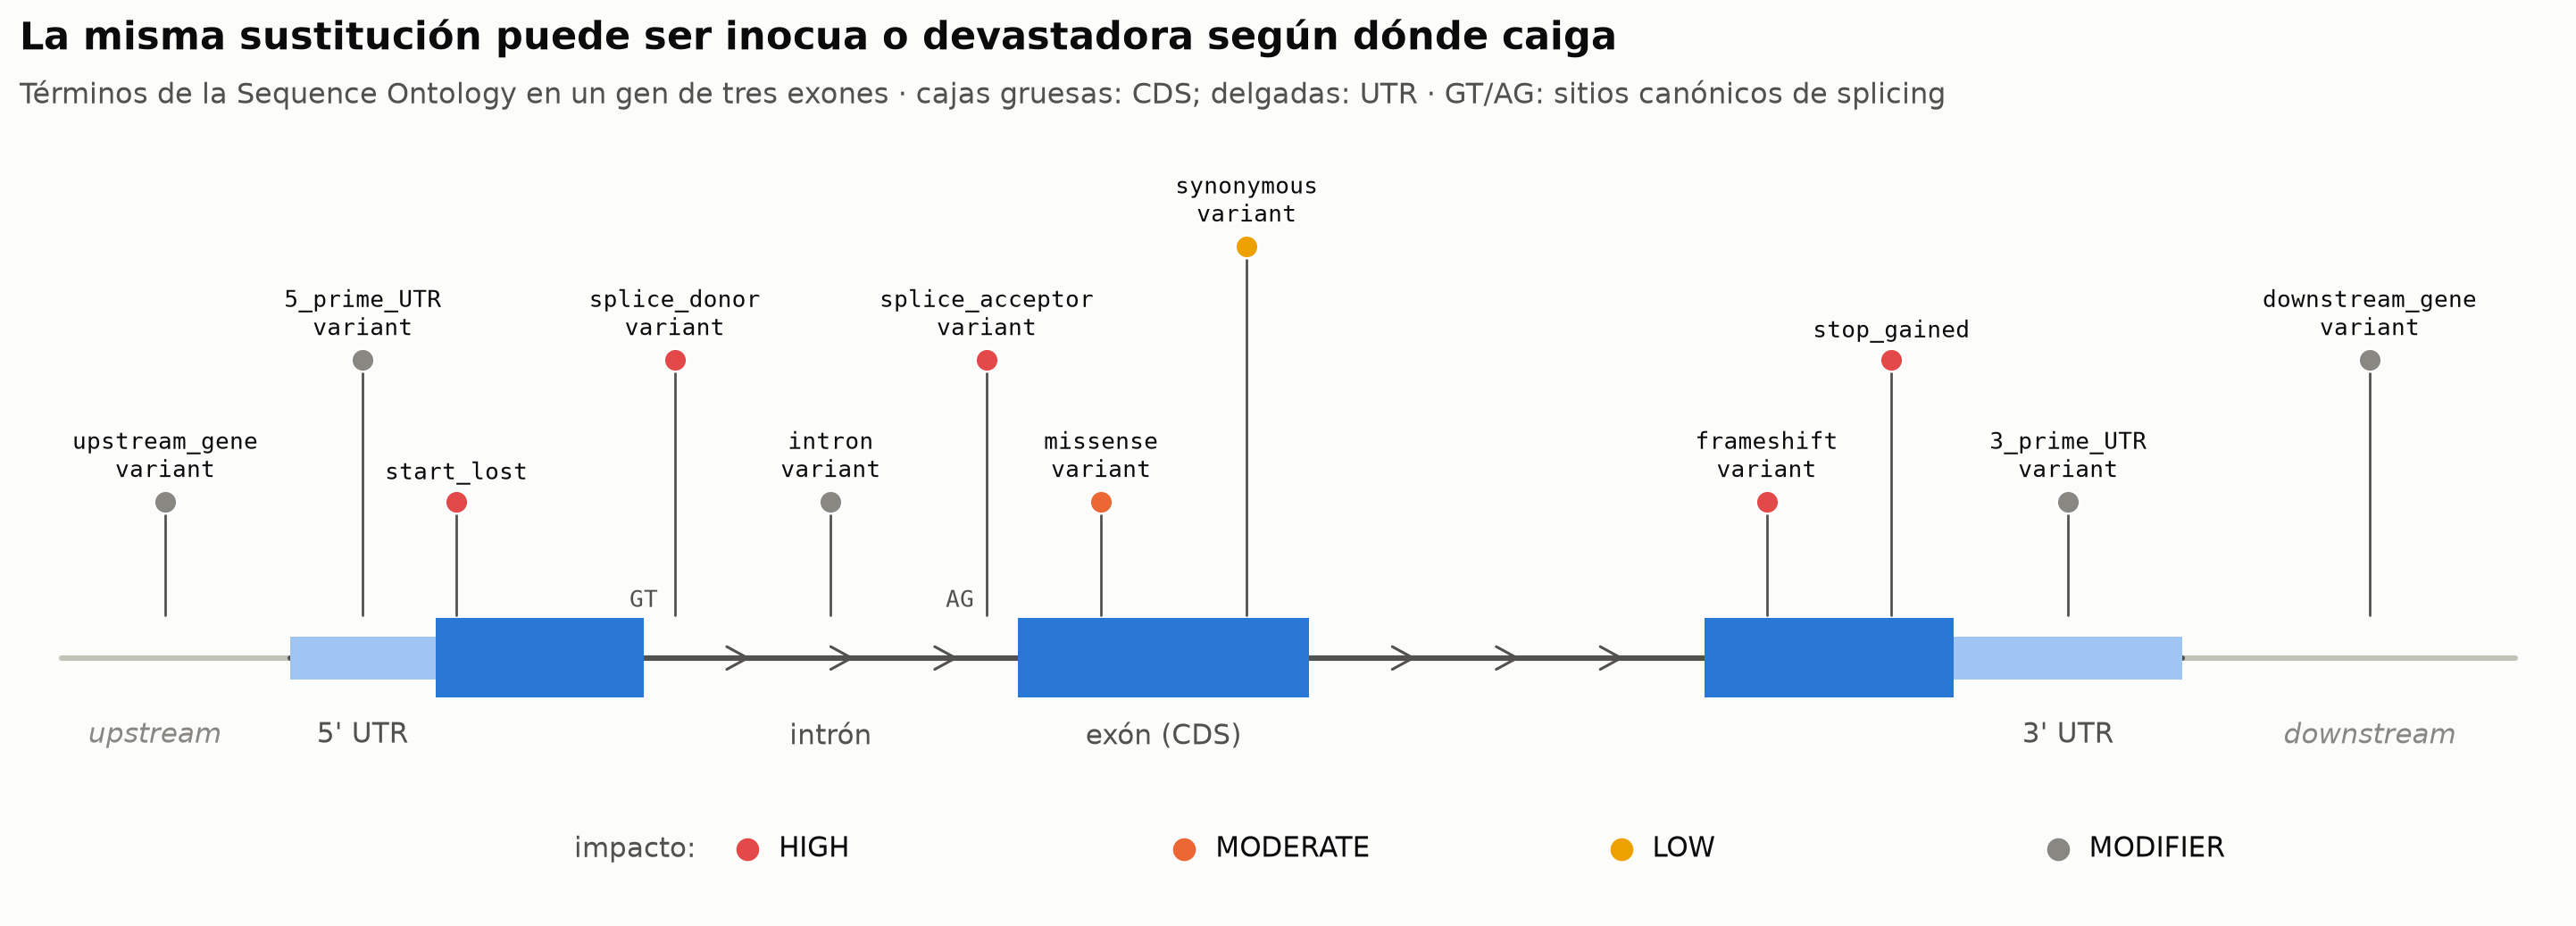

In [2]:
# Figura: consecuencias según la posición en un gen eucariota de tres exones (reproduce la figura 9.x del libro)
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.set_xlim(-0.2, 12.0); ax.set_ylim(-1.75, 3.75); ax.axis("off"); ax.grid(False)
ax.plot([0, 11.8], [0, 0], color=ec.BASELINE, lw=2, zorder=1)                     # genoma
ax.plot([1.1, 10.2], [0, 0], color=ec.INK_2, lw=2, zorder=2)                      # gen (intrones)
for x0, x1, h, c in [(1.1, 1.8, 0.15, ec.SEQ_BLUE[2]), (1.8, 2.8, 0.28, ec.BLUE), (4.6, 6.0, 0.28, ec.BLUE),
                     (7.9, 9.1, 0.28, ec.BLUE), (9.1, 10.2, 0.15, ec.SEQ_BLUE[2])]:
    ax.add_patch(Rectangle((x0, -h), x1 - x0, 2 * h, color=c, zorder=3))
for x in (3.3, 3.8, 4.3, 6.5, 7.0, 7.5):                                           # chevrones: sentido del gen
    ax.plot([x - 0.1, x, x - 0.1], [0.08, 0, -0.08], color=ec.INK_2, lw=1, zorder=2)
for x, t, c in [(1.45, "5' UTR", ec.INK_2), (9.65, "3' UTR", ec.INK_2), (3.7, "intrón", ec.INK_2),
                (5.3, "exón (CDS)", ec.INK_2), (0.45, "upstream", ec.MUTED), (11.1, "downstream", ec.MUTED)]:
    ax.text(x, -0.45, t, ha="center", va="top", fontsize=10, color=c, style="italic" if c == ec.MUTED else "normal")
ax.text(2.87, 0.36, "GT", ha="right", fontsize=8.5, color=ec.INK_2, family="monospace")
ax.text(4.39, 0.36, "AG", ha="right", fontsize=8.5, color=ec.INK_2, family="monospace")
pins = [(0.5, 1.1, "MODIFIER", "upstream_gene\nvariant"), (1.45, 2.1, "MODIFIER", "5_prime_UTR\nvariant"),
        (1.9, 1.1, "HIGH", "start_lost"), (2.95, 2.1, "HIGH", "splice_donor\nvariant"),
        (3.7, 1.1, "MODIFIER", "intron\nvariant"), (4.45, 2.1, "HIGH", "splice_acceptor\nvariant"),
        (5.0, 1.1, "MODERATE", "missense\nvariant"), (5.7, 2.9, "LOW", "synonymous\nvariant"),
        (8.2, 1.1, "HIGH", "frameshift\nvariant"), (8.8, 2.1, "HIGH", "stop_gained"),
        (9.65, 1.1, "MODIFIER", "3_prime_UTR\nvariant"), (11.1, 2.1, "MODIFIER", "downstream_gene\nvariant")]
for x, h, imp, t in pins:
    ax.plot([x, x], [0.3, h], color=ec.INK_2, lw=0.9, zorder=2)
    ax.scatter([x], [h], s=70, color=IMPACT_COLOR[imp], zorder=4, edgecolor="white", lw=0.8)
    ax.text(x, h + 0.12, t, ha="center", va="bottom", fontsize=8.5, family="monospace", color=ec.INK)
for i, imp in enumerate(IMPACT_COLOR):
    ax.scatter([3.3 + i * 2.1], [-1.35], s=70, color=IMPACT_COLOR[imp])
    ax.text(3.45 + i * 2.1, -1.35, imp, va="center", fontsize=10)
ax.text(3.05, -1.35, "impacto:", ha="right", va="center", fontsize=10, color=ec.INK_2)
ec.title(ax, "La misma sustitución puede ser inocua o devastadora según dónde caiga",
         "Términos de la Sequence Ontology en un gen de tres exones · cajas gruesas: CDS; delgadas: UTR · "
         "GT/AG: sitios canónicos de splicing")
plt.show()

> 🔎 **Qué observamos.** Los alfileres rojos (HIGH) no están sólo dentro de la región codificante: los dinucleótidos
> **GT** y **AG** que delimitan el intrón son tan críticos como un codón de parada, porque sin ellos el espliceosoma no
> corta donde debe. En cambio, la mayor parte del gen (intrones profundos, UTR) es MODIFIER. La categoría es una
> **heurística**, no un veredicto: una variante intrónica profunda puede crear un sitio de *splicing* nuevo y ser
> patogénica.

**Una variante, varias respuestas.** Un gen humano tiene en promedio varios transcritos, y un mismo cambio de base
puede ser `missense_variant` en uno e `intron_variant` en otro. Por eso los anotadores devuelven **una consecuencia
por transcrito** y ofrecen opciones para elegir un transcrito representativo (el canónico, el de MANE Select o el de
mayor impacto; en VEP, la opción `--pick`).

**Nomenclatura HGVS.** La descripción textual sigue las recomendaciones HGVS (den Dunnen et al., 2016):

<p align="center"><code>NM_000546.6:c.743G&gt;A</code> &nbsp;→&nbsp; <code>p.(Arg248Gln)</code></p>

| Pieza | Significado |
|---|---|
| `NM_000546.6` | Transcrito de referencia (RefSeq, versión 6) de *TP53* |
| `c.` | Coordenada sobre la secuencia **codificante** (la A del ATG es `c.1`) |
| `743G>A` | En la posición 743 de la CDS, una G pasa a A |
| `p.(Arg248Gln)` | Efecto sobre la proteína: arginina 248 → glutamina; **el paréntesis indica que es una predicción**, no una observación experimental |

Esta variante, R248Q, es una de las mutaciones más frecuentes de *TP53* en cáncer; la consultaremos en la sección 8.

✅ **Compruebe su comprensión.** Si `c.743` es la segunda base de un codón, ¿qué número de codón es? (Pista: el
codón $k$ ocupa las posiciones $3k-2$, $3k-1$ y $3k$.)

> Respuesta: $743 = 3\cdot 248 - 1$, así que es la segunda base del codón 248, de acuerdo con `p.(Arg248Gln)`.

**¿Y en una bacteria?** El genoma de *E. coli* no tiene intrones ni *splicing*, y casi no tiene UTR anotadas: la mayor
parte de los términos de la figura desaparecen. En el anotador propio usaremos el subconjunto procariota: consecuencias
sobre el codón, `inframe_*`, `frameshift_variant`, `upstream_gene_variant`, `downstream_gene_variant`,
`intergenic_variant` y `non_coding_transcript_exon_variant` (ARN ribosómicos y de transferencia).

---

## 3. Consecuencias sobre el codón

Dentro de la región codificante, la consecuencia depende del **código genético**. Trabajemos con la secuencia de cinco
codones del libro:

<p align="center"><code>ATG GCT TGG CAA GGA</code> &nbsp;→&nbsp; Met‑Ala‑Trp‑Gln‑Gly</p>

Resolvamos a mano los cinco casos principales antes de pedírselos a Python:

| Cambio | Codón | Aminoácido | Término SO | Impacto |
|---|---|---|---|---|
| T→C en la 3.ª base de `GCT` | `GCT`→`GCC` | Ala→Ala | `synonymous_variant` | LOW |
| A→G en la 2.ª base de `CAA` | `CAA`→`CGA` | Gln→Arg | `missense_variant` (de sentido erróneo) | MODERATE |
| G→A en la 3.ª base de `TGG` | `TGG`→`TGA` | Trp→Stop | `stop_gained` | HIGH |
| deleción de `TGG` completo | — | se pierde Trp; el resto intacto | `inframe_deletion` | MODERATE |
| deleción de la `C` de `GCT` | `ATG GTT GGC AAG GA` | Met‑Val‑Gly‑Lys… | `frameshift_variant` | HIGH |

La última fila es la más dramática: **una sola base** perdida desplaza el **marco de lectura** y cambia todos los
aminoácidos siguientes, igual que borrar una letra en «EL SOL SALE» y leer de tres en tres: «ELS OLS ALE».

La regla general para una inserción o deleción de $\Delta$ bases dentro de la CDS es

$$
\text{consecuencia} =
\begin{cases}
\texttt{inframe\_insertion / inframe\_deletion} & \text{si } \Delta \equiv 0 \pmod 3,\\[2pt]
\texttt{frameshift\_variant} & \text{si } \Delta \not\equiv 0 \pmod 3.
\end{cases}
$$

| Símbolo | Significado |
|---|---|
| $\Delta$ | Longitud de ALT menos longitud de REF (positiva: inserción; negativa: deleción) |
| $\equiv \pmod 3$ | «Deja el mismo resto al dividir por 3» |

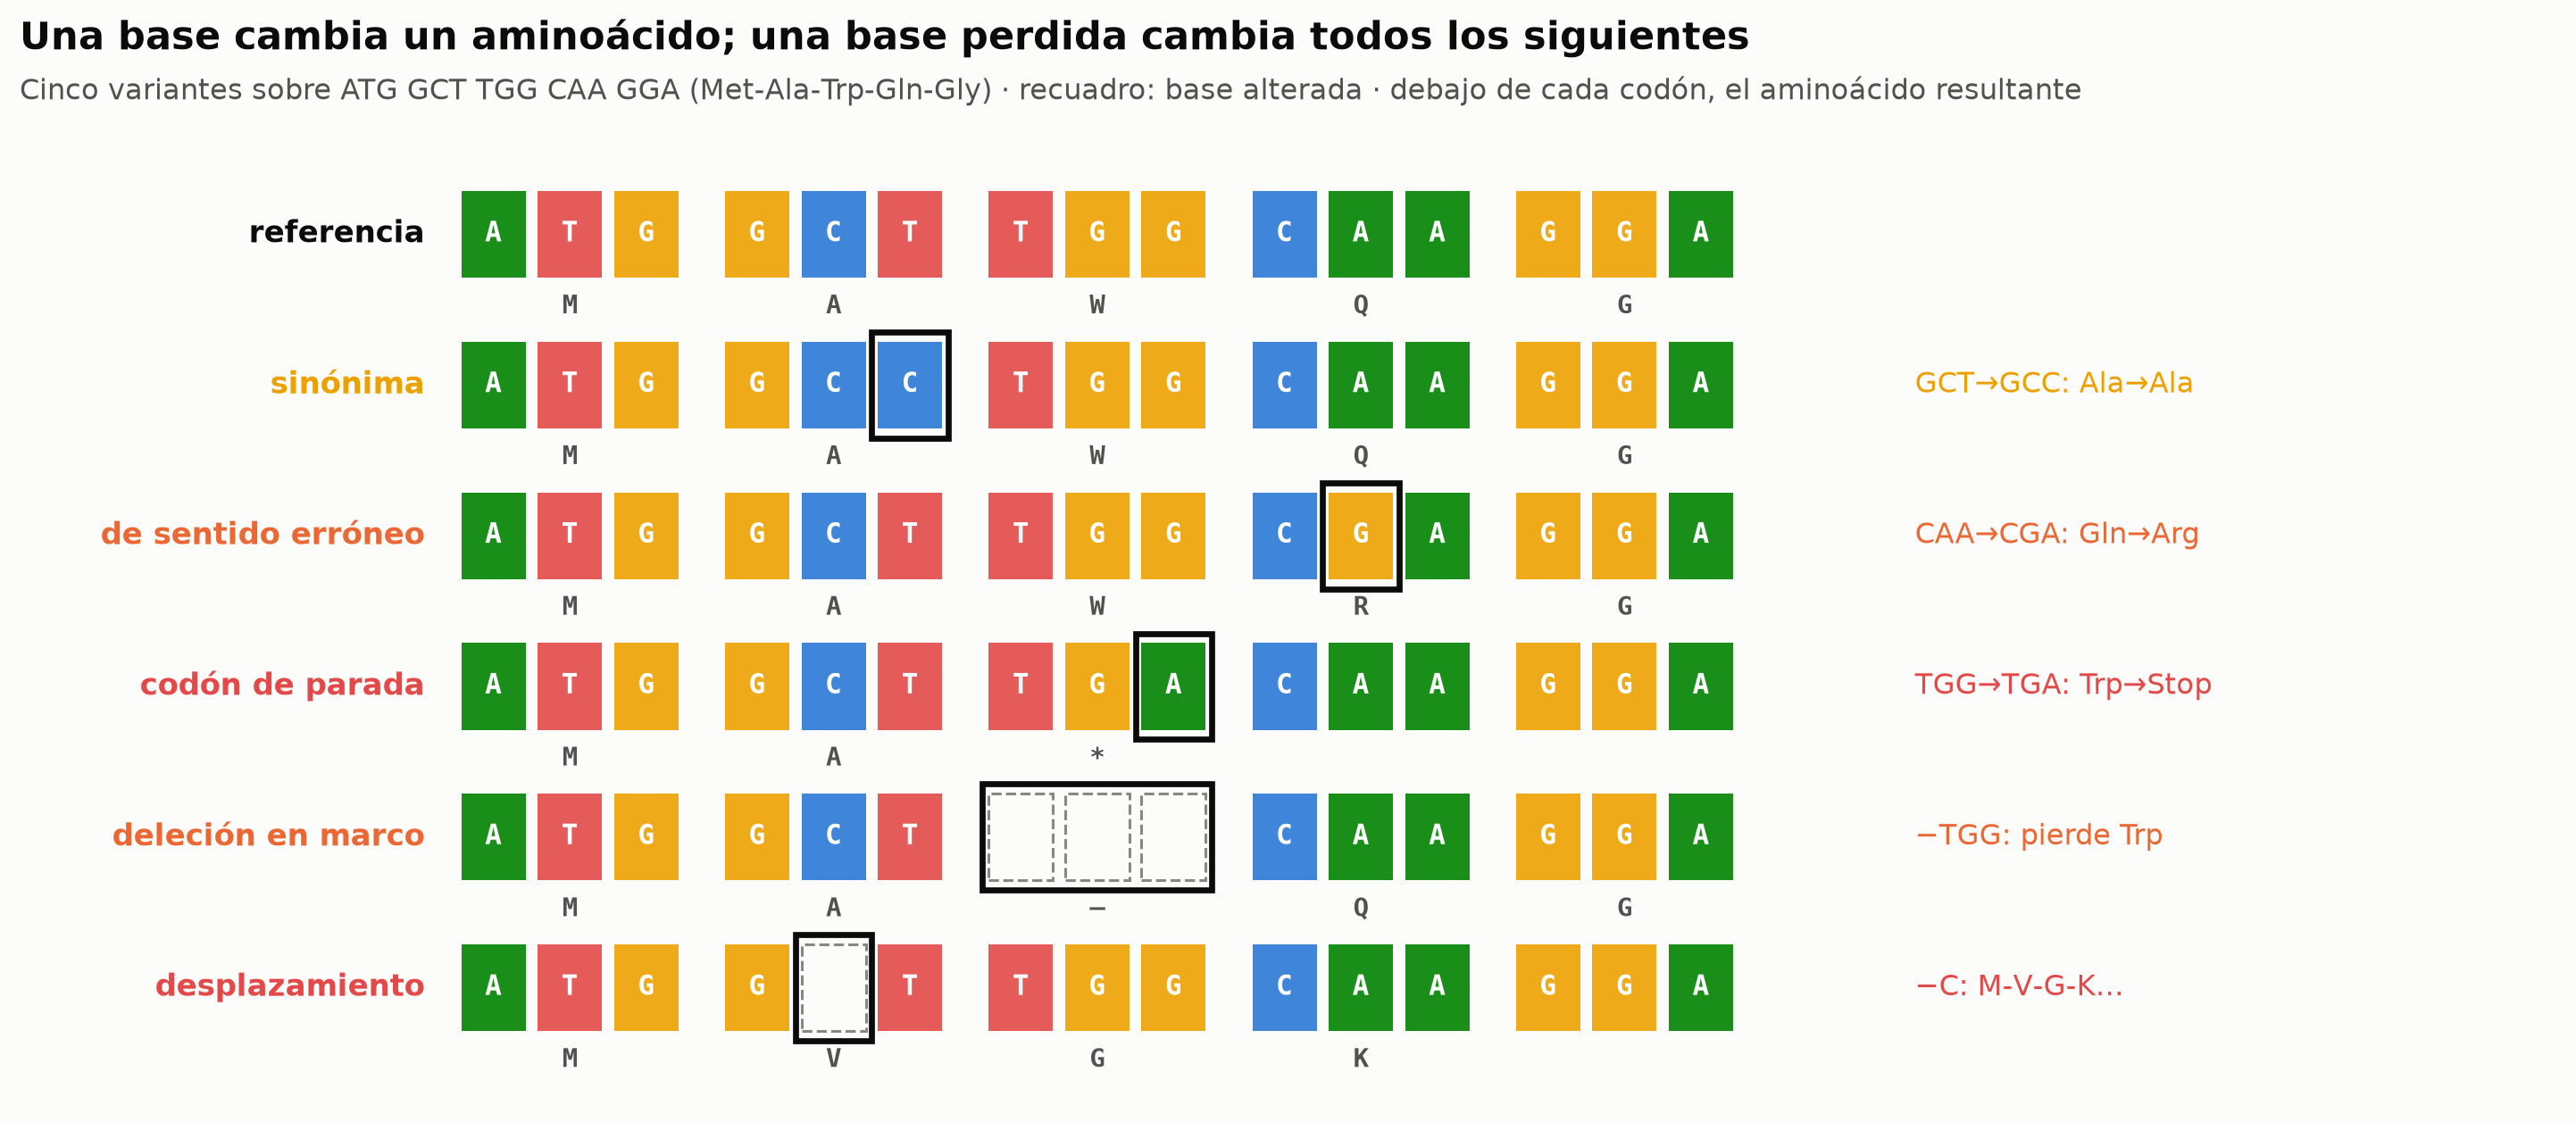

In [3]:
REF_CDS = "ATGGCTTGGCAAGGA"
CASES = [("referencia", REF_CDS, None, ec.INK),
         ("sinónima", "ATGGCCTGGCAAGGA", "GCT→GCC: Ala→Ala", ec.YELLOW),
         ("de sentido erróneo", "ATGGCTTGGCGAGGA", "CAA→CGA: Gln→Arg", ec.ORANGE),
         ("codón de parada", "ATGGCTTGACAAGGA", "TGG→TGA: Trp→Stop", ec.RED),
         ("deleción en marco", "ATGGCT---CAAGGA", "−TGG: pierde Trp", ec.ORANGE),
         ("desplazamiento", "ATGG-TTGGCAAGGA", "−C: M‑V‑G‑K…", ec.RED)]

def protein_of(aligned):
    """Traduce la secuencia sin huecos hasta el primer codón de parada (incluido)."""
    p = translate(aligned.replace("-", ""))
    return p[:p.index("*") + 1] if "*" in p else p

fig, ax = plt.subplots(figsize=(13, 5.6))
ax.set_xlim(-6.2, 27); ax.set_ylim(-7.2, 0.9); ax.axis("off"); ax.grid(False)
xpos = [i + (i // 3) * 0.45 for i in range(15)]                 # un pequeño hueco entre codones
for row, (name, s, txt, col) in enumerate(CASES):
    y = -row * 1.25
    ax.text(-0.9, y, name, ha="right", va="center", fontsize=11, fontweight="bold", color=col)
    for i, b in enumerate(s):
        if b == "-":
            ax.add_patch(Rectangle((xpos[i] - 0.42, y - 0.36), 0.84, 0.72, fill=False, ec=ec.MUTED, ls="--", lw=1))
        else:
            changed = b != REF_CDS[i] and name not in ("desplazamiento",)
            ax.add_patch(Rectangle((xpos[i] - 0.42, y - 0.36), 0.84, 0.72, color=ec.NUC_COLORS[b], alpha=0.9))
            ax.text(xpos[i], y, b, ha="center", va="center", fontsize=10, fontweight="bold", color="white",
                    family="monospace")
            if changed:
                ax.add_patch(Rectangle((xpos[i] - 0.5, y - 0.44), 1.0, 0.88, fill=False, ec=ec.INK, lw=2.2))
    if name == "deleción en marco":
        ax.add_patch(Rectangle((xpos[6] - 0.5, y - 0.44), xpos[8] - xpos[6] + 1.0, 0.88, fill=False, ec=ec.INK, lw=2.2))
    if name == "desplazamiento":
        ax.add_patch(Rectangle((xpos[4] - 0.5, y - 0.44), 1.0, 0.88, fill=False, ec=ec.INK, lw=2.2))
    prot = protein_of(s)
    if name == "deleción en marco":
        prot = "MA–QG"                                          # guion: el aminoácido perdido
    for j, a in enumerate(prot):
        ax.text(xpos[3 * j + 1], y - 0.6, a, ha="center", va="center", fontsize=9.5, color=ec.INK_2,
                family="monospace", fontweight="bold")
    if txt:
        ax.text(18.6, y, txt, ha="left", va="center", fontsize=10.5, color=col)
ec.title(ax, "Una base cambia un aminoácido; una base perdida cambia todos los siguientes",
         "Cinco variantes sobre ATG GCT TGG CAA GGA (Met‑Ala‑Trp‑Gln‑Gly) · recuadro: base alterada · "
         "debajo de cada codón, el aminoácido resultante")
plt.show()

> 🔎 **Qué observamos.** Las tres sustituciones afectan a un solo codón, pero con efectos muy distintos: nada (Ala→Ala),
> un aminoácido distinto (Gln→Arg) o una proteína truncada tras dos residuos (Trp→Stop). La deleción de tres bases
> quita un residuo y deja intacto el resto; la de una sola base convierte `GCT TGG CAA GGA` en `GTT GGC AAG GA`, un
> texto completamente nuevo.

### 3.1 🎬 Una SNV que recorre el codón

¿Importa **en qué posición** del codón cae la sustitución? Hagamos el experimento exhaustivo sobre la misma
secuencia: en cada una de las 15 posiciones probamos las 3 bases alternativas (45 SNV) y anotamos cada una.

🤔 **Antes de ejecutar, prediga:** ¿en qué posición del codón (1.ª, 2.ª o 3.ª) aparecerán casi todas las sinónimas?
¿Y qué pasa con cualquier cambio en el primer codón, `ATG`?

In [4]:
def snv_consequence(cds, i, new):
    """Consecuencia SO de cambiar la base i (0-based) de una CDS por `new`."""
    k = i // 3
    c0 = cds[3 * k: 3 * k + 3]
    c1 = c0[:i % 3] + new + c0[i % 3 + 1:]
    a0, a1 = CODE[c0], CODE[c1]
    if k == 0 and a1 != "M":
        term = "start_lost"
    elif a0 == "*":
        term = "stop_retained_variant" if a1 == "*" else "stop_lost"
    elif a1 == "*":
        term = "stop_gained"
    elif a0 == a1:
        term = "synonymous_variant"
    else:
        term = "missense_variant"
    return c0, c1, a0, a1, term

walk = [(i, b) for i in range(15) for b in "ACGT" if b != REF_CDS[i]]
walk_df = pd.DataFrame([(i + 1, i // 3 + 1, i % 3 + 1, REF_CDS[i], b, *snv_consequence(REF_CDS, i, b))
                        for i, b in walk],
                       columns=["pos", "codon", "pos_codon", "ref", "alt", "c_ref", "c_alt", "aa_ref", "aa_alt", "term"])
print(walk_df.groupby(["pos_codon", "term"]).size().unstack(fill_value=0))

term       missense_variant  start_lost  stop_gained  synonymous_variant
pos_codon                                                               
1                        10           3            2                   0
2                        11           3            1                   0
3                         4           3            1                   7


![Una SNV recorre las 15 posiciones de ATG GCT TGG CAA GGA: en la 3.ª posición del codón casi siempre es sinónima; en la 2.ª, nunca; cualquier cambio en ATG pierde el inicio.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-09-variantes/9.3_snv_codon.gif)

*Una SNV recorre las 15 posiciones de ATG GCT TGG CAA GGA: en la 3.ª posición del codón casi siempre es sinónima; en la 2.ª, nunca; cualquier cambio en ATG pierde el inicio.*

In [5]:
TERM_COLOR = {"synonymous_variant": ec.YELLOW, "missense_variant": ec.ORANGE, "stop_gained": ec.RED,
              "start_lost": ec.VIOLET}
TERM_ES = {"synonymous_variant": "sinónima", "missense_variant": "sentido erróneo", "stop_gained": "stop gained",
           "start_lost": "start lost"}
fig = plt.figure(figsize=(12.5, 5.0), layout="none")
axs = fig.add_axes([0.02, 0.08, 0.60, 0.72]); axb = fig.add_axes([0.71, 0.14, 0.26, 0.56])
axs.set_xlim(-1.2, 17.5); axs.set_ylim(-3.3, 1.4); axs.axis("off"); axs.grid(False)
fig.text(0.01, 0.97, "La posición dentro del codón decide casi todo", fontsize=15, fontweight="bold", va="top")
fig.text(0.01, 0.905, "45 SNV posibles sobre ATG GCT TGG CAA GGA · arriba la referencia, abajo el alelo mutado "
         "· a la derecha, el recuento acumulado por posición del codón", fontsize=10.5, color=ec.INK_2, va="top")
xpos = [i + (i // 3) * 0.45 for i in range(15)]
ref_boxes, alt_boxes, alt_txt, aa_txt = [], [], [], []
for i, b in enumerate(REF_CDS):
    axs.add_patch(Rectangle((xpos[i] - 0.42, 0.28), 0.84, 0.72, color=ec.NUC_COLORS[b]))
    axs.text(xpos[i], 0.64, b, ha="center", va="center", color="white", fontweight="bold", family="monospace")
    r = Rectangle((xpos[i] - 0.42, -1.0), 0.84, 0.72, color=ec.NUC_COLORS[b]); axs.add_patch(r); alt_boxes.append(r)
    alt_txt.append(axs.text(xpos[i], -0.64, b, ha="center", va="center", color="white", fontweight="bold",
                            family="monospace"))
for j in range(5):
    axs.text(xpos[3 * j + 1], 1.22, AA3[translate(REF_CDS)[j]], ha="center", fontsize=10, color=ec.INK_2)
    aa_txt.append(axs.text(xpos[3 * j + 1], -1.3, "", ha="center", va="top", fontsize=10, fontweight="bold"))
axs.text(-0.7, 0.64, "ref", ha="right", va="center", fontsize=10, color=ec.INK_2)
axs.text(-0.7, -0.64, "alt", ha="right", va="center", fontsize=10, color=ec.INK_2)
frame_box = Rectangle((0, -1.08), 1.0, 0.88, fill=False, ec=ec.INK, lw=2.5); axs.add_patch(frame_box)
verdict = axs.text(8.1, -2.55, "", ha="center", va="center", fontsize=13, fontweight="bold")

terms = list(TERM_COLOR)
counts = np.zeros((3, len(terms)))
def draw_bars():
    axb.clear()
    left = np.zeros(3)
    for t_i, t in enumerate(terms):
        axb.barh([3, 2, 1], counts[:, t_i], left=left, color=TERM_COLOR[t], label=TERM_ES[t], height=0.6)
        left += counts[:, t_i]
    axb.set_yticks([3, 2, 1], ["1.ª", "2.ª", "3.ª"]); axb.set_xlim(0, 15.5); axb.set_ylim(0.4, 3.6)
    axb.set_xlabel("SNV acumuladas"); axb.set_ylabel("posición en el codón")
    axb.legend(loc="lower left", bbox_to_anchor=(-0.02, 1.0), ncol=2, fontsize=9, frameon=False)
    axb.grid(axis="y", visible=False)

NHOLD = 3
def update(fr):
    fr = min(fr, len(walk_df) - 1)
    row = walk_df.iloc[fr]
    i = row.pos - 1
    mut = REF_CDS[:i] + row.alt + REF_CDS[i + 1:]
    for k, b in enumerate(mut):
        alt_boxes[k].set_color(ec.NUC_COLORS[b]); alt_txt[k].set_text(b)
    frame_box.set_x(xpos[i] - 0.5)
    prot = translate(mut)
    for j in range(5):
        a = prot[j]
        aa_txt[j].set_text("Stop" if a == "*" else AA3[a])
        aa_txt[j].set_color(TERM_COLOR[row.term] if j == row.codon - 1 else ec.INK_2)
    verdict.set_text(f"{row.c_ref} → {row.c_alt}   ·   {AA3[row.aa_ref]} → "
                     f"{'Stop' if row.aa_alt == '*' else AA3[row.aa_alt]}   ·   {row.term}")
    verdict.set_color(TERM_COLOR[row.term])
    counts[:] = 0
    for _, r in walk_df.iloc[:fr + 1].iterrows():
        counts[r.pos_codon - 1, terms.index(r.term)] += 1
    draw_bars()
    return []

update(0)
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=len(walk_df) + NHOLD, interval=380, name="9.3_snv_codon")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Las barras de la derecha cuentan la historia: en la **3.ª posición** dominan las sinónimas
> (la «degeneración» del código: GCT, GCC, GCA y GCG son todas alanina); en la **2.ª** no hay ni una; y cualquier cambio
> en `ATG` pierde el inicio de la traducción (`start_lost`, HIGH). `TGG` (triptófano) es uno de los cinco codones con dos
> vecinos de parada entre sus nueve (`TGA`, `TAG`).

### 3.2 Las 576 sustituciones posibles del código genético

¿Con qué frecuencia cae una SNV en cada categoría? Podemos responderlo **exhaustivamente**: 64 codones × 3 posiciones
× 3 bases alternativas = 576 sustituciones. Si excluimos los 3 codones de parada, los **61 codones con sentido**
admiten

$$61 \times 9 = 549$$

sustituciones de una base. El libro obtiene, recorriéndolas con la tabla del código estándar, **134 sinónimas (24,4 %),
392 de sentido erróneo (71,4 %) y 23 que crean un codón de parada (4,2 %)**. Comprobémoslo con el mismo algoritmo.

In [6]:
def classify(c, p, nb_):
    """Clasificación del libro (generar.py): sin / mis / non (stop gained) / stoplost / stopret."""
    c2 = c[:p] + nb_ + c[p + 1:]
    a1, a2 = CODE[c], CODE[c2]
    if a1 == "*":
        return "stopret" if a2 == "*" else "stoplost"
    if a2 == "*":
        return "non"
    return "sin" if a1 == a2 else "mis"

cont = {p: Counter() for p in (1, 2, 3)}
for c in CODE:
    for p in range(3):
        for nb_ in "ACGT":
            if nb_ != c[p]:
                cont[p + 1][classify(c, p, nb_)] += 1
snv_codon = pd.DataFrame(cont).T.reindex(columns=["sin", "mis", "non", "stoplost", "stopret"]).fillna(0).astype(int)
snv_codon.index.name = "pos"
tot = snv_codon.sum()
sense = 61 * 9
assert (tot.sin, tot.mis, tot["non"]) == (134, 392, 23) and snv_codon.values.sum() == 576
print(snv_codon)
print(f"\nSobre {sense} SNV en codones con sentido: sinónimas {tot.sin} ({tot.sin/sense:.1%}), "
      f"sentido erróneo {tot.mis} ({tot.mis/sense:.1%}), stop gained {tot['non']} ({tot['non']/sense:.1%})")
print(f"Razón esperada sentido erróneo / sinónima bajo neutralidad: {tot.mis/tot.sin:.2f}")

     sin  mis  non  stoplost  stopret
pos                                  
1      8  166    9         9        0
2      0  176    7         7        2
3    126   50    7         7        2

Sobre 549 SNV en codones con sentido: sinónimas 134 (24.4%), sentido erróneo 392 (71.4%), stop gained 23 (4.2%)
Razón esperada sentido erróneo / sinónima bajo neutralidad: 2.93


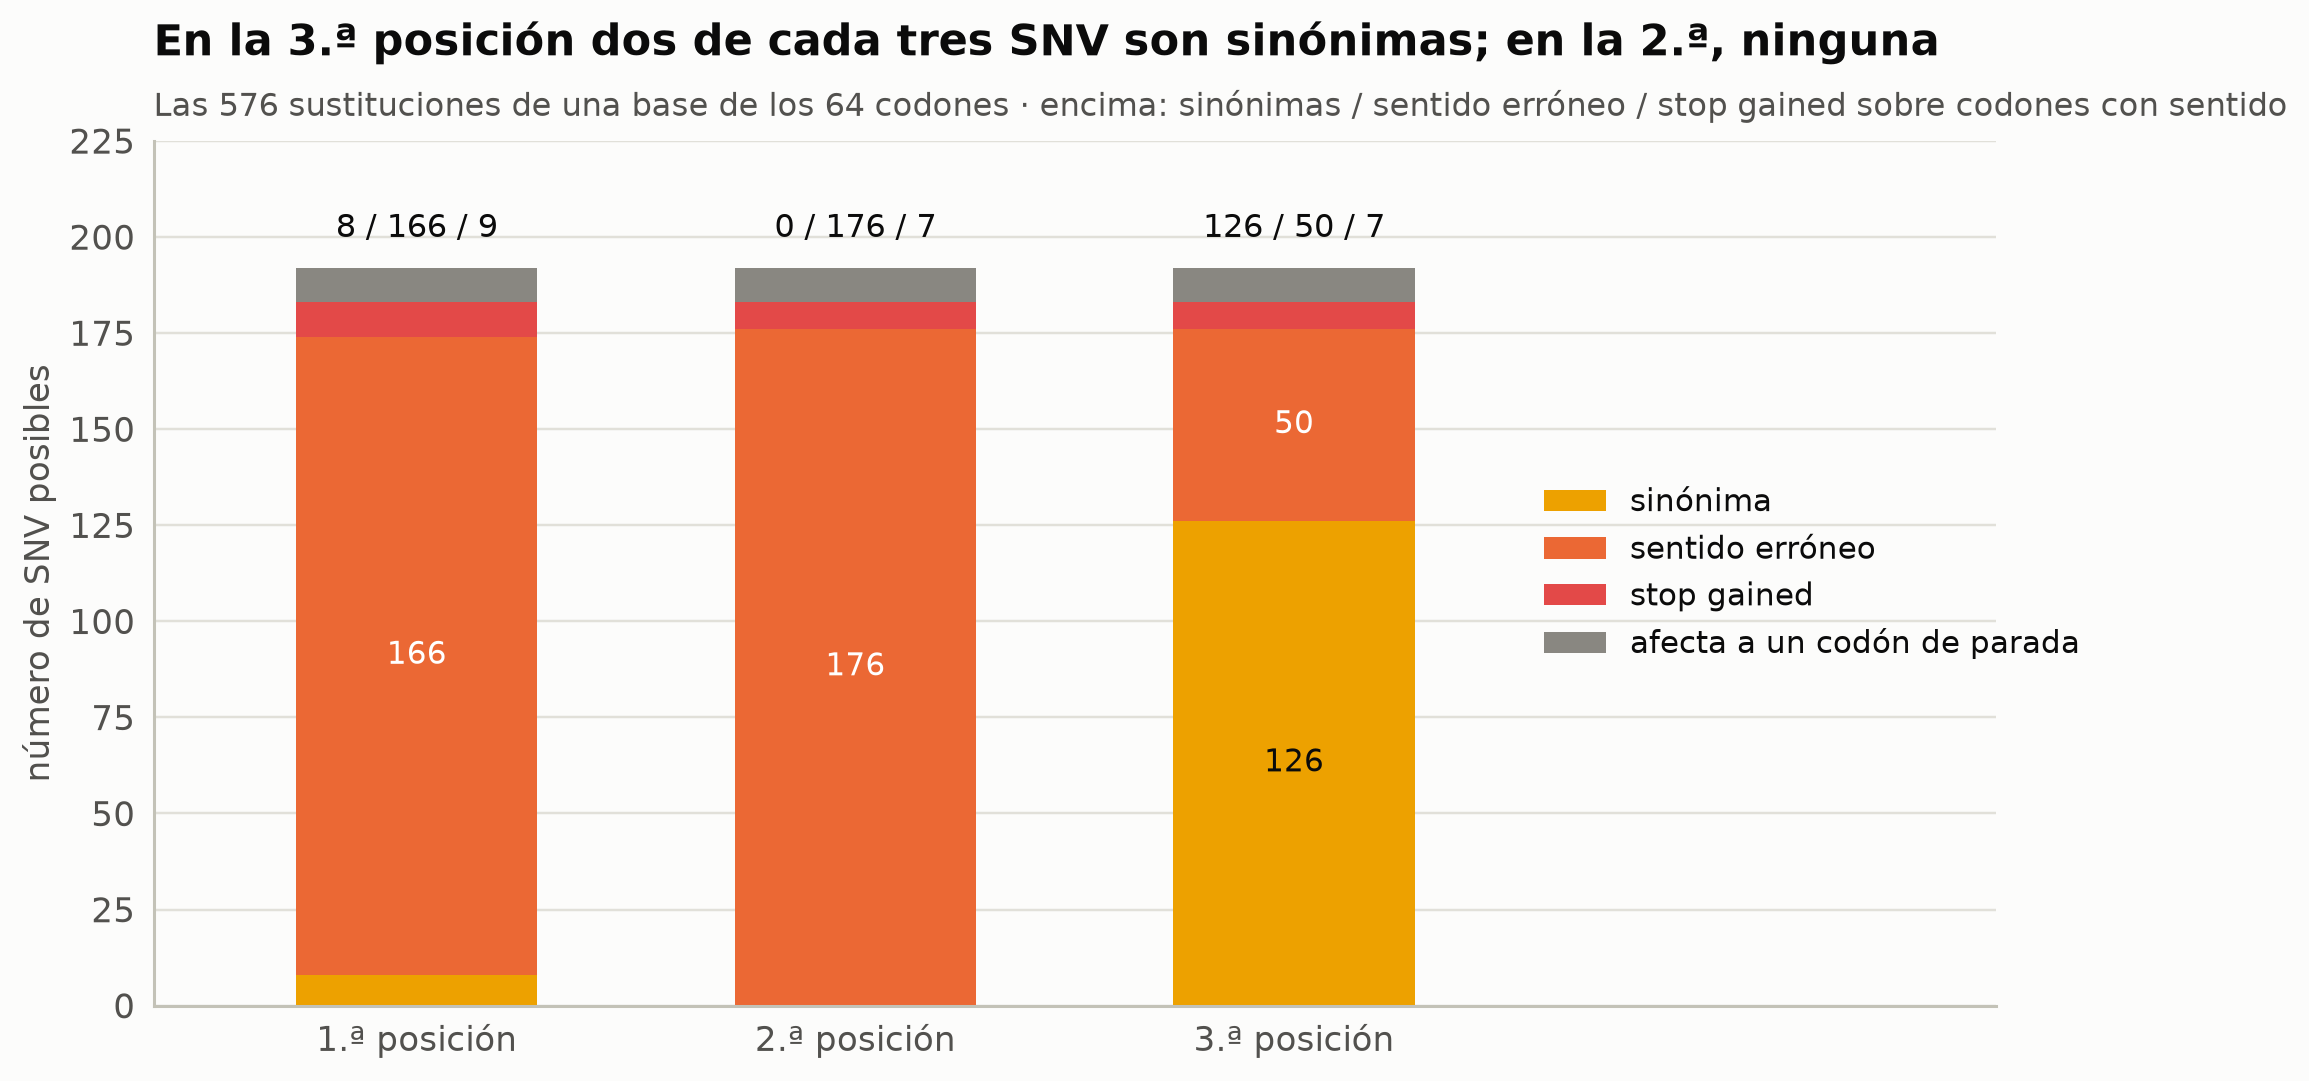

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.array([1, 2, 3]); bottom = np.zeros(3)
parts = [("sin", "sinónima", ec.YELLOW), ("mis", "sentido erróneo", ec.ORANGE), ("non", "stop gained", ec.RED),
         (("stoplost", "stopret"), "afecta a un codón de parada", ec.MUTED)]
for key, lab, col in parts:
    v = snv_codon[list(key)].sum(axis=1).values if isinstance(key, tuple) else snv_codon[key].values
    ax.bar(x, v, bottom=bottom, color=col, width=0.55, label=lab)
    for xi, vi, bi in zip(x, v, bottom):
        if vi >= 12:
            ax.text(xi, bi + vi / 2, str(vi), ha="center", va="center", fontsize=10,
                    color="white" if col in (ec.ORANGE, ec.RED, ec.MUTED) else ec.INK)
    bottom += v
for xi in x:
    r = snv_codon.loc[xi]
    ax.text(xi, 200, f"{r.sin} / {r.mis} / {r['non']}", ha="center", fontsize=10.5, color=ec.INK)
ax.set_xticks(x, ["1.ª posición", "2.ª posición", "3.ª posición"]); ax.set_ylim(0, 225); ax.set_xlim(0.4, 4.6)
ax.set_ylabel("número de SNV posibles")
ax.legend(loc="center left", bbox_to_anchor=(0.74, 0.5), frameon=False, fontsize=10)
ax.grid(axis="x", visible=False)
ec.title(ax, "En la 3.ª posición dos de cada tres SNV son sinónimas; en la 2.ª, ninguna",
         "Las 576 sustituciones de una base de los 64 codones · encima: sinónimas / sentido erróneo / stop gained "
         "sobre codones con sentido")
plt.show()

> 🔎 **Qué observamos.** Reproducimos exactamente las cifras del libro: 8 / 166 / 9 en la 1.ª posición, 0 / 176 / 7
> en la 2.ª y 126 / 50 / 7 en la 3.ª. Bajo neutralidad esperaríamos **unas tres variantes de sentido erróneo por cada
> sinónima** (392/134 ≈ 2,9). Esta es la base del cociente $d_N/d_S$ de la evolución molecular y de un hecho práctico:
> un gen en el que la población muestra muchas menos variantes de sentido erróneo de las esperadas está sometido a
> **selección purificadora**, y uno con muchas más, a **selección positiva**. Usaremos este razonamiento con el clon
> del LTEE en la sección 6.

La figura interactiva siguiente despliega las 576 sustituciones una por una. Pase el ratón por cada celda.

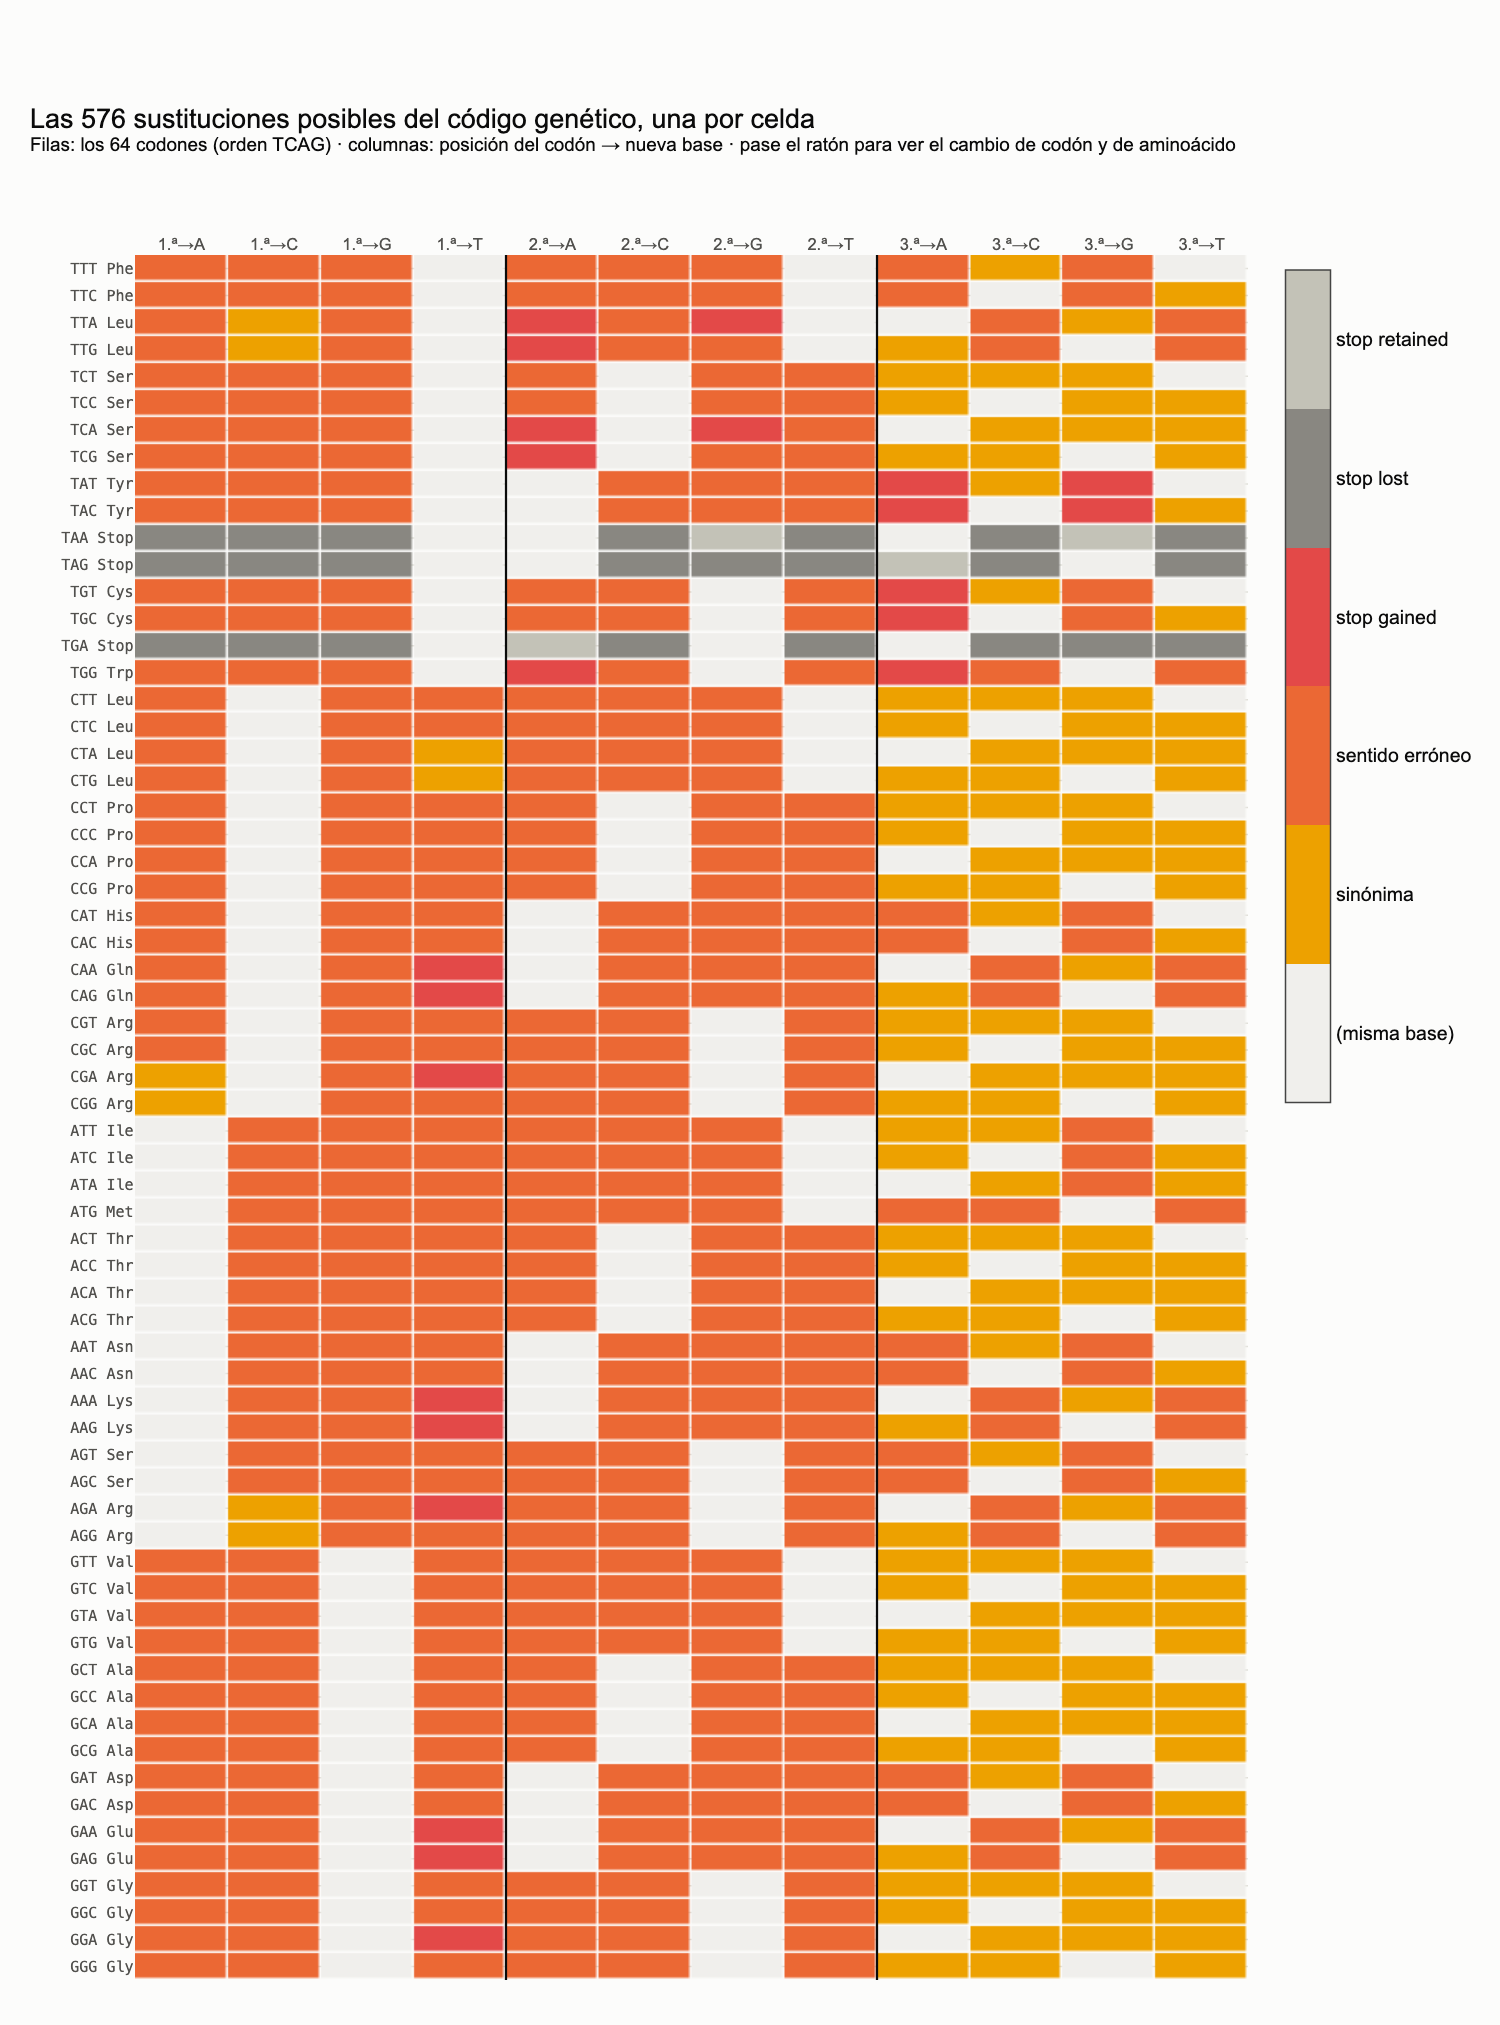

In [8]:
CAT_ES = {"sin": "sinónima", "mis": "sentido erróneo", "non": "stop gained", "stoplost": "stop lost",
          "stopret": "stop retained", "same": "(misma base)"}
CAT_Z = {"same": 0, "sin": 1, "mis": 2, "non": 3, "stoplost": 4, "stopret": 5}
codons = list(CODE)                                    # orden TCAG, como la tabla clásica
cols = [f"{p}.ª→{b}" for p in (1, 2, 3) for b in "ACGT"]
Z, H = [], []
for c in codons:
    zrow, hrow = [], []
    for p in range(3):
        for b in "ACGT":
            if b == c[p]:
                zrow.append(CAT_Z["same"]); hrow.append(f"<b>{c}</b> ({AA3[CODE[c]] if CODE[c] != '*' else 'Stop'})"
                                                          f"<br>la base {p+1} ya es {b}")
                continue
            k = classify(c, p, b); c2 = c[:p] + b + c[p + 1:]
            n0 = "Stop" if CODE[c] == "*" else AA3[CODE[c]]; n1 = "Stop" if CODE[c2] == "*" else AA3[CODE[c2]]
            zrow.append(CAT_Z[k])
            hrow.append(f"<b>{c} → {c2}</b><br>posición {p+1} del codón: {c[p]}→{b}<br>{n0} → {n1}"
                        f"<br><b>{CAT_ES[k]}</b>")
    Z.append(zrow); H.append(hrow)
palette = ["#f0efec", ec.YELLOW, ec.ORANGE, ec.RED, ec.MUTED, "#c3c2b7"]
scale = []
for i, col in enumerate(palette):
    scale += [[i / 6, col], [(i + 1) / 6, col]]
fig = go.Figure(go.Heatmap(z=Z, x=cols, y=[f"{c} {'Stop' if CODE[c]=='*' else AA3[CODE[c]]}" for c in codons],
                           text=H, hovertemplate="%{text}<extra></extra>", colorscale=scale, zmin=-0.5, zmax=5.5,
                           xgap=1.5, ygap=1.5,
                           colorbar=dict(tickvals=list(range(6)), ticktext=[CAT_ES[k] for k in CAT_Z], len=0.5,
                                         y=0.75, title="")))
for xv in (3.5, 7.5):
    fig.add_vline(x=xv, line=dict(color=ec.INK, width=1.5))
fig.update_yaxes(autorange="reversed", tickfont=dict(family="monospace", size=10))
fig.update_xaxes(side="top", tickfont=dict(size=11))
fig.update_layout(height=1350, width=900, margin=dict(t=170, l=90, r=20, b=30),
                  title="Las 576 sustituciones posibles del código genético, una por celda"
                        "<br><sup>Filas: los 64 codones (orden TCAG) · columnas: posición del codón → nueva base · "
                        "pase el ratón para ver el cambio de codón y de aminoácido</sup>")
fig.show()

> 🔎 **Qué observamos.** El bloque de la izquierda (1.ª posición) es casi todo naranja, salvo las sinónimas de leucina
> y arginina (`CTA`↔`TTA`, `AGA`↔`CGA`), los dos aminoácidos de seis codones. El bloque central (2.ª posición) no tiene
> una sola celda amarilla. El derecho (3.ª posición) es mayoritariamente amarillo, con franjas naranjas en las «cajas» de
> codones que comparten dos aminoácidos (p. ej. `TTT`/`TTC` Phe frente a `TTA`/`TTG` Leu).

✅ **Compruebe su comprensión.** ¿Por qué los codones de parada tienen 2 sustituciones «stop retained» en la 2.ª
posición y ninguna en la 1.ª? (Pista: busque qué codones de parada difieren sólo en la 2.ª base.)

---

## 4. 🧪 Un anotador propio sobre REL606

VEP y SnpEff son programas grandes, pero su núcleo es sencillo. Para una variante $(\text{POS}, \text{REF}, \text{ALT})$
y un gen con coordenadas $[\text{inicio}, \text{fin}]$ en la hebra $s \in \{+,-\}$:

1. **¿Se solapan?** Si $\text{POS} \le \text{fin}$ y $\text{POS} + |\text{REF}| - 1 \ge \text{inicio}$, la variante cae
   en el gen.
2. **Construir los dos alelos del gen:** la secuencia de referencia del gen y la misma secuencia con REF sustituido por
   ALT. Si el gen está en la hebra $-$, se toma el **complemento inverso** de ambas.
3. **Traducir ambas** y comparar codón a codón: el primer aminoácido distinto da la consecuencia y la notación HGVS.
4. **Si no toca ningún gen**, mirar a los vecinos: ¿está a menos de $w$ pares de bases del **inicio** de un gen
   (`upstream_gene_variant`, posible promotor) o de su **final** (`downstream_gene_variant`)? Si no, es
   `intergenic_variant`.

La posición dentro de la CDS (base 0 = la A del ATG) de una base genómica $x$ es

$$
o(x) = \begin{cases} x - \text{inicio} & \text{si } s = +,\\ \text{fin} - x & \text{si } s = -,\end{cases}
\qquad \text{codón } k = \left\lfloor o/3 \right\rfloor + 1, \qquad \text{posición en el codón} = (o \bmod 3) + 1 .
$$

| Símbolo | Significado |
|---|---|
| POS, REF, ALT | Posición (1-based) y alelos de la variante en el VCF, ya **normalizados** |
| inicio, fin | Coordenadas 1-based inclusivas del gen en la tabla de anotación (siempre inicio < fin) |
| $s$ | Hebra del gen |
| $o(x)$ | Desplazamiento de la base $x$ dentro de la CDS (0-based) |
| $k$ | Número de codón (1-based) que usa HGVS en `p.` |
| $w$ | Ventana para *upstream*/*downstream* |

**Ejemplo a mano.** *pykF* (piruvato cinasa) ocupa 1 732 965–1 734 377 en la hebra +. La variante del clon
`1733343 G>A` tiene $o = 1\,733\,343 - 1\,732\,965 = 378$, así que cae en el codón
$k = \lfloor 378/3 \rfloor + 1 = 127$, en la posición $(378 \bmod 3) + 1 = 1$: la **primera** base del codón. Si ese
codón es `GAT` (aspártico), la G→A lo convierte en `AAT` (asparagina): `p.(Asp127Asn)`, de sentido erróneo. Ahora
comprobémoslo con el código, que lee las coordenadas y el codón directamente del genoma.

**Una decisión que hay que declarar: la ventana $w$.** VEP y SnpEff usan por defecto 5 000 pb para
*upstream*/*downstream*, pensados para genomas grandes. En *E. coli* un gen mide en promedio ~1 kb y los espacios
intergénicos suelen ser de unos cientos de pares de bases: con 5 kb, **toda** variante intergénica quedaría
«upstream» de algún gen. Usaremos $w = 200$ pb, una escala del orden de una región promotora bacteriana, y lo
dejaremos como parámetro (en el ejercicio 5 verá qué pasa con 5 kb).

Primero, cargamos el genoma de REL606 y su anotación RefSeq.

In [9]:
fa = gzip.decompress(course_bytes("NC_012967.1.fasta.gz")).decode()
GENOME = "".join(l.strip() for l in fa.splitlines() if not l.startswith(">")).upper()
feat = pd.read_csv(io.BytesIO(course_bytes("NC_012967.1_features.tsv.gz")), sep="\t", comment="#",
                   compression="gzip")
feat["name"] = feat.gene.fillna(feat.locus_tag)          # muchos genes no tienen nombre corto: usamos el locus_tag
feat = feat.sort_values("start").reset_index(drop=True)

def gene_seq(f):
    s = GENOME[f.start - 1:f.end]
    return s if f.strand == "+" else revcomp(s)

def is_canonical(f):
    """CDS 'limpia': múltiplo de 3, termina en codón de parada y no tiene paradas internas."""
    if f.type != "CDS":
        return False
    s = gene_seq(f)
    return len(s) % 3 == 0 and s[-3:] in STOPS and "*" not in translate(s[:-3])

feat["canonical"] = [is_canonical(f) for f in feat.itertuples()]
cds = feat[feat.type == "CDS"]
print(f"REL606: {len(GENOME):,} pb · {len(feat):,} elementos anotados")
print(feat.type.value_counts().to_string())
print(f"\nCDS canónicas: {cds.canonical.sum():,} de {len(cds):,}  →  {(~cds.canonical).sum()} no canónicas")
print("Productos más frecuentes entre las no canónicas:")
print(cds[~cds.canonical]["product"].value_counts().head(5).to_string())

REL606: 4,629,812 pb · 4,509 elementos anotados
type
CDS              4391
tRNA               85
rRNA               22
ncRNA               8
repeat_region       2
tmRNA               1

CDS canónicas: 4,230 de 4,391  →  161 no canónicas
Productos más frecuentes entre las no canónicas:
product
IS1-like element IS1A family transposase     27
hypothetical protein                         13
IS3-like element IS150 family transposase     5
IS3-like element IS3 family transposase       5
ISAs1 family transposase                      3


> 🔎 **Qué observamos.** Unas 160 CDS **no** son «limpias»: tienen codones de parada internos o una longitud que no es
> múltiplo de 3. No son errores de la tabla. Muchas son **transposasas de secuencias de inserción** (IS1, IS3, IS150),
> que se traducen con un **desplazamiento ribosómico programado**: el ribosoma salta un nucleótido a mitad del gen y
> fabrica una proteína de fusión. Otras son **pseudogenes** anotados en RefSeq. Nuestra tabla sólo guarda inicio y fin,
> no el punto de salto, así que en esas CDS **no podemos** predecir el codón con seguridad. Un anotador honesto no
> inventa: en ellas devolveremos el término genérico `coding_sequence_variant`, que es exactamente lo que hace VEP
> cuando la CDS está incompleta o no es traducible.

Ahora, el anotador. Leerlo con calma: cada bloque corresponde a un paso de la lista anterior.

In [10]:
UPSTREAM_W = 200                     # ventana w para upstream/downstream (pb)

# Orden de gravedad de VEP (de más a menos grave) e impacto de cada término
SEVERITY = ["stop_gained", "frameshift_variant", "stop_lost", "start_lost", "inframe_insertion", "inframe_deletion",
            "missense_variant", "stop_retained_variant", "synonymous_variant", "coding_sequence_variant",
            "non_coding_transcript_exon_variant", "upstream_gene_variant", "downstream_gene_variant",
            "intergenic_variant"]
IMPACT = {"stop_gained": "HIGH", "frameshift_variant": "HIGH", "stop_lost": "HIGH", "start_lost": "HIGH",
          "inframe_insertion": "MODERATE", "inframe_deletion": "MODERATE", "missense_variant": "MODERATE",
          "stop_retained_variant": "LOW", "synonymous_variant": "LOW", "coding_sequence_variant": "MODIFIER",
          "non_coding_transcript_exon_variant": "MODIFIER", "upstream_gene_variant": "MODIFIER",
          "downstream_gene_variant": "MODIFIER", "intergenic_variant": "MODIFIER"}

def aa3(a):
    return AA3[a]

def coding_effect(f, pos, ref, alt):
    """Consecuencia de una variante que cae dentro de una CDS canónica f."""
    end = pos + len(ref) - 1
    g_ref = GENOME[f.start - 1:f.end]
    g_alt = g_ref[:pos - f.start] + alt + g_ref[end - f.start + 1:]
    s_ref, s_alt = (g_ref, g_alt) if f.strand == "+" else (revcomp(g_ref), revcomp(g_alt))
    p_ref, p_alt = translate(s_ref), translate(s_alt)
    delta = len(alt) - len(ref)
    res = dict(codon_change="", hgvs_c="", hgvs_p="")
    if delta == 0 and len(ref) == 1:                                   # SNV
        o = pos - f.start if f.strand == "+" else f.end - pos
        k = o // 3
        c0, c1 = s_ref[3 * k:3 * k + 3], s_alt[3 * k:3 * k + 3]
        a0, a1 = CODE[c0], CODE[c1]
        b0, b1 = (ref, alt) if f.strand == "+" else (revcomp(ref), revcomp(alt))
        res["codon_change"] = f"{c0}>{c1}"
        res["hgvs_c"] = f"c.{o + 1}{b0}>{b1}"
        if k == 0 and a1 != "M":
            term = "start_lost"
        elif a0 == "*":
            term = "stop_retained_variant" if a1 == "*" else "stop_lost"
        elif a1 == "*":
            term = "stop_gained"
        elif a0 == a1:
            term = "synonymous_variant"
        else:
            term = "missense_variant"
        res["hgvs_p"] = f"p.({aa3(a0)}{k + 1}{'=' if a0 == a1 else aa3(a1)}{'ext*?' if term == 'stop_lost' else ''})"
        res["term"] = term
        return res
    # Indels (y MNV): comparar las proteínas
    i = next((j for j in range(min(len(p_ref), len(p_alt))) if p_ref[j] != p_alt[j]), min(len(p_ref), len(p_alt)))
    if delta % 3 != 0:
        res["term"] = "frameshift_variant"
        res["hgvs_p"] = f"p.({aa3(p_ref[i])}{i + 1}fs)"
        return res
    # En marco: recortar el prefijo y el sufijo comunes (la inserción queda lo más 3' posible, como pide HGVS)
    j = 0
    while j < min(len(p_ref), len(p_alt)) - i and p_ref[-1 - j] == p_alt[-1 - j]:
        j += 1
    ins, dele = p_alt[i:len(p_alt) - j], p_ref[i:len(p_ref) - j]
    if "*" in ins:
        res["term"] = "stop_gained"
    elif delta > 0:
        res["term"] = "inframe_insertion"
        if not dele and p_ref[i - len(ins):i] == ins:                  # la inserción repite lo anterior: dup
            a, b = i - len(ins), i - 1
            res["hgvs_p"] = f"p.({aa3(p_ref[a])}{a + 1}_{aa3(p_ref[b])}{b + 1}dup)"
        else:
            res["hgvs_p"] = f"p.({aa3(p_ref[i - 1])}{i}_{aa3(p_ref[i])}{i + 1}ins{''.join(aa3(x) for x in ins)})"
    else:
        res["term"] = "inframe_deletion"
        res["hgvs_p"] = (f"p.({aa3(dele[0])}{i + 1}del)" if len(dele) == 1 else
                         f"p.({aa3(dele[0])}{i + 1}_{aa3(dele[-1])}{i + len(dele)}del)")
    return res

def annotate(pos, ref, alt, w=UPSTREAM_W):
    """Devuelve una lista de consecuencias (una por gen afectado), la más grave primero."""
    end = pos + len(ref) - 1
    out = []
    for f in feat[(feat.start <= end) & (feat.end >= pos)].itertuples():
        base = dict(gene=f.name, locus_tag=f.locus_tag, product=f.product, strand=f.strand, distance=0)
        if f.type != "CDS":
            out.append({**base, "term": "non_coding_transcript_exon_variant", "note": f.type})
        elif not f.canonical or pos < f.start or end > f.end:
            out.append({**base, "term": "coding_sequence_variant",
                        "note": "CDS no canónica (desplazamiento programado o pseudogén)"})
        else:
            out.append({**base, **coding_effect(f, pos, ref, alt), "note": ""})
    if not out:                                        # fuera de genes: mirar a los vecinos
        near = feat[(feat.start <= end + w) & (feat.end >= pos - w)]
        for f in near.itertuples():
            upstream = (f.strand == "+" and pos < f.start) or (f.strand == "-" and pos > f.end)
            term = "upstream_gene_variant" if upstream else "downstream_gene_variant"
            d = (f.start - end) if pos < f.start else (pos - f.end)     # distancia al gen (pb)
            out.append(dict(gene=f.name, locus_tag=f.locus_tag, product=f.product, strand=f.strand, distance=d,
                            term=term, note=""))
    if not out:
        left = feat[feat.end < pos].iloc[-1]; right = feat[feat.start > end].iloc[0]
        out.append(dict(gene=f"{left['name']}–{right['name']}", locus_tag="", product="entre genes", strand="",
                        distance=min(pos - left.end, right.start - end), term="intergenic_variant", note=""))
    for o in out:
        o["impact"] = IMPACT[o["term"]]
    return sorted(out, key=lambda o: (SEVERITY.index(o["term"]), o["distance"]))

Antes de confiar en él, lo probamos con **casos cuya respuesta conocemos**, como haría con cualquier instrumento de
laboratorio. Usamos *pykF*: primero comprobamos a mano dónde cae la variante real `1733343 G>A`, y después fabricamos
mutaciones artificiales con consecuencias previsibles.

In [11]:
pyk = feat[feat.name == "pykF"].iloc[0]
o = 1733343 - pyk.start
print(f"pykF: {pyk.start:,}–{pyk.end:,} hebra {pyk.strand} · {pyk['product']}")
print(f"o = 1733343 − {pyk.start:,} = {o}  →  codón {o//3 + 1}, posición {o%3 + 1} del codón")
k = o // 3; s = gene_seq(pyk)
print(f"codón de referencia: {s[3*k:3*k+3]} ({aa3(CODE[s[3*k:3*k+3]])})  ·  G→A en la posición {o%3+1}")

def test(label, pos, ref, alt):
    assert GENOME[pos - 1:pos - 1 + len(ref)] == ref, "¡REF no coincide con el genoma!"
    a = annotate(pos, ref, alt)[0]
    print(f"{label:<34} {pos:>9,} {ref:>4}>{alt:<5} → {a['term']:<22} {a['impact']:<9} {a.get('hgvs_p', '')}")

print()
test("variante real del clon", 1733343, "G", "A")
st = pyk.start
test("1.ª base del ATG", st, GENOME[st - 1], "C")
test("3.ª base del codón 2 (sinónima?)", st + 5, GENOME[st + 4], {"A": "G", "G": "A", "C": "T", "T": "C"}[GENOME[st + 4]])
test("deleción de 1 base", st + 30, GENOME[st + 29:st + 31], GENOME[st + 29])
test("deleción de 3 bases", st + 29, GENOME[st + 28:st + 32], GENOME[st + 28])
test("parada final TAA→TAC", pyk.end, GENOME[pyk.end - 1], "C")

pykF: 1,732,965–1,734,377 hebra + · pyruvate kinase PykF
o = 1733343 − 1,732,965 = 378  →  codón 127, posición 1 del codón
codón de referencia: GAT (Asp)  ·  G→A en la posición 1

variante real del clon             1,733,343    G>A     → missense_variant       MODERATE  p.(Asp127Asn)
1.ª base del ATG                   1,732,965    A>C     → start_lost             HIGH      p.(Met1Leu)
3.ª base del codón 2 (sinónima?)   1,732,970    A>G     → synonymous_variant     LOW       p.(Lys2=)
deleción de 1 base                 1,732,995   GG>G     → frameshift_variant     HIGH      p.(Gly11fs)
deleción de 3 bases                1,732,994 CGGA>C     → inframe_deletion       MODERATE  p.(Gly11del)
parada final TAA→TAC               1,734,377    A>C     → stop_lost              HIGH      p.(Ter471Tyrext*?)


> 🔎 **Qué observamos.** Cada caso sale como esperábamos: el cambio del ATG es `start_lost`, la deleción de una base
> produce `frameshift_variant`, la de tres `inframe_deletion`, y tocar el codón de parada final lo pierde
> (`stop_lost`, la proteína se alarga hasta el siguiente codón de parada). La transición en la 3.ª base de un codón
> puede ser sinónima o no según el codón: el anotador lo decide leyendo el código genético, no con una regla fija.

✅ **Compruebe su comprensión.** Para un gen en la hebra −, ¿por qué hay que tomar el complemento inverso **también**
del alelo ALT antes de escribir `c.`? Escriba el `c.` de una sustitución genómica `A>C` en la base 5 de la CDS de un
gen en la hebra −.

---

## 5. 🧪 Las variantes reales del clon del LTEE

El experimento de evolución a largo plazo de Richard Lenski (LTEE) propaga desde 1988 doce poblaciones de *E. coli*
que descienden de un mismo ancestro, **REL606**. Las lecturas SRR2584863 pertenecen a un clon aislado de ese
experimento (Tenaillon et al., 2016). En la Lección 9.2 llamamos sus variantes frente a REL606 con `bcftools` a
~90× de profundidad media; el resultado crudo son **40 registros**. Ahora haremos lo que haría cualquier laboratorio:

1. **Normalizar** (algoritmo de Tan et al., 2015, la misma función `normalizar` del libro).
2. **Filtrar** con criterios explícitos y guardarlos en una columna FILTER (nunca borrar en silencio).
3. **Anotar** con nuestro anotador.
4. **Resumir**: tabla, mapa del genoma y lista de genes afectados.

In [12]:
vcf_text = gzip.decompress(course_bytes("SRR2584863_REL606_bcftools.vcf.gz")).decode()
rows = []
for line in vcf_text.splitlines():
    if line.startswith("#"):
        continue
    c = line.split("\t")
    info = dict(kv.split("=", 1) if "=" in kv else (kv, True) for kv in c[7].split(";"))
    dp4 = [int(x) for x in info["DP4"].split(",")]            # ref+, ref−, alt+, alt−
    rows.append(dict(pos=int(c[1]), ref=c[3], alt=c[4], qual=float(c[5]), dp=int(info["DP"]),
                     mq=int(info["MQ"]), alt_fwd=dp4[2], alt_rev=dp4[3]))
raw = pd.DataFrame(rows)

def normalizar(pos, ref, alt, genoma):
    """Algoritmo de Tan et al. (2015) para un par REF/ALT (pos 1-based) — la función del libro."""
    while True:
        cambio = False
        if ref and alt and ref[-1] == alt[-1]:
            ref, alt = ref[:-1], alt[:-1]
            cambio = True
        if not ref or not alt:
            pos -= 1
            b = genoma[pos - 1]
            ref, alt = b + ref, b + alt
            cambio = True
        if not cambio:
            break
    while len(ref) > 1 and len(alt) > 1 and ref[0] == alt[0]:
        ref, alt, pos = ref[1:], alt[1:], pos + 1
    return pos, ref, alt

norm = [normalizar(r.pos, r.ref, r.alt, GENOME) for r in raw.itertuples()]
raw["npos"], raw["nref"], raw["nalt"] = zip(*norm)
changed = raw[(raw.pos != raw.npos) | (raw.ref != raw.nref) | (raw.alt != raw.nalt)]
print(f"{len(raw)} registros crudos; la normalización cambia {len(changed)}:")
short = lambda s: s if len(s) <= 14 else s[:11] + "…"
for r in changed.itertuples():
    print(f"  {r.pos:>9,} {short(r.ref):>14} > {short(r.alt):<14} →  {r.npos:>9,} {short(r.nref)} > {short(r.nalt)}")

40 registros crudos; la normalización cambia 4:
    433,359       CTTTTTTT > CTTTTTTTT      →    433,359 C > CT
    473,901           CCGC > CCGCGC         →    473,901 C > CCG
  2,103,887   ACAGCCAGCCA… > ACAGCCAGCCA…   →  2,103,887 A > ACAGCCAGCCA…
  2,333,538             AT > ATT            →  2,333,538 A > AT


> 🔎 **Qué observamos.** `bcftools call` ya coloca los *indels* alineados a la izquierda, pero los escribe con
> **contexto de más** (`CTTTTTTT>CTTTTTTTT`). La normalización recorta las bases comunes y deja la representación
> **parsimoniosa**: una T insertada tras la C de 433 359. Así, dos laboratorios que describan la misma inserción
> escribirán la misma línea, requisito para comparar o buscar en bases de datos.

Ahora los **filtros**. Cada uno encarna una hipótesis sobre cómo se ve un error (Lección 9.2):

| Filtro | Regla | Qué error delata |
|---|---|---|
| `LowQual` | QUAL < 30 | Poca evidencia de que exista la variante |
| `LowDP` | DP < 10 | Muy pocas lecturas: no hay forma de distinguir error de variante en un haploide a ~90× |
| `StrandBias` | ≥ 5 lecturas alternativas y **todas** en la misma hebra | Artefacto de preparación de la librería o de alineamiento |
| `LdrRepeat` | Cae entre las copias repetidas de los genes toxina-antitoxina *ldr* (≈1,27 Mb) | Lecturas mal mapeadas entre copias casi idénticas |

In [13]:
ldr = feat[feat["product"].str.contains("Ldr family", na=False) & feat.start.between(1_260_000, 1_280_000)]
LDR = (ldr.start.min() - 100, ldr.end.max() + 100)
print(f"Copias Ldr en 1,27 Mb: {len(ldr)} ({ldr.start.min():,}–{ldr.end.max():,}); región filtrada ±100 pb")

def vcf_filter(r):
    f = []
    if r.qual < 30: f.append("LowQual")
    if r.dp < 10: f.append("LowDP")
    if r.alt_fwd + r.alt_rev >= 5 and min(r.alt_fwd, r.alt_rev) == 0: f.append("StrandBias")
    if LDR[0] <= r.npos <= LDR[1]: f.append("LdrRepeat")
    return ";".join(f) or "PASS"

raw["FILTER"] = [vcf_filter(r) for r in raw.itertuples()]
print(raw.FILTER.value_counts().to_string())

Copias Ldr en 1,27 Mb: 3 (1,269,316–1,270,493); región filtrada ±100 pb
FILTER
PASS                       25
LowDP;LdrRepeat             8
LowQual;LowDP;LdrRepeat     3
LowQual;LowDP               2
StrandBias                  1
LowDP                       1


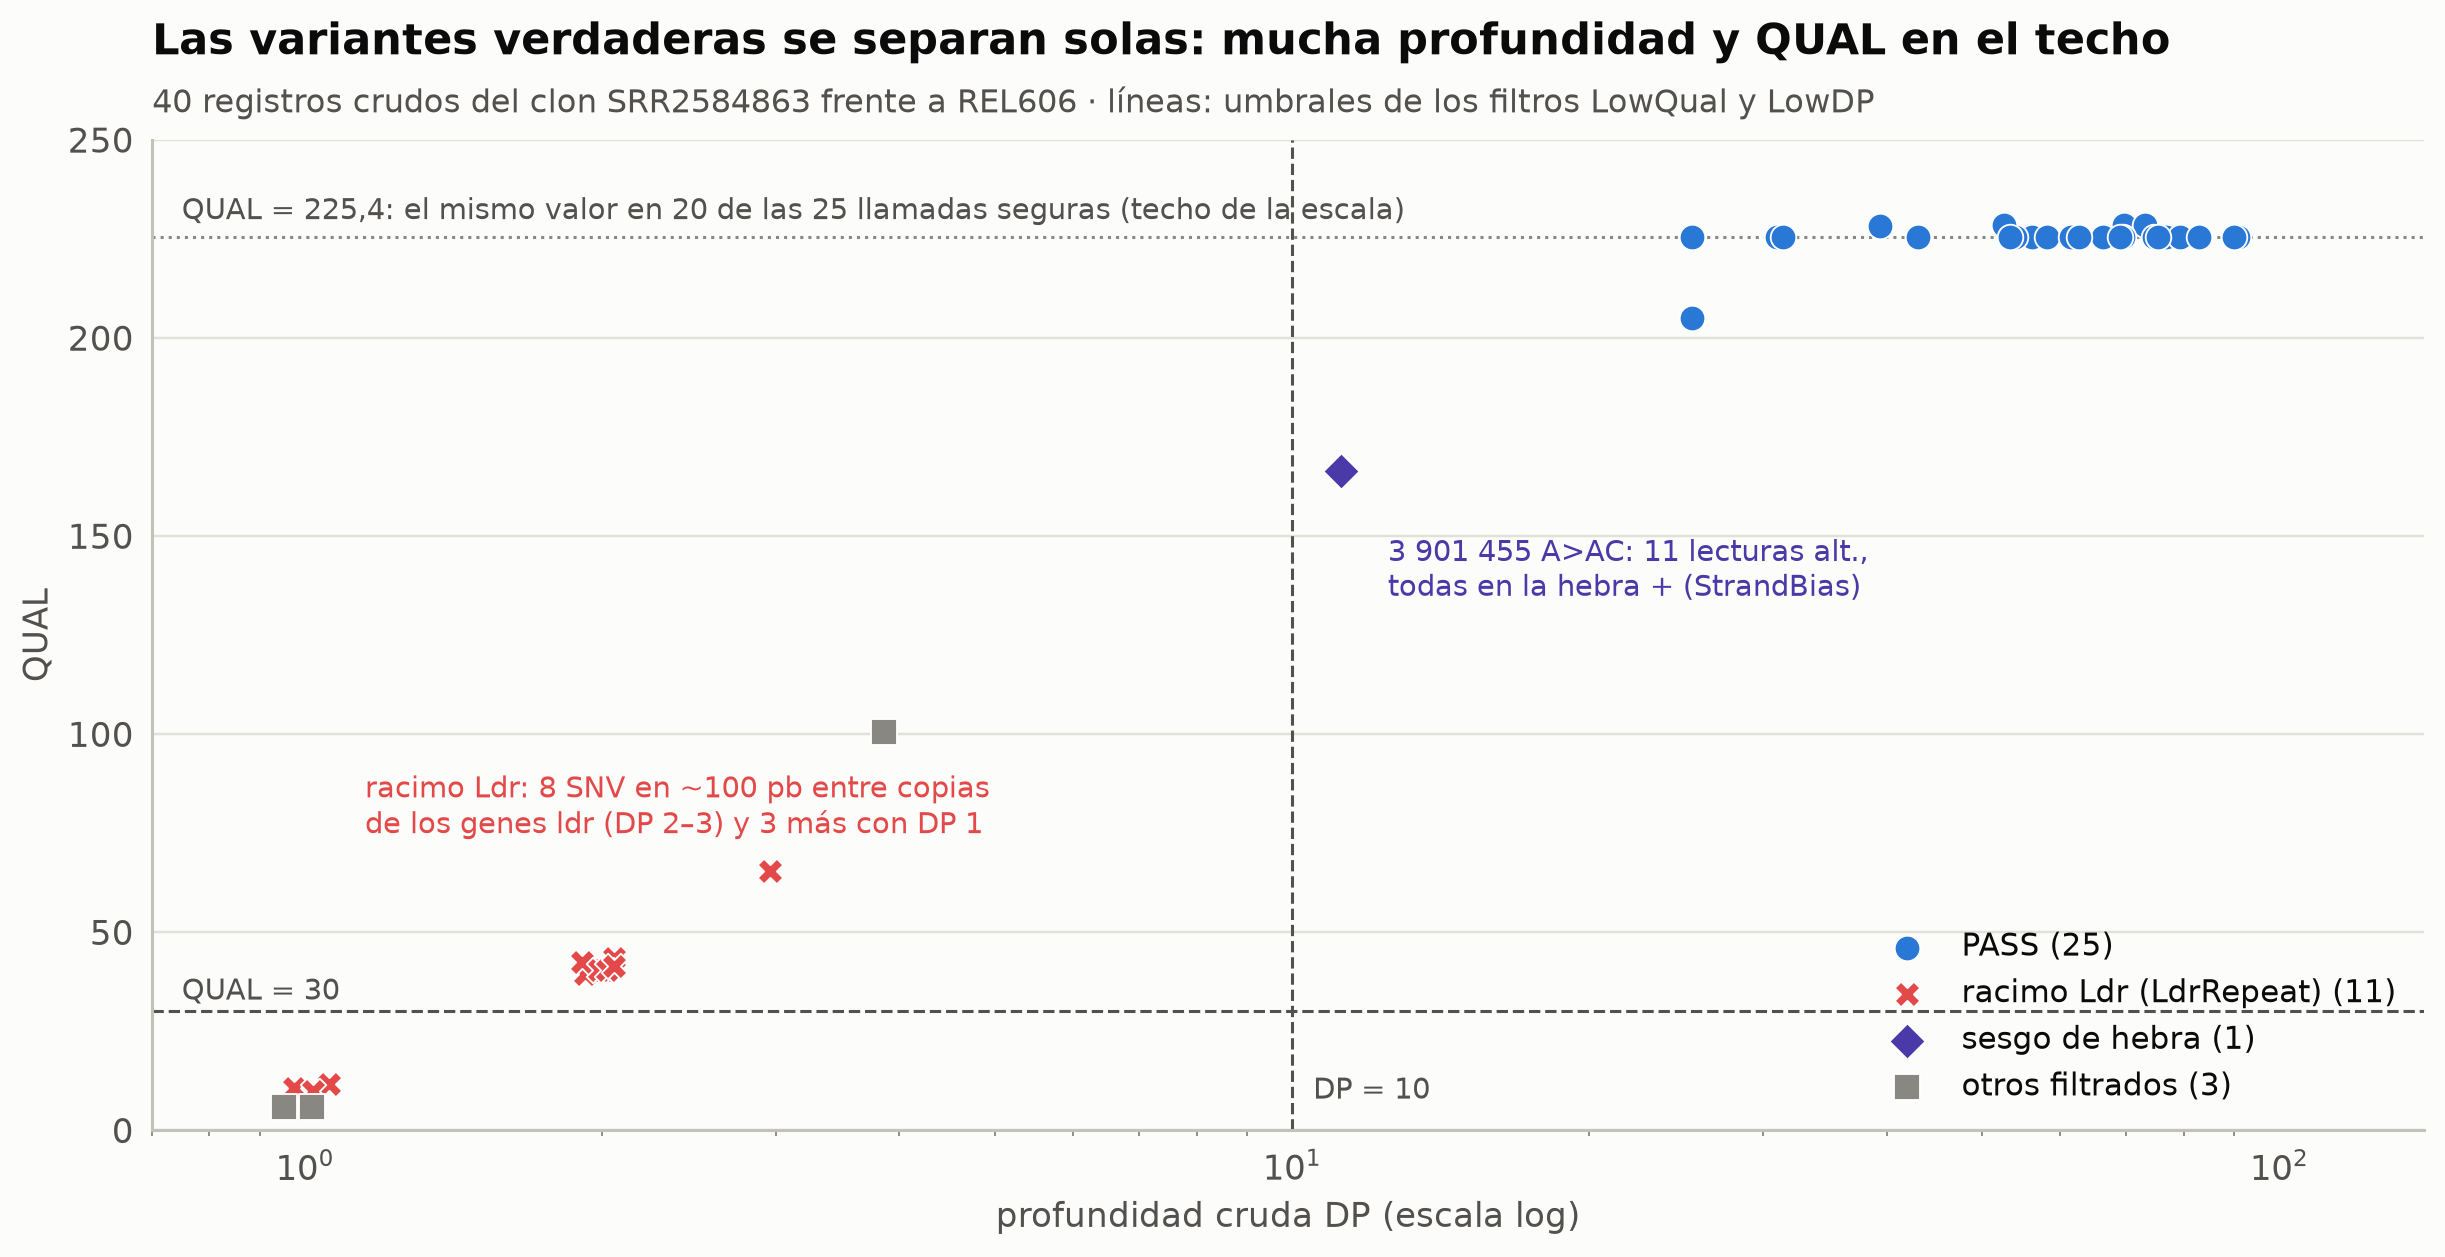

In [14]:
fig, ax = plt.subplots(figsize=(11, 5.6))
groups = [("PASS", ec.BLUE, "o", "PASS"), ("LdrRepeat", ec.RED, "X", "racimo Ldr (LdrRepeat)"),
          ("StrandBias", ec.VIOLET, "D", "sesgo de hebra"), ("other", ec.MUTED, "s", "otros filtrados")]
def group_of(f):
    if f == "PASS": return "PASS"
    if "LdrRepeat" in f: return "LdrRepeat"
    if "StrandBias" in f: return "StrandBias"
    return "other"
raw["group"] = raw.FILTER.map(group_of)
jit = np.random.default_rng(3).uniform(-0.06, 0.06, len(raw))
for g, col, mk, lab in groups:
    d = raw[raw.group == g]
    ax.scatter(d.dp * np.exp(jit[d.index]), d.qual, s=70, color=col, marker=mk, label=f"{lab} ({len(d)})",
               edgecolor="white", lw=0.6, zorder=3)
ax.set_xscale("log"); ax.set_xlim(0.7, 140); ax.set_ylim(0, 250)
ax.axhline(30, color=ec.INK_2, ls="--", lw=1); ax.axvline(10, color=ec.INK_2, ls="--", lw=1)
ax.text(0.75, 33, "QUAL = 30", fontsize=9.5, color=ec.INK_2)
ax.text(10.5, 8, "DP = 10", fontsize=9.5, color=ec.INK_2)
ax.axhline(225.4, color=ec.MUTED, ls=":", lw=1)
ax.text(0.75, 230, "QUAL = 225,4: el mismo valor en 20 de las 25 llamadas seguras (techo de la escala)",
        fontsize=9.5, color=ec.INK_2)
sb = raw[raw.group == "StrandBias"].iloc[0]
ax.text(12.5, 150, f"{sb.npos:,}".replace(",", " ") + f" {sb.nref}>{sb.nalt}: {sb.alt_fwd} lecturas alt.,\n"
        "todas en la hebra + (StrandBias)", fontsize=9.5, color=ec.VIOLET, va="top")
ax.text(1.15, 75, "racimo Ldr: 8 SNV en ~100 pb entre copias\nde los genes ldr (DP 2–3) y 3 más con DP 1",
        fontsize=9.5, color=ec.RED)
ax.set_xlabel("profundidad cruda DP (escala log)"); ax.set_ylabel("QUAL")
ax.legend(loc="lower right", frameon=False, fontsize=10)
ec.title(ax, "Las variantes verdaderas se separan solas: mucha profundidad y QUAL en el techo",
         "40 registros crudos del clon SRR2584863 frente a REL606 · líneas: umbrales de los filtros LowQual y LowDP")
plt.show()

> 🔎 **Qué observamos.** Las variantes seguras forman una nube compacta arriba a la derecha: 26–91 lecturas y QUAL
> exactamente igual a 225,4 en 20 de las 25 (las demás, entre 205 y 228). Que tantas llamadas compartan el mismo valor es una observación empírica que
> delata un **techo** de la escala de `bcftools`: por encima de él, QUAL ya no distingue entre variantes seguras. Abajo a la izquierda, el **racimo Ldr**: 11 registros (8 SNV en ~100 pb con DP 2–3 + 3 de una sola lectura en el
> mismo hueco), justo entre copias casi idénticas de genes toxina-antitoxina. Es la firma clásica de lecturas que
> pertenecen a otra copia y se alinearon aquí. Un caso más sutil es la inserción de 3 901 455: QUAL alto (166) pero
> **las 11 lecturas que la apoyan vienen de la misma hebra**. No la descartamos del todo: la marcamos y la dejamos
> fuera del resumen, que es lo que haría un laboratorio antes de validarla por otra vía (p. ej., Sanger).

Ahora anotamos **todos** los registros (también los filtrados, para ver qué nos habríamos perdido o inventado).

In [15]:
ann_rows = []
for r in raw.itertuples():
    hits = annotate(r.npos, r.nref, r.nalt)
    a = hits[0]
    ann_rows.append(dict(pos=r.npos, ref=r.nref, alt=r.nalt, qual=round(r.qual, 1), dp=r.dp, FILTER=r.FILTER,
                         type="SNV" if len(r.nref) == len(r.nalt) == 1 else
                              ("INS" if len(r.nalt) > len(r.nref) else "DEL"),
                         consequence=a["term"], impact=a["impact"], gene=a["gene"], locus_tag=a["locus_tag"],
                         product=a["product"], strand=a["strand"], distance=a["distance"],
                         codon=a.get("codon_change", ""), hgvs_c=a.get("hgvs_c", ""), hgvs_p=a.get("hgvs_p", ""),
                         note=a["note"],
                         others="; ".join(f"{h['term']}:{h['gene']}" for h in hits[1:])))
ann = pd.DataFrame(ann_rows)
passed = ann[ann.FILTER == "PASS"].reset_index(drop=True)
show = passed[["pos", "ref", "alt", "consequence", "impact", "gene", "codon", "hgvs_p", "distance", "note"]].copy()
show["ref"] = show.ref.map(short); show["alt"] = show.alt.map(short)
show["note"] = show.note.str.slice(0, 22)
with pd.option_context("display.width", 200, "display.max_colwidth", 30):
    print(f"{len(passed)} variantes PASS anotadas\n")
    print(show.to_string(index=False))

25 variantes PASS anotadas

    pos ref          alt             consequence   impact        gene   codon             hgvs_p  distance                   note
   9972   T            G        missense_variant MODERATE        satP AAC>ACC      p.(Asn174Thr)         0                       
 263235   G            T coding_sequence_variant MODIFIER ECB_RS01240                                    0 CDS no canónica (despl
 281923   G            T      intergenic_variant MODIFIER   ecpR–ykgL                                  369                       
 377000   T            G coding_sequence_variant MODIFIER ECB_RS01790                                    0 CDS no canónica (despl
 433359   C           CT   upstream_gene_variant MODIFIER        hupB                                  129                       
 473901   C          CCG      frameshift_variant     HIGH        ybaL               p.(Ala469fs)         0                       
 648692   C            T        missense_variant MODERATE     

In [16]:
print("Consecuencias (variantes PASS):")
print(passed.consequence.value_counts().to_string())
print("\nConsecuencias de los registros filtrados:")
print(ann[ann.FILTER != "PASS"].groupby(["FILTER", "consequence"]).size().to_string())

Consecuencias (variantes PASS):
consequence
missense_variant           13
coding_sequence_variant     4
upstream_gene_variant       2
frameshift_variant          2
downstream_gene_variant     2
intergenic_variant          1
inframe_insertion           1

Consecuencias de los registros filtrados:
FILTER                   consequence                       
LowDP                    non_coding_transcript_exon_variant    1
LowDP;LdrRepeat          downstream_gene_variant               5
                         upstream_gene_variant                 3
LowQual;LowDP            coding_sequence_variant               1
                         non_coding_transcript_exon_variant    1
LowQual;LowDP;LdrRepeat  downstream_gene_variant               2
                         upstream_gene_variant                 1
StrandBias               frameshift_variant                    1


> 🔎 **Qué observamos.** De las 25 variantes que pasan los filtros, **13 son de sentido erróneo** y **ninguna es
> sinónima** (volveremos a este dato en la sección 6). Hay dos `frameshift_variant` (*ybaL* y *tamB*), una inserción en
> marco de 24 pb (8 aminoácidos duplicados en una proteína hipotética, dentro de una repetición `CAGCC…`) y cinco
> variantes fuera de genes. Los registros filtrados cuentan otra historia: las 11 SNV del racimo Ldr caen **entre**
> las copias de *ldr*, como `upstream`/`downstream`; si no las hubiésemos filtrado, habrían inflado artificialmente la
> lista de variantes reguladoras.

**Un caso que merece cautela: los elementos IS1.** Cuatro variantes PASS caen en transposasas de IS1, que nuestro
anotador marca como `coding_sequence_variant` porque la CDS no es canónica. Obsérvelas con detalle:

In [17]:
is1 = passed[passed["product"].str.contains("IS1", na=False)].merge(raw[["npos", "mq"]], left_on="pos",
                                                                         right_on="npos")
for r in is1.itertuples():
    f = feat[feat.locus_tag == r.locus_tag].iloc[0]
    o = r.pos - f.start if f.strand == "+" else f.end - r.pos
    print(f"{r.pos:>9,} {r.ref}>{r.alt}  {r.locus_tag}  hebra {f.strand}  codón {o//3 + 1:>3}  posición {o%3 + 1}"
          f"  DP={r.dp:>2}  MQ={r.mq}")
print(f"\nDP mediana del resto de variantes PASS: {passed[~passed.pos.isin(is1.pos)].dp.median():.0f}")

  263,235 G>T  ECB_RS01240  hebra +  codón 130  posición 2  DP=32  MQ=55
  377,000 T>G  ECB_RS01790  hebra -  codón 154  posición 3  DP=39  MQ=54
2,407,766 A>C  ECB_RS23940  hebra -  codón 130  posición 2  DP=26  MQ=54
2,618,472 G>T  ECB_RS12910  hebra +  codón 130  posición 2  DP=30  MQ=55

DP mediana del resto de variantes PASS: 67


> 🔎 **Qué observamos.** Tres de las cuatro caen **en el mismo codón (130), en la misma posición**, de tres copias
> distintas de IS1, con calidad de mapeo algo menor (54–55) y aproximadamente la mitad de la profundidad típica. Es lo
> que esperaríamos si las lecturas de una copia de IS1 que difiere en ese sitio se repartieran entre varias copias casi
> idénticas: el mismo problema del racimo Ldr, pero a mayor escala. **No podemos afirmarlo con estos datos**, pero es
> una hipótesis razonable que un analista cuidadoso anotaría y comprobaría (por ejemplo, con lecturas largas). Lo
> importante: la anotación hereda todos los problemas del mapeo, y en elementos repetidos hay que leer con lupa.

### 5.1 El mapa del genoma

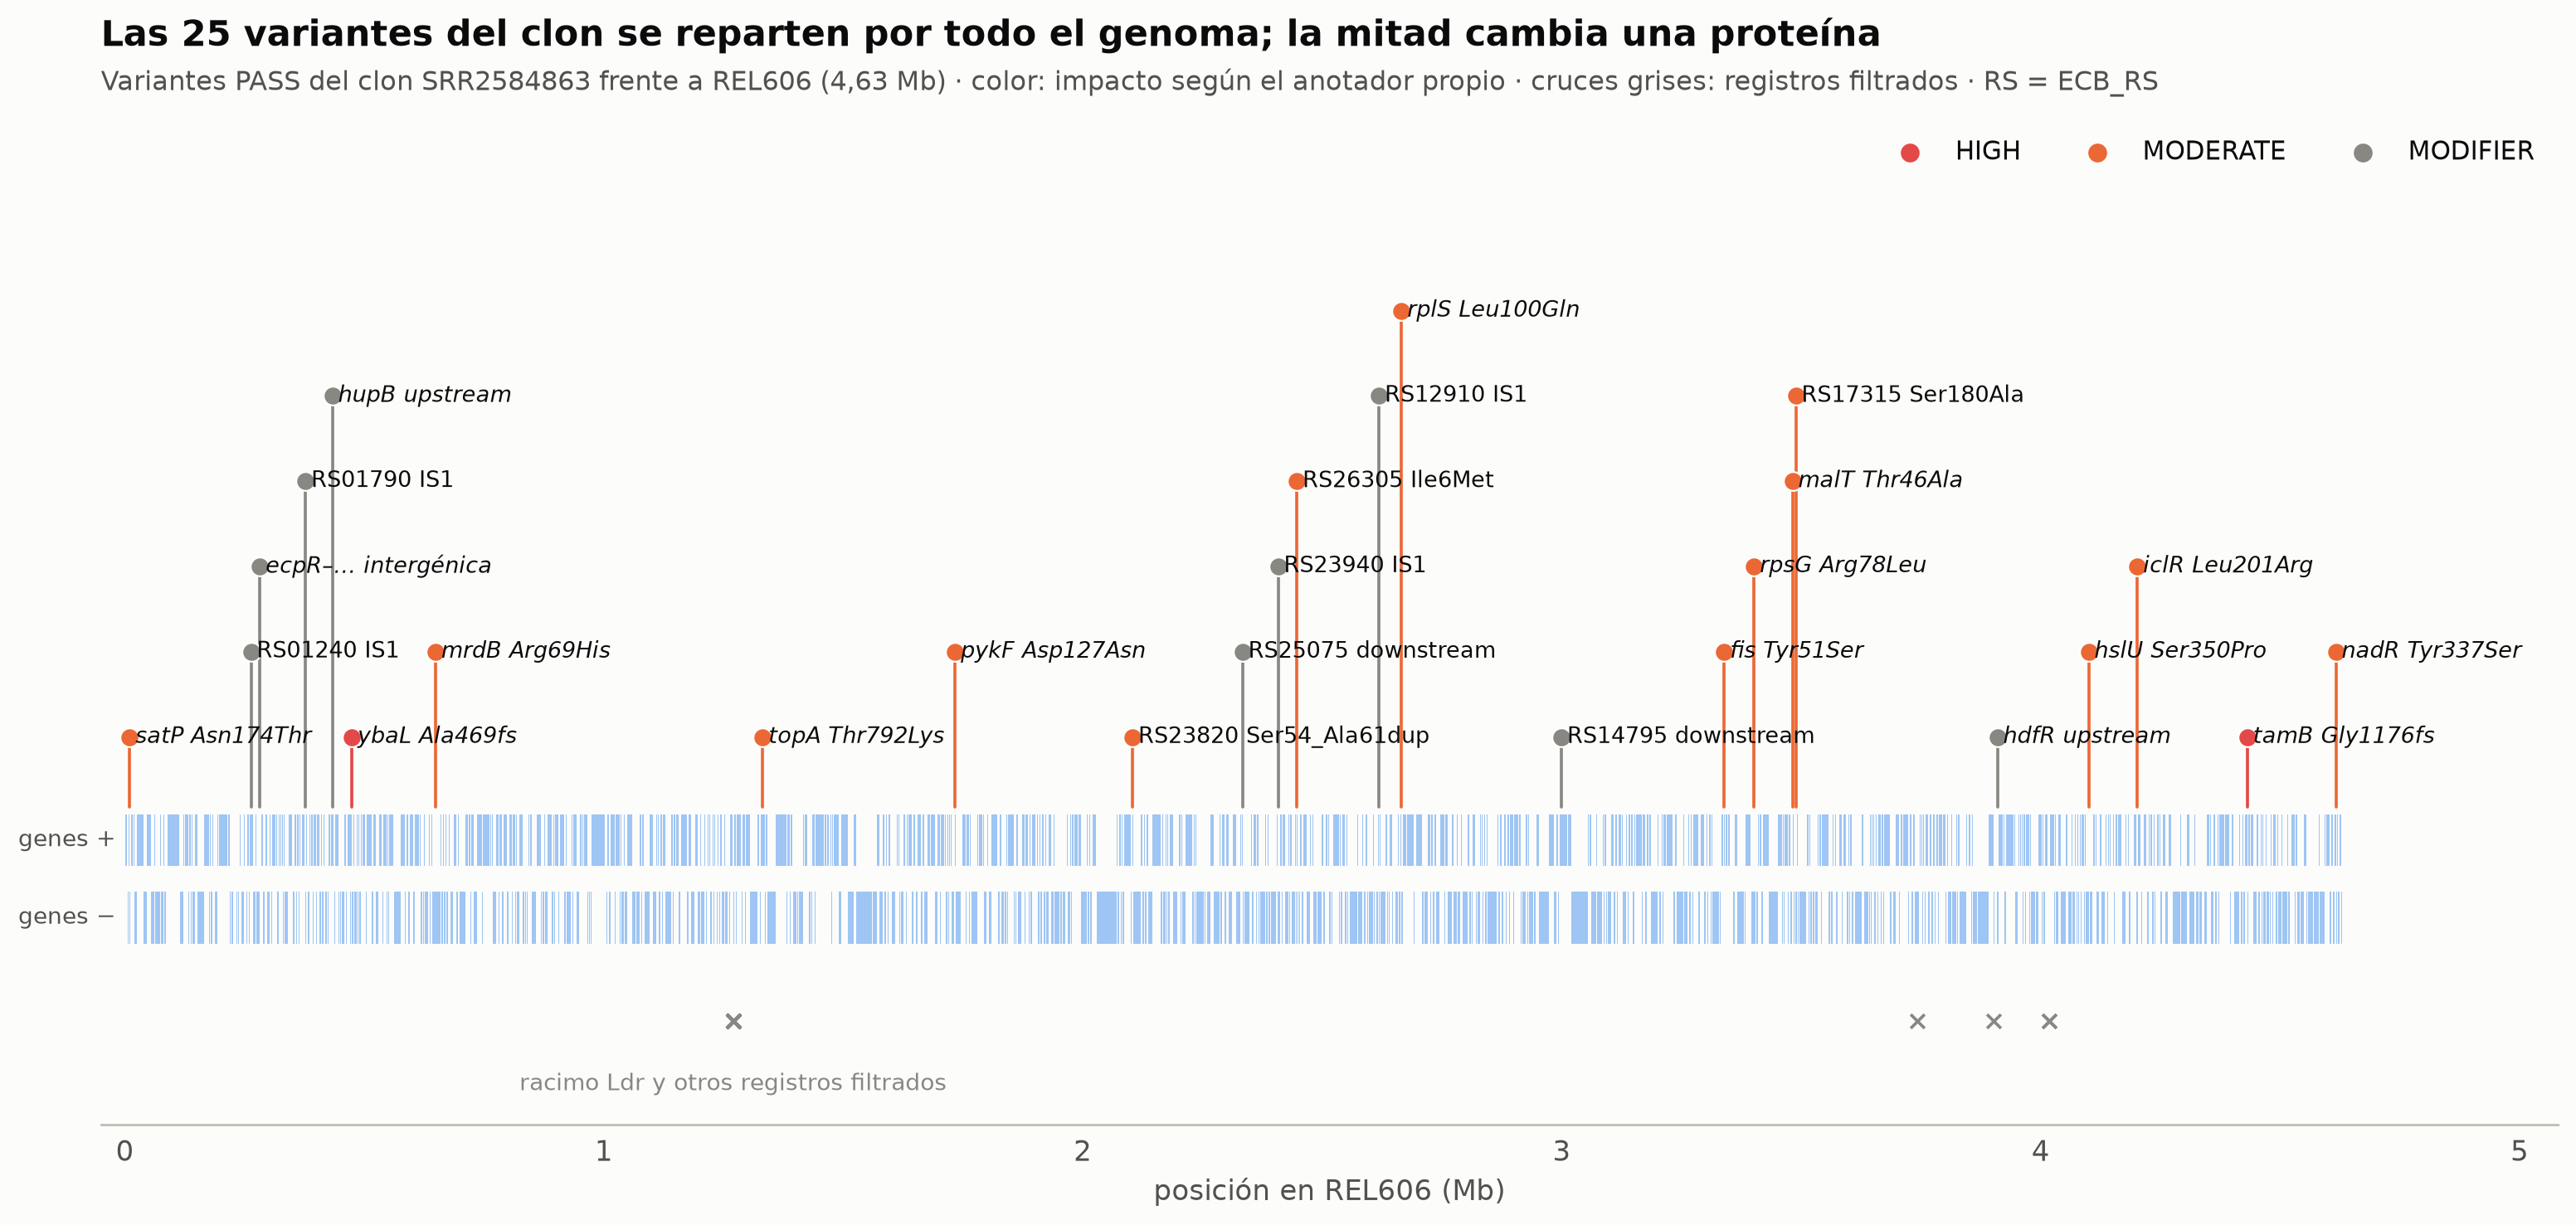

In [18]:
L = len(GENOME)
top_h = 0
fig, ax = plt.subplots(figsize=(14, 6.6))
# pista de genes: una marca fina por CDS, arriba hebra +, abajo hebra −
for strand, y0 in (("+", 0.05), ("-", -0.25)):
    d = cds[cds.strand == strand]
    ax.broken_barh(list(zip(d.start / 1e6, (d.end - d.start) / 1e6)), (y0, 0.2), color=ec.SEQ_BLUE[2], lw=0)
ax.text(-0.02, 0.15, "genes +", ha="right", va="center", fontsize=9, color=ec.INK_2)
ax.text(-0.02, -0.15, "genes −", ha="right", va="center", fontsize=9, color=ec.INK_2)
# filtrados: pequeñas cruces bajo la pista
flt = ann[ann.FILTER != "PASS"]
ax.scatter(flt.pos / 1e6, np.full(len(flt), -0.55), marker="x", s=30, color=ec.MUTED, lw=1.2)
ax.text(1.27, -0.75, "racimo Ldr y otros registros filtrados", ha="center", va="top", fontsize=9, color=ec.MUTED)
# variantes PASS: alfileres con etiquetas escalonadas para que no se pisen
SHORT = {"coding_sequence_variant": "IS1", "upstream_gene_variant": "upstream",
         "downstream_gene_variant": "downstream", "intergenic_variant": "intergénica"}
NLEV = 9
levels_end = [-1.0] * NLEV
for r in passed.sort_values("pos").itertuples():
    x = r.pos / 1e6
    label = r.gene.replace("ECB_RS", "RS") if "–" not in r.gene else r.gene.split("–")[0] + "–…"
    extra = (r.hgvs_p.replace("p.(", "").replace(")", "") if r.hgvs_p else SHORT[r.consequence])
    txt = f"{label} {extra}"
    width = 0.029 * len(txt) + 0.03                   # ancho aproximado de la etiqueta en Mb
    free = [i for i, e in enumerate(levels_end) if e < x]
    lev = free[0] if free else int(np.argmin(levels_end))
    levels_end[lev] = x + width
    h = 0.55 + lev * 0.33
    top_h = max(h, globals().get("top_h", 0))
    col = IMPACT_COLOR[r.impact]
    ax.plot([x, x], [0.28, h], color=col, lw=1.2)
    ax.scatter([x], [h], s=55, color=col, zorder=3, edgecolor="white", lw=0.7)
    ax.text(x + 0.012, h, txt, va="center", fontsize=8.8, color=ec.INK,
            style="italic" if r.gene[:3].islower() else "normal")
for imp, col in IMPACT_COLOR.items():
    if imp in set(passed.impact):
        ax.scatter([], [], color=col, s=55, label=imp)
ax.legend(loc="upper right", ncol=3, frameon=False, fontsize=10)
ax.set_xlim(-0.05, L / 1e6 + 0.45); ax.set_ylim(-0.95, top_h + 0.75)
ax.set_yticks([]); ax.set_xlabel("posición en REL606 (Mb)"); ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ec.title(ax, "Las 25 variantes del clon se reparten por todo el genoma; la mitad cambia una proteína",
         "Variantes PASS del clon SRR2584863 frente a REL606 (4,63 Mb) · color: impacto según el anotador propio · "
         "cruces grises: registros filtrados · RS = ECB_RS")
plt.show()

> 🔎 **Qué observamos.** No hay «puntos calientes» evidentes a lo largo del cromosoma: las variantes seguras se
> reparten por todo el genoma, como esperaríamos de mutaciones que surgen al azar y se fijan de una en una. Las cruces
> grises se amontonan en torno a 1,27 Mb: el racimo Ldr que filtramos.

La versión interactiva permite explorar cada variante con todos sus detalles. El eje vertical es QUAL, así que se ven
a la vez **la anotación y la razón del filtrado**.

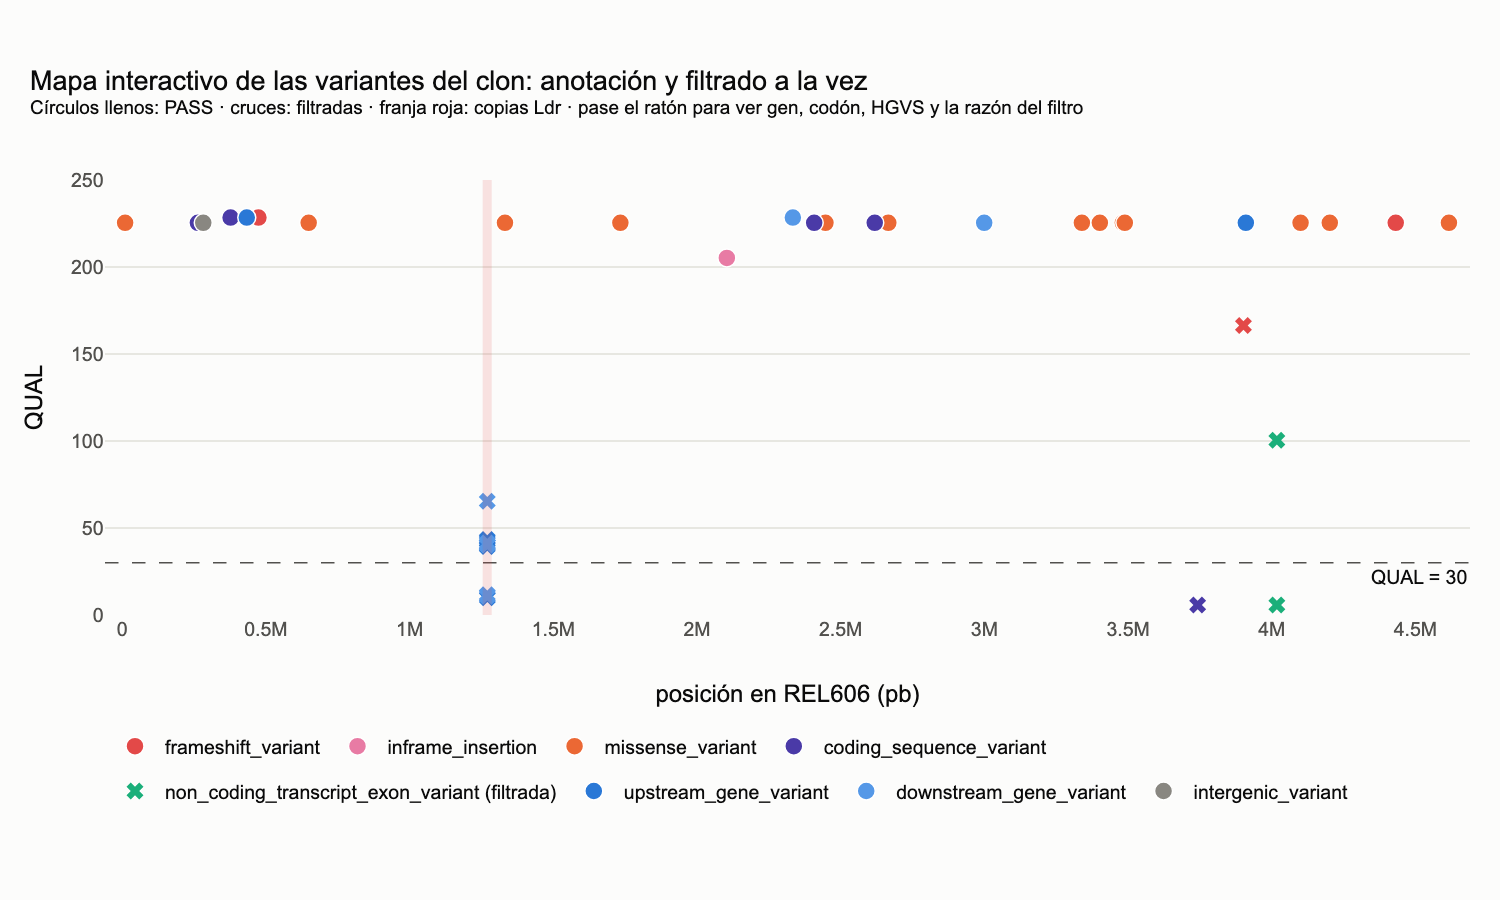

In [19]:
fig = go.Figure()
term_order = [t for t in SEVERITY if t in set(ann.consequence)]
term_colors = {"frameshift_variant": ec.RED, "inframe_insertion": ec.MAGENTA, "missense_variant": ec.ORANGE,
               "coding_sequence_variant": ec.VIOLET, "non_coding_transcript_exon_variant": ec.AQUA,
               "upstream_gene_variant": ec.BLUE, "downstream_gene_variant": ec.SEQ_BLUE[5],
               "intergenic_variant": ec.MUTED}
for t in term_order:
    for is_pass in (True, False):
        d = ann[(ann.consequence == t) & ((ann.FILTER == "PASS") == is_pass)]
        if d.empty:
            continue
        hover = [(f"<b>{r.gene}</b> · {r['product'][:60]}<br>"
                  f"{r.pos:,} {short(r.ref)}>{short(r.alt)} ({r.type})<br>"
                  f"consecuencia: <b>{r.consequence}</b> ({r.impact})"
                  + (f"<br>codón {r.codon} · {r.hgvs_c} · {r.hgvs_p}" if r.codon else
                     (f"<br>{r.hgvs_p}" if r.hgvs_p else ""))
                  + (f"<br>a {r.distance} pb del gen" if r.distance else "")
                  + (f"<br><i>{r.note}</i>" if r.note else "")
                  + f"<br>QUAL {r.qual:.1f} · DP {r.dp} · FILTER <b>{r.FILTER}</b>") for _, r in d.iterrows()]
        fig.add_trace(go.Scatter(
            x=d.pos, y=d.qual, mode="markers", name=t + ("" if is_pass else " (filtrada)"),
            legendgroup=t, showlegend=is_pass or t == "non_coding_transcript_exon_variant",
            marker=dict(size=12 if is_pass else 10, color=term_colors[t],
                        line=dict(color="white", width=1 if is_pass else 0), symbol="circle" if is_pass else "x"),
            text=hover, hovertemplate="%{text}<extra></extra>"))
fig.add_hline(y=30, line=dict(color=ec.INK_2, dash="dash", width=1), annotation_text="QUAL = 30",
              annotation_position="bottom right")
fig.add_vrect(x0=LDR[0] - 15_000, x1=LDR[1] + 15_000, fillcolor=ec.RED, opacity=0.15, line_width=0)
fig.update_xaxes(title_text="posición en REL606 (pb)", range=[-60_000, L + 60_000])
fig.update_yaxes(title_text="QUAL", range=[0, 250])
fig.update_layout(height=600, margin=dict(t=120, l=70, r=20, b=190),
                  title="Mapa interactivo de las variantes del clon: anotación y filtrado a la vez"
                        "<br><sup>Círculos llenos: PASS · cruces: filtradas · franja roja: copias Ldr · pase el ratón "
                        "para ver gen, codón, HGVS y la razón del filtro</sup>",
                  legend=dict(orientation="h", yanchor="top", y=-0.25, x=0))
fig.show()

### 5.2 Resumen por gen

La pregunta biológica es: **¿qué genes cambió la evolución en este linaje?** Resumimos las variantes PASS que alteran
una proteína (impacto HIGH o MODERATE).

Para interpretar la lista usaremos una fuente verificada: Tenaillon et al. (2016) secuenciaron 264 genomas de las doce
poblaciones del LTEE y encontraron una fuerte **evolución paralela**: 57 genes con dos o más mutaciones concentraban
el 50,1 % de las mutaciones no sinónimas, aunque sólo representan el 2,1 % del genoma codificante. Su **Tabla 1**
lista los 15 genes con más evidencia de paralelismo en las poblaciones no mutadoras (*pykF*, *iclR*, *spoT*, *nadR*,
*hslU*, *yijC*/*fabR*, *topA*, *malT*, *mrdA*, *mreB*, *infB*, *arcA*, *argR*, *rplF*, *mreC*). Comprobamos cuáles de
nuestros genes aparecen en ella.

In [20]:
TENAILLON_T1 = {"pykF", "iclR", "spoT", "nadR", "hslU", "yijC", "fabR", "topA", "malT", "mrdA", "mreB", "infB",
                "arcA", "argR", "rplF", "mreC"}
prot = passed[passed.impact.isin(["HIGH", "MODERATE"])].copy()
prot["Tenaillon 2016, Tabla 1"] = np.where(prot.gene.isin(TENAILLON_T1), "sí", "")
summary = prot[["gene", "product", "consequence", "hgvs_p", "Tenaillon 2016, Tabla 1"]].copy()
summary["product"] = summary["product"].str.slice(0, 55)
with pd.option_context("display.width", 200, "display.max_colwidth", 60):
    print(summary.to_string(index=False))
n_t1 = (prot["Tenaillon 2016, Tabla 1"] == "sí").sum()
print(f"\n{len(prot)} genes con la proteína alterada · {n_t1} de ellos en la Tabla 1 de Tenaillon et al. (2016)")

       gene                                                 product        consequence             hgvs_p Tenaillon 2016, Tabla 1
       satP                              acetate uptake transporter   missense_variant      p.(Asn174Thr)                        
       ybaL            YbaL family putative K(+) efflux transporter frameshift_variant       p.(Ala469fs)                        
       mrdB                  peptidoglycan glycosyltransferase MrdB   missense_variant       p.(Arg69His)                        
       topA                                type I DNA topoisomerase   missense_variant      p.(Thr792Lys)                      sí
       pykF                                    pyruvate kinase PykF   missense_variant      p.(Asp127Asn)                      sí
ECB_RS23820                                    hypothetical protein  inframe_insertion p.(Ser54_Ala61dup)                        
ECB_RS26305                                            protein YpeD   missense_variant    

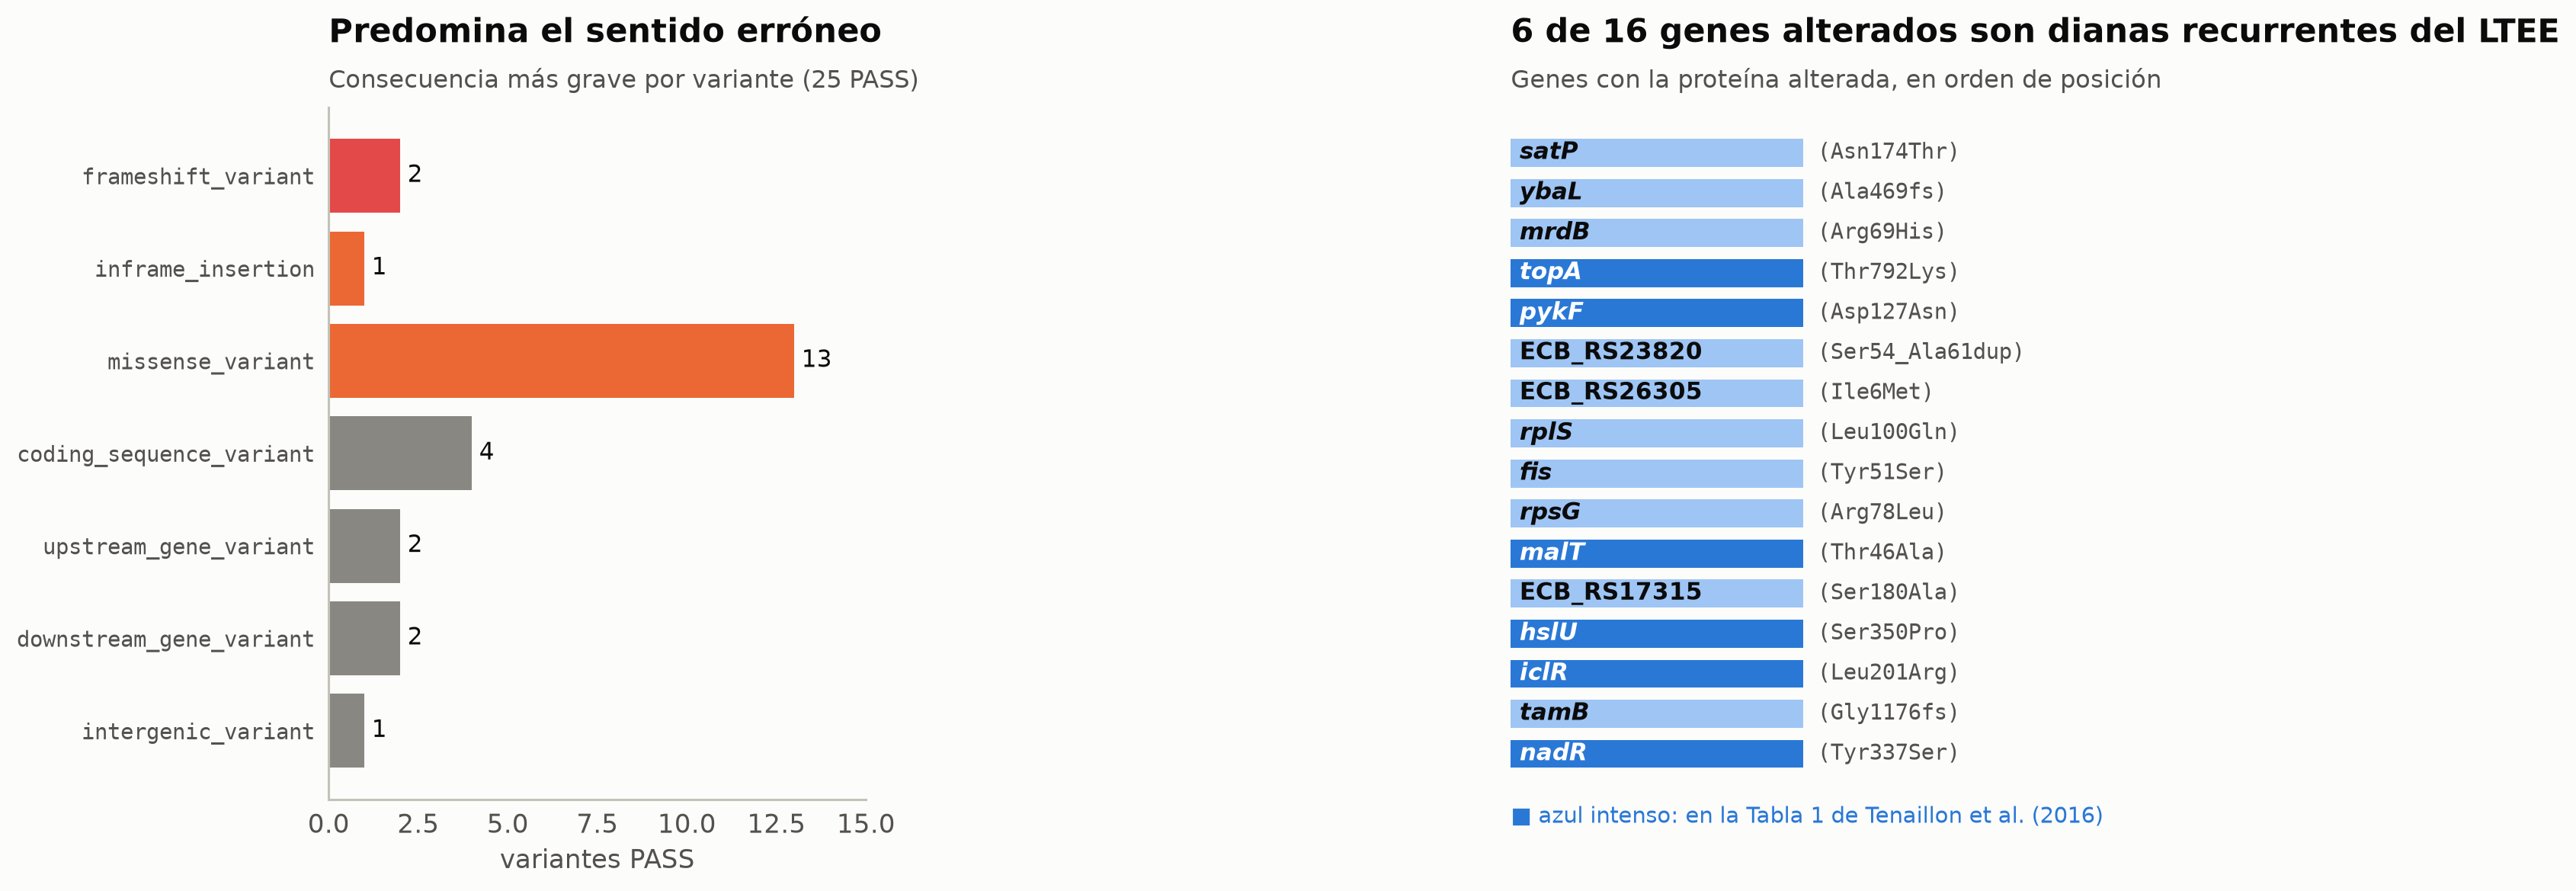

In [21]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw=dict(width_ratios=[1, 1.25], wspace=0.55))
vc = passed.consequence.value_counts().reindex([t for t in SEVERITY if t in set(passed.consequence)])
a1.barh(range(len(vc)), vc.values, color=[IMPACT_COLOR[IMPACT[t]] for t in vc.index])
a1.set_yticks(range(len(vc)), vc.index, family="monospace", fontsize=9.5); a1.invert_yaxis()
for i, v in enumerate(vc.values):
    a1.text(v + 0.2, i, str(v), va="center", fontsize=10)
a1.set_xlabel("variantes PASS"); a1.grid(axis="y", visible=False); a1.set_xlim(0, vc.max() + 2)
ec.title(a1, "Predomina el sentido erróneo", "Consecuencia más grave por variante (25 PASS)")
p2 = prot.sort_values("pos")
ys = np.arange(len(p2))
cols = [ec.BLUE if g in TENAILLON_T1 else ec.SEQ_BLUE[2] for g in p2.gene]
a2.barh(ys, 1, color=cols, height=0.7)
for y, r in zip(ys, p2.itertuples()):
    a2.text(0.03, y, r.gene, va="center", fontsize=10, color="white" if r.gene in TENAILLON_T1 else ec.INK,
            style="italic" if r.gene[:3].islower() else "normal", fontweight="bold")
    a2.text(1.05, y, r.hgvs_p.replace("p.", ""), va="center", fontsize=9.5, family="monospace", color=ec.INK_2)
a2.set_xlim(0, 2.3); a2.set_yticks([]); a2.set_xticks([]); a2.invert_yaxis(); a2.grid(False)
for sp in a2.spines.values():
    sp.set_visible(False)
a2.text(0, len(p2) + 0.3, "■ azul intenso: en la Tabla 1 de Tenaillon et al. (2016)", fontsize=9.5, color=ec.BLUE,
        va="top")
ec.title(a2, f"{n_t1} de {len(prot)} genes alterados son dianas recurrentes del LTEE",
         "Genes con la proteína alterada, en orden de posición")
plt.show()

> 🔎 **Qué observamos.** Seis de los 16 genes con la proteína alterada (*topA*, *pykF*, *malT*, *hslU*, *iclR* y
> *nadR*) están entre los 15 genes con más evolución paralela en todo el LTEE. Un gen de *E. coli* cualquiera tiene
> muy poca probabilidad de estar en esa lista de 15 entre más de 4 000; encontrar seis sugiere con fuerza que este
> clon lleva varias de las **mutaciones beneficiosas** típicas del experimento (metabolismo central con *pykF*,
> superenrollamiento del ADN con *topA*, regulación del ciclo del glioxilato con *iclR*…). La anotación no demuestra
> que cada una sea adaptativa, pero **prioriza**: si tuviésemos que elegir qué mutaciones reconstruir en el ancestro
> para medir su efecto, empezaríamos por estas.

✅ **Compruebe su comprensión.** ¿Por qué el resumen por gen excluye las variantes `coding_sequence_variant` de IS1
aunque tengan FILTER = PASS?

---

## 6. ¿Cuántas sinónimas esperaríamos? Mutación aleatoria frente a lo observado

Hemos encontrado 13 SNV codificantes en CDS canónicas y **ninguna es sinónima**. ¿Es raro?

**Paso 1: la expectativa uniforme.** Si todas las sustituciones de todos los codones con sentido fueran igual de
probables, la fracción sinónima sería la del libro: $p_S = 134/549 = 0{,}244$.

**Paso 2: la expectativa del genoma real.** Pero los codones no son igual de frecuentes: REL606 usa mucho `CTG` (Leu)
y poco `CTA`. La fracción esperada debe **ponderarse por el uso de codones**:

$$
p_S = \frac{\sum_{c} n_c \, s_c}{\sum_{c} 9\, n_c},
$$

| Símbolo | Significado |
|---|---|
| $n_c$ | Número de veces que aparece el codón con sentido $c$ en las CDS canónicas de REL606 |
| $s_c$ | Número de sus 9 vecinos de una base que son sinónimos (0 a 8) |
| $p_S$ | Probabilidad de que una SNV aleatoria en la región codificante sea sinónima |

**Paso 3: ¿cuán sorprendente es el resultado?** Si cada una de las $n$ SNV es sinónima con probabilidad $p_S$ de forma
independiente, el número de sinónimas $X$ sigue una binomial y

$$
P(X = 0) = (1 - p_S)^{n}.
$$

Con $n = 13$ y $p_S \approx 0{,}24$, a mano: $0{,}76^{13} \approx 0{,}028$.

🤔 **Antes de ejecutar, prediga:** ¿la ponderación por uso de codones subirá o bajará $p_S$? (Pista: en *E. coli*
abundan los codones de leucina `CTG` y de alanina, glicina, valina… con la 3.ª posición «libre».)

In [22]:
canon = feat[(feat.type == "CDS") & feat.canonical]
usage = Counter()
for f in canon.itertuples():
    s = gene_seq(f)[:-3]                                  # sin el codón de parada final
    usage.update(s[i:i + 3] for i in range(0, len(s), 3))
cls_codon = {c: Counter(classify(c, p, b) for p in range(3) for b in "ACGT" if b != c[p]) for c in CODE if c not in STOPS}
tot_sites = sum(9 * usage[c] for c in cls_codon)
expected = {k: sum(usage[c] * cls_codon[c][k] for c in cls_codon) / tot_sites for k in ("sin", "mis", "non")}
uniform = {k: tot[k] / sense for k in ("sin", "mis", "non")}

snv_cds = passed[(passed.type == "SNV") & passed.consequence.isin(
    ["synonymous_variant", "missense_variant", "stop_gained", "stop_lost", "start_lost"])]
obs = {"sin": (snv_cds.consequence == "synonymous_variant").sum(),
       "mis": (snv_cds.consequence == "missense_variant").sum(),
       "non": (snv_cds.consequence == "stop_gained").sum()}
n = len(snv_cds)
pS = expected["sin"]
print(f"Codones contados en {len(canon):,} CDS canónicas: {sum(usage.values()):,}")
print(f"{'':<18}{'uniforme':>10}{'REL606':>10}{'observado':>12}")
for k, lab in (("sin", "sinónimas"), ("mis", "sentido erróneo"), ("non", "stop gained")):
    print(f"{lab:<18}{uniform[k]:>10.3f}{expected[k]:>10.3f}{obs[k]:>7d} / {n}")
print(f"\nP(0 sinónimas en {n} | p_S = {pS:.3f}) = {(1 - pS) ** n:.4f}")
print(f"Sinónimas esperadas: {n * pS:.1f}")

Codones contados en 4,230 CDS canónicas: 1,318,001
                    uniforme    REL606   observado
sinónimas              0.244     0.236      0 / 13
sentido erróneo        0.714     0.729     13 / 13
stop gained            0.042     0.036      0 / 13

P(0 sinónimas en 13 | p_S = 0.236) = 0.0304
Sinónimas esperadas: 3.1


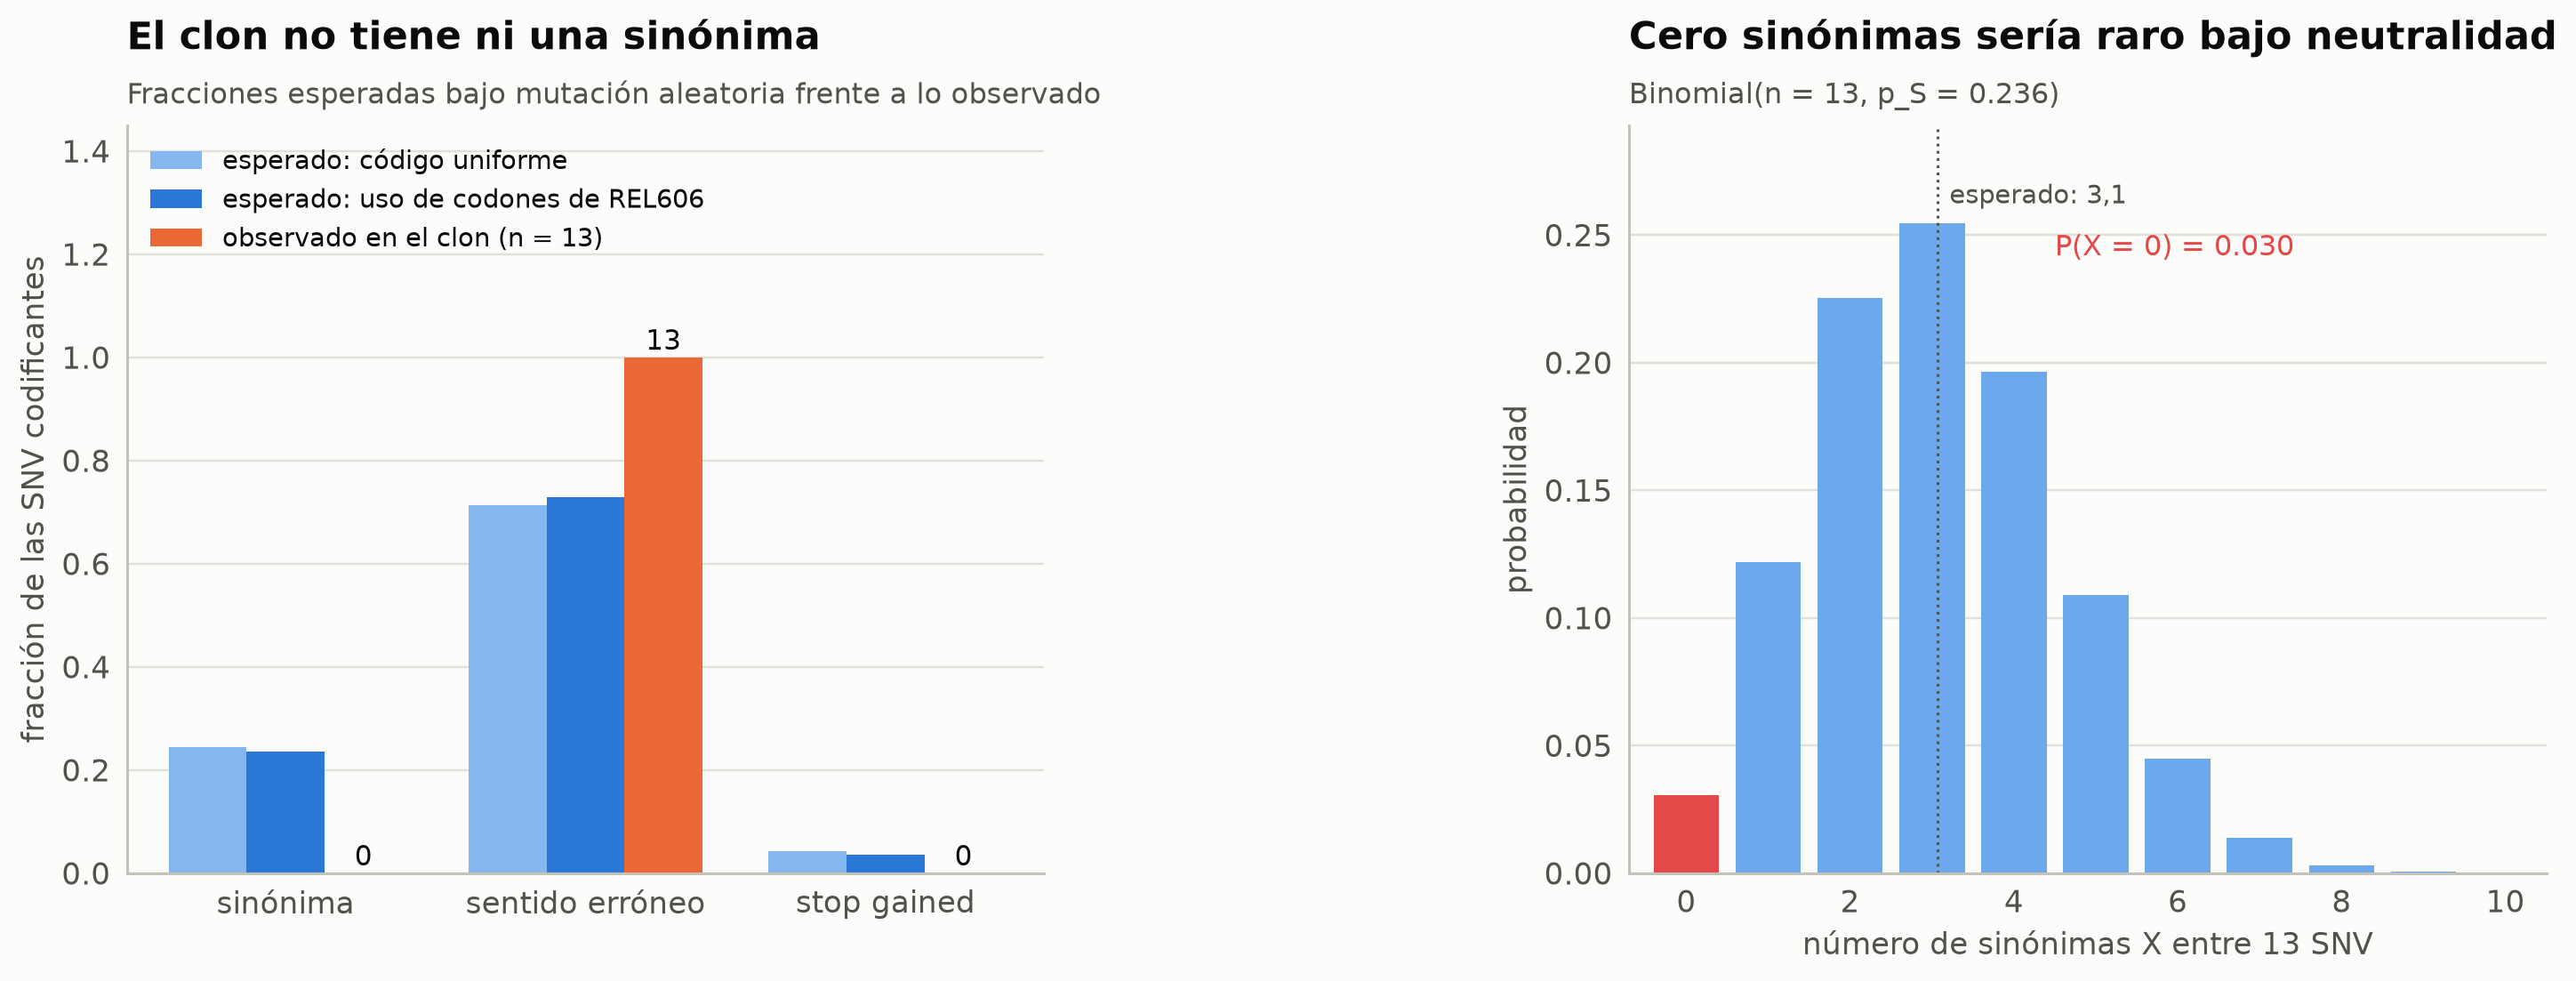

In [23]:
from scipy.stats import binom
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.9), gridspec_kw=dict(wspace=0.3))
labs = ["sinónima", "sentido erróneo", "stop gained"]
keys = ["sin", "mis", "non"]
xx = np.arange(3); w = 0.26
a1.bar(xx - w, [uniform[k] for k in keys], w, color=ec.SEQ_BLUE[3], label="esperado: código uniforme")
a1.bar(xx, [expected[k] for k in keys], w, color=ec.BLUE, label="esperado: uso de codones de REL606")
a1.bar(xx + w, [obs[k] / n for k in keys], w, color=ec.ORANGE, label=f"observado en el clon (n = {n})")
for i, k in enumerate(keys):
    a1.text(i + w, obs[k] / n + 0.015, f"{obs[k]}", ha="center", fontsize=10, color=ec.INK)
a1.set_xticks(xx, labs); a1.set_ylabel("fracción de las SNV codificantes"); a1.set_ylim(0, 1.45)
a1.legend(loc="upper left", frameon=False, fontsize=9.5); a1.grid(axis="x", visible=False)
ec.title(a1, "El clon no tiene ni una sinónima", "Fracciones esperadas bajo mutación aleatoria frente a lo observado")
k_ = np.arange(0, n + 1)
pm = binom.pmf(k_, n, pS)
a2.bar(k_, pm, color=[ec.RED if k == 0 else ec.SEQ_BLUE[4] for k in k_], width=0.8)
a2.annotate(f"P(X = 0) = {pm[0]:.3f}", xy=(0, pm[0]), xytext=(4.5, pm.max() * 0.95), fontsize=10.5, color=ec.RED,
            arrowprops=dict(arrowstyle="->", color=ec.RED))
a2.axvline(n * pS, color=ec.INK_2, ls=":", lw=1)
a2.text(n * pS + 0.15, pm.max() * 1.03, f"esperado: {n*pS:.1f}".replace(".", ","), fontsize=9.5, color=ec.INK_2)
a2.set_xlabel(f"número de sinónimas X entre {n} SNV"); a2.set_ylabel("probabilidad")
a2.set_xlim(-0.7, 10.5); a2.set_ylim(0, pm.max() * 1.15); a2.grid(axis="x", visible=False)
ec.title(a2, "Cero sinónimas sería raro bajo neutralidad", f"Binomial(n = {n}, p_S = {pS:.3f})")
plt.show()

> 🔎 **Qué observamos.** El uso de codones de REL606 sube un poco $p_S$ respecto a la expectativa uniforme (hay muchos
> codones con la 3.ª posición «libre»). Aun así, esperaríamos unas 3 sinónimas entre 13 SNV codificantes, y observar
> cero tiene una probabilidad de sólo un 2–3 %. Hay dos lecturas compatibles, y conviene nombrarlas:
>
> * **Selección positiva:** las mutaciones que se fijan en el LTEE están enriquecidas en cambios de proteína
>   beneficiosos. Tenaillon et al. (2016) midieron que las mutaciones no sinónimas
>   se acumularon unas 17 veces más rápido que las sinónimas durante las primeras 500 generaciones y unas 3,4 veces
>   más rápido a lo largo de 50 000. Las sinónimas, casi siempre neutras, se fijan más despacio.
> * **Tamaño de muestra:** con $n = 13$, un valor-p de 0,03 es una pista, no una demostración. Con los 264 genomas
>   del LTEE, Tenaillon et al. pudieron hacer este análisis con potencia estadística.
>
> Este es exactamente el razonamiento de $d_N/d_S$: comparar lo observado con lo esperado bajo un modelo mutacional.
> gnomAD hace lo mismo, gen por gen, para medir cuánta **restricción** soporta cada gen humano (sección 9).

---

## 7. Herramientas profesionales: VEP, SnpEff, ANNOVAR y `bcftools csq`

Nuestro anotador cabe en una pantalla porque *E. coli* es sencilla. En un genoma humano, con ~20 000 genes que
codifican proteínas, decenas de miles de transcritos alternativos, sitios de *splicing* y regiones reguladoras, se usan
herramientas especializadas:

| Herramienta | Quién | Idea central | Dónde escribe el resultado |
|---|---|---|---|
| **VEP** (*Variant Effect Predictor*) | Ensembl (McLaren et al., 2016) | Efecto sobre genes, transcritos, proteínas y regiones reguladoras; añade frecuencias poblacionales, identificadores conocidos, SIFT y PolyPhen | campo `INFO/CSQ` |
| **SnpEff** | Cingolani et al. (2012) | Rápido; asigna las categorías de impacto HIGH–MODIFIER; construye bases de datos de organismos no modelo a partir de un FASTA y un GTF/GenBank | campo `INFO/ANN` |
| **ANNOVAR** | Wang et al. (2010) | Tres tipos de anotación: basada en genes, en regiones y en filtros contra bases de datos; pionera en priorizar candidatas en exomas | tablas y VCF |
| **`bcftools csq`** | Danecek et al. (2021) | Tiene en cuenta la **fase**: evalúa juntas dos variantes del mismo codón | campo `INFO/BCSQ` |

Los subcampos de `CSQ` y `ANN` van separados por barras verticales (`|`) y su significado se describe en la cabecera
del VCF. Los comandos típicos (los del libro):

```bash
# VEP con caché local (GRCh38) y salida VCF
vep -i final.vcf.gz --cache --offline --assembly GRCh38 \
    --everything --pick --vcf --compress_output bgzip \
    -o anotado.vcf.gz
# Alternativa: SnpEff (base de datos preconstruida)
java -Xmx8g -jar snpEff.jar GRCh38.105 final.vcf.gz \
    > anotado_snpeff.vcf
```

**El caso de las dos variantes en un mismo codón.** Si un codón `GCT` recibe a la vez `G>A` en la 1.ª posición y `T>C`
en la 3.ª **en el mismo cromosoma**, el codón real es `ACC` (Thr), aunque cada variante por separado diga `ACT` (Thr) y
`GCC` (Ala, sinónima). Por eso `bcftools csq` pide variantes **en fase**. En un haploide como *E. coli* todas las
variantes están en fase, y nuestro anotador ya las evalúa una a una sobre el mismo cromosoma (ninguna de las 25 comparte
codón con otra).

### 7.1 ⚙️ Opcional (sólo Colab): comparar con SnpEff

La celda siguiente descarga SnpEff (~50 MB), construye una base de datos de REL606 a partir de su GenBank y anota las
variantes PASS. Tarda unos minutos, así que **está desactivada por defecto**: cambie `RUN_SNPEFF = True` para
ejecutarla. Si la ejecuta, compare su columna `ANN` con nuestra tabla: deberían coincidir las consecuencias de las
variantes en CDS canónicas.

In [24]:
RUN_SNPEFF = False            # ← cámbielo a True en Colab para comparar con SnpEff (tarda unos minutos)

def write_vcf(df, path, chrom="NC_012967.1"):
    """Escribe un VCF mínimo con las variantes normalizadas."""
    with open(path, "w") as fh:
        fh.write("##fileformat=VCFv4.2\n")
        fh.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        for r in df.itertuples():
            fh.write(f"{chrom}\t{r.pos}\t.\t{r.ref}\t{r.alt}\t{r.qual}\tPASS\t.\n")

if RUN_SNPEFF and IN_COLAB and shutil.which("java"):
    import zipfile
    if not os.path.exists("snpEff/snpEff.jar"):
        urllib.request.urlretrieve("https://snpeff.blob.core.windows.net/versions/snpEff_latest_core.zip", "snpEff.zip")
        zipfile.ZipFile("snpEff.zip").extractall(".")
    os.makedirs("snpEff/data/REL606", exist_ok=True)
    gb_url = ("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_012967.1"
              "&rettype=gbwithparts&retmode=text")
    urllib.request.urlretrieve(gb_url, "snpEff/data/REL606/genes.gbk")
    locus = open("snpEff/data/REL606/genes.gbk").readline().split()[1]      # nombre del cromosoma para SnpEff
    with open("snpEff/snpEff.config", "a") as fh:
        fh.write("\nREL606.genome : Escherichia coli B REL606\n"
                 f"REL606.{locus}.codonTable : Bacterial_and_Plant_Plastid\n")
    subprocess.run("cd snpEff && java -Xmx4g -jar snpEff.jar build -genbank -noCheckCds -noCheckProtein REL606",
                   shell=True, check=True)
    write_vcf(passed, "clon_PASS.vcf", chrom=locus)
    out = subprocess.run("java -Xmx4g -jar snpEff/snpEff.jar -noStats REL606 clon_PASS.vcf", shell=True,
                         capture_output=True, text=True).stdout
    rows_se = []
    for line in out.splitlines():
        if line.startswith("#"):
            continue
        c = line.split("\t")
        ann1 = c[7].split("ANN=")[1].split(",")[0].split("|")          # primera (más grave) anotación
        rows_se.append(dict(pos=int(c[1]), snpeff=ann1[1], impact_snpeff=ann1[2], gene_snpeff=ann1[3],
                            hgvs_p_snpeff=ann1[10]))
    comp = passed[["pos", "gene", "consequence", "hgvs_p"]].merge(pd.DataFrame(rows_se), on="pos")
    print(comp.to_string(index=False))
else:
    print("SnpEff no se ejecutó (RUN_SNPEFF = False, o no estamos en Colab con Java).")
    print("Nuestro anotador ya produjo la tabla equivalente en la sección 5.")

SnpEff no se ejecutó (RUN_SNPEFF = False, o no estamos en Colab con Java).
Nuestro anotador ya produjo la tabla equivalente en la sección 5.


---

## 8. 🧪 Parte clínica: *TP53* en Ensembl VEP (API REST)

Cambiamos de escenario. Una oncóloga recibe el informe de secuenciación de un tumor y de la línea germinal de una
paciente joven con antecedentes familiares de cáncer. Aparecen variantes en ***TP53***, el gen que codifica p53. Para
interpretarlas no basta con saber qué aminoácido cambia: necesita **frecuencias poblacionales**, **predicciones** y lo
que **otros laboratorios** han concluido. Ensembl VEP reúne todo eso y tiene una **API REST** pública (Lección 2.2):

```
https://rest.ensembl.org/vep/human/hgvs/ENST00000269305.9:c.524G>A?CADD=1&canonical=1&mane=1&pick=1…
```

Consultaremos cinco variantes del transcrito canónico de *TP53* (`ENST00000269305`, equivalente MANE Select de
`NM_000546.6`):

| HGVS c. | Proteína | Por qué la elegimos |
|---|---|---|
| `c.524G>A` | p.Arg175His (R175H) | Mutación puntual muy frecuente («punto caliente») en cáncer |
| `c.743G>A` | p.Arg248Gln (R248Q) | El ejemplo HGVS del libro; otro punto caliente |
| `c.818G>A` | p.Arg273His (R273H) | Punto caliente en el contacto con el ADN |
| `c.637C>T` | p.Arg213Ter (R213\*) | Variante nula (`stop_gained`) |
| `c.215C>G` | p.Pro72Arg (P72R) | Polimorfismo común de la población |

**Cómo cargamos los datos.** Seguimos el mismo orden que en todo el curso: **1)** la copia local
`../data/api_cache/` (si trabaja con el repositorio clonado); **2)** el servicio en vivo; **3)** la copia de respaldo en
GitHub. Así la lección funciona sin internet y con el servidor caído, y usted puede refrescar los datos poniendo
`REFRESH = True`. Validamos siempre que la respuesta sea JSON (un servidor saturado puede devolver una página HTML
de error con código 503).

In [25]:
ENSEMBL = "https://rest.ensembl.org"
REFRESH = False                                   # True: pedir primero al servidor en vivo
PROVENANCE = []
_offline = False                                  # si el servidor no responde, no insistimos en esta sesión

def fetch_json(key, url, params=None, retries=2):
    """JSON de una API con el orden del curso: local → servicio en vivo → respaldo en GitHub."""
    local = pathlib.Path("..") / "data" / "api_cache" / key
    sources = [("local", None)] if (local.exists() and not REFRESH) else []
    sources += [("API en vivo", url), ("respaldo GitHub", f"{RAW}/data/api_cache/{key}")]
    if local.exists() and REFRESH:
        sources.append(("local", None))
    global _offline
    for name, u in sources:
        if name == "API en vivo" and _offline:
            continue
        try:
            if u is None:
                text = local.read_text()
            else:
                for k in range(retries + 1):
                    r = requests.get(u, params=params if name == "API en vivo" else None,
                                     headers={"Content-Type": "application/json"}, timeout=20)
                    if r.status_code in (429, 503) and k < retries:
                        time.sleep(1.5 * 2 ** k); continue          # servidor ocupado: esperar y reintentar
                    r.raise_for_status(); break
                text = r.text
            data = json.loads(text)                                 # ¿es JSON de verdad?
            PROVENANCE.append(dict(key=key, source=name, time=datetime.datetime.now().isoformat(timespec="seconds")))
            return data
        except Exception as err:
            if name == "API en vivo" and isinstance(err, (requests.ConnectionError, requests.Timeout)):
                _offline = True
            print(f"  ⚠️ {key}: {name} falló ({type(err).__name__}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se pudo obtener {key}")

VEP_PARAMS = {"canonical": 1, "hgvs": 1, "CADD": 1, "mane": 1, "pick": 1, "variant_class": 1, "sift": "b",
              "polyphen": "b"}
TP53_VARIANTS = ["c.524G>A", "c.743G>A", "c.818G>A", "c.637C>T", "c.215C>G"]
vep = {}
for v in TP53_VARIANTS:
    key = f"ensembl_vep_TP53_{v.replace('>', '-')}.json"
    vep[v] = fetch_json(key, f"{ENSEMBL}/vep/human/hgvs/ENST00000269305.9:{v}", VEP_PARAMS)[0]
print(pd.DataFrame(PROVENANCE).to_string(index=False))

                           key source                time
ensembl_vep_TP53_c.524G-A.json  local 2026-09-30T15:23:12
ensembl_vep_TP53_c.743G-A.json  local 2026-09-30T15:23:12
ensembl_vep_TP53_c.818G-A.json  local 2026-09-30T15:23:12
ensembl_vep_TP53_c.637C-T.json  local 2026-09-30T15:23:12
ensembl_vep_TP53_c.215C-G.json  local 2026-09-30T15:23:12


La respuesta de VEP es un JSON anidado. Miremos su esqueleto antes de extraer nada:

In [26]:
r175 = vep["c.524G>A"]
print("claves de primer nivel:", list(r175))
tc = r175["transcript_consequences"][0]
print("\ntranscript_consequences[0]:")
for k in ["transcript_id", "mane_select", "consequence_terms", "impact", "codons", "amino_acids", "hgvsp",
          "sift_score", "sift_prediction", "polyphen_score", "cadd_phred"]:
    print(f"  {k:<18} {tc.get(k)}")
cv = [c for c in r175["colocated_variants"] if c.get("id", "").startswith("rs")][0]
print(f"\nvariante conocida en la misma posición: {cv['id']}")
print("  significado clínico (ClinVar):", cv.get("clin_sig"))
print("  frecuencias gnomAD del alelo A:", {k: v for k, v in cv["frequencies"]["A"].items() if k in ("gnomade", "gnomadg")})

claves de primer nivel: ['allele_string', 'input', 'colocated_variants', 'id', 'transcript_consequences', 'seq_region_name', 'most_severe_consequence', 'end', 'strand', 'assembly_name', 'variant_class', 'start']

transcript_consequences[0]:
  transcript_id      ENST00000269305
  mane_select        NM_000546.6
  consequence_terms  ['missense_variant']
  impact             MODERATE
  codons             cGc/cAc
  amino_acids        R/H
  hgvsp              ENSP00000269305.4:p.Arg175His
  sift_score         0.08
  sift_prediction    tolerated
  polyphen_score     None
  cadd_phred         25.9

variante conocida en la misma posición: rs28934578
  significado clínico (ClinVar): ['likely_pathogenic', 'pathogenic']
  frecuencias gnomAD del alelo A: {'gnomade': 4.104e-06, 'gnomadg': 6.57e-06}


Ahora extraemos una tabla con lo esencial de cada variante. Dos detalles técnicos importantes:

* Las frecuencias vienen indexadas por el **alelo tal como se escribió en la consulta** (`variant_allele`, en la
  orientación del transcrito).
* El significado clínico por alelo (`clin_sig_allele`) viene en cambio en la **hebra + del genoma**. Como *TP53* está
  en la hebra −, hay que complementar el alelo (`c.524G>A` es `C>T` en el cromosoma 17). El campo `clin_sig`, sin
  alelo, mezcla las clasificaciones de **todos** los alelos alternativos de esa posición: usarlo sin cuidado
  atribuiría a nuestra variante lo que ClinVar dice de otra.

In [27]:
def vep_row(v, d):
    t = d["transcript_consequences"][0]
    allele = t["variant_allele"]
    rs = [c for c in d.get("colocated_variants", []) if c.get("id", "").startswith("rs")]
    freqs = rs[0].get("frequencies", {}).get(allele, {}) if rs else {}
    # ClinVar por alelo: `clin_sig_allele` usa la hebra + del genoma; TP53 está en la hebra −
    g_allele = allele.translate(COMP) if d.get("strand") == -1 else allele
    pairs = [x.split(":") for x in rs[0].get("clin_sig_allele", "").split(";") if ":" in x] if rs else []
    clin = sorted({sig for al, sig in pairs if al == g_allele})
    return dict(hgvsc=v, protein=t["hgvsp"].split(":")[1], consequence=t["consequence_terms"][0], impact=t["impact"],
                codons=t.get("codons", ""), sift=t.get("sift_score"), sift_pred=t.get("sift_prediction"),
                polyphen=t.get("polyphen_score"), polyphen_pred=t.get("polyphen_prediction"),
                cadd=t.get("cadd_phred"), af_exomes=freqs.get("gnomade"), af_genomes=freqs.get("gnomadg"),
                rsid=rs[0]["id"] if rs else "", clinvar=", ".join(clin), aa_pos=t.get("protein_start"))

tp53 = pd.DataFrame([vep_row(v, d) for v, d in vep.items()])
with pd.option_context("display.width", 220, "display.max_colwidth", 60):
    print(tp53.drop(columns=["aa_pos"]).fillna("—").to_string(index=False))

   hgvsc     protein      consequence   impact  codons  sift   sift_pred polyphen polyphen_pred  cadd  af_exomes  af_genomes        rsid                                                     clinvar
c.524G>A p.Arg175His missense_variant MODERATE cGc/cAc  0.08   tolerated        —             — 25.90   0.000004    0.000007  rs28934578                               likely_pathogenic, pathogenic
c.743G>A p.Arg248Gln missense_variant MODERATE cGg/cAg  0.01 deleterious        —             — 28.40   0.000006    0.000020  rs11540652 likely_pathogenic, pathogenic, pathogenic/likely_pathogenic
c.818G>A p.Arg273His missense_variant MODERATE cGt/cAt  0.07   tolerated        —             — 24.40   0.000010    0.000020  rs28934576 likely_pathogenic, pathogenic, pathogenic/likely_pathogenic
c.637C>T p.Arg213Ter      stop_gained     HIGH Cga/Tga     —           —        —             — 41.00   0.000001    0.000000 rs397516436                                                  pathogenic
c.215C>G  p.Pro

> 🔎 **Qué observamos.** Cinco lecciones en una tabla:
>
> 1. **Los predictores no son diagnósticos.** R175H y R273H, dos de las mutaciones de *TP53* mejor documentadas como
>    patogénicas, reciben de SIFT «tolerated» (0,08 y 0,07, apenas por encima del umbral 0,05). CADD, en cambio, les da
>    más de 20. Ningún predictor por sí solo decide.
> 2. **Los datos faltan a veces.** PolyPhen no devuelve puntuación para varias de estas variantes en la respuesta de
>    VEP, y SIFT/PolyPhen no se aplican a una variante nula (R213\*). La tabla muestra «—»: nunca rellene un hueco con
>    una suposición.
> 3. **La frecuencia lo dice casi todo.** Las variantes patogénicas tienen frecuencias del orden de $10^{-6}$–$10^{-5}$
>    en gnomAD; P72R (rs1042522) tiene el alelo Arg en más de la mitad de los cromosomas: es el alelo **mayoritario**
>    en gnomAD, aunque la referencia GRCh38 lleve Pro.
> 4. **ClinVar muestra discrepancias.** Para el alelo Arg de P72R hay a la vez envíos «benign» y «pathogenic»: cada
>    remitente clasifica con su propia evidencia y su propio contexto (sección 11).
> 5. **La variante nula** R213\* tiene impacto HIGH y CADD 41: está entre el 0,01 % más deletéreo de todas las SNV
>    posibles del genoma (sección 10).

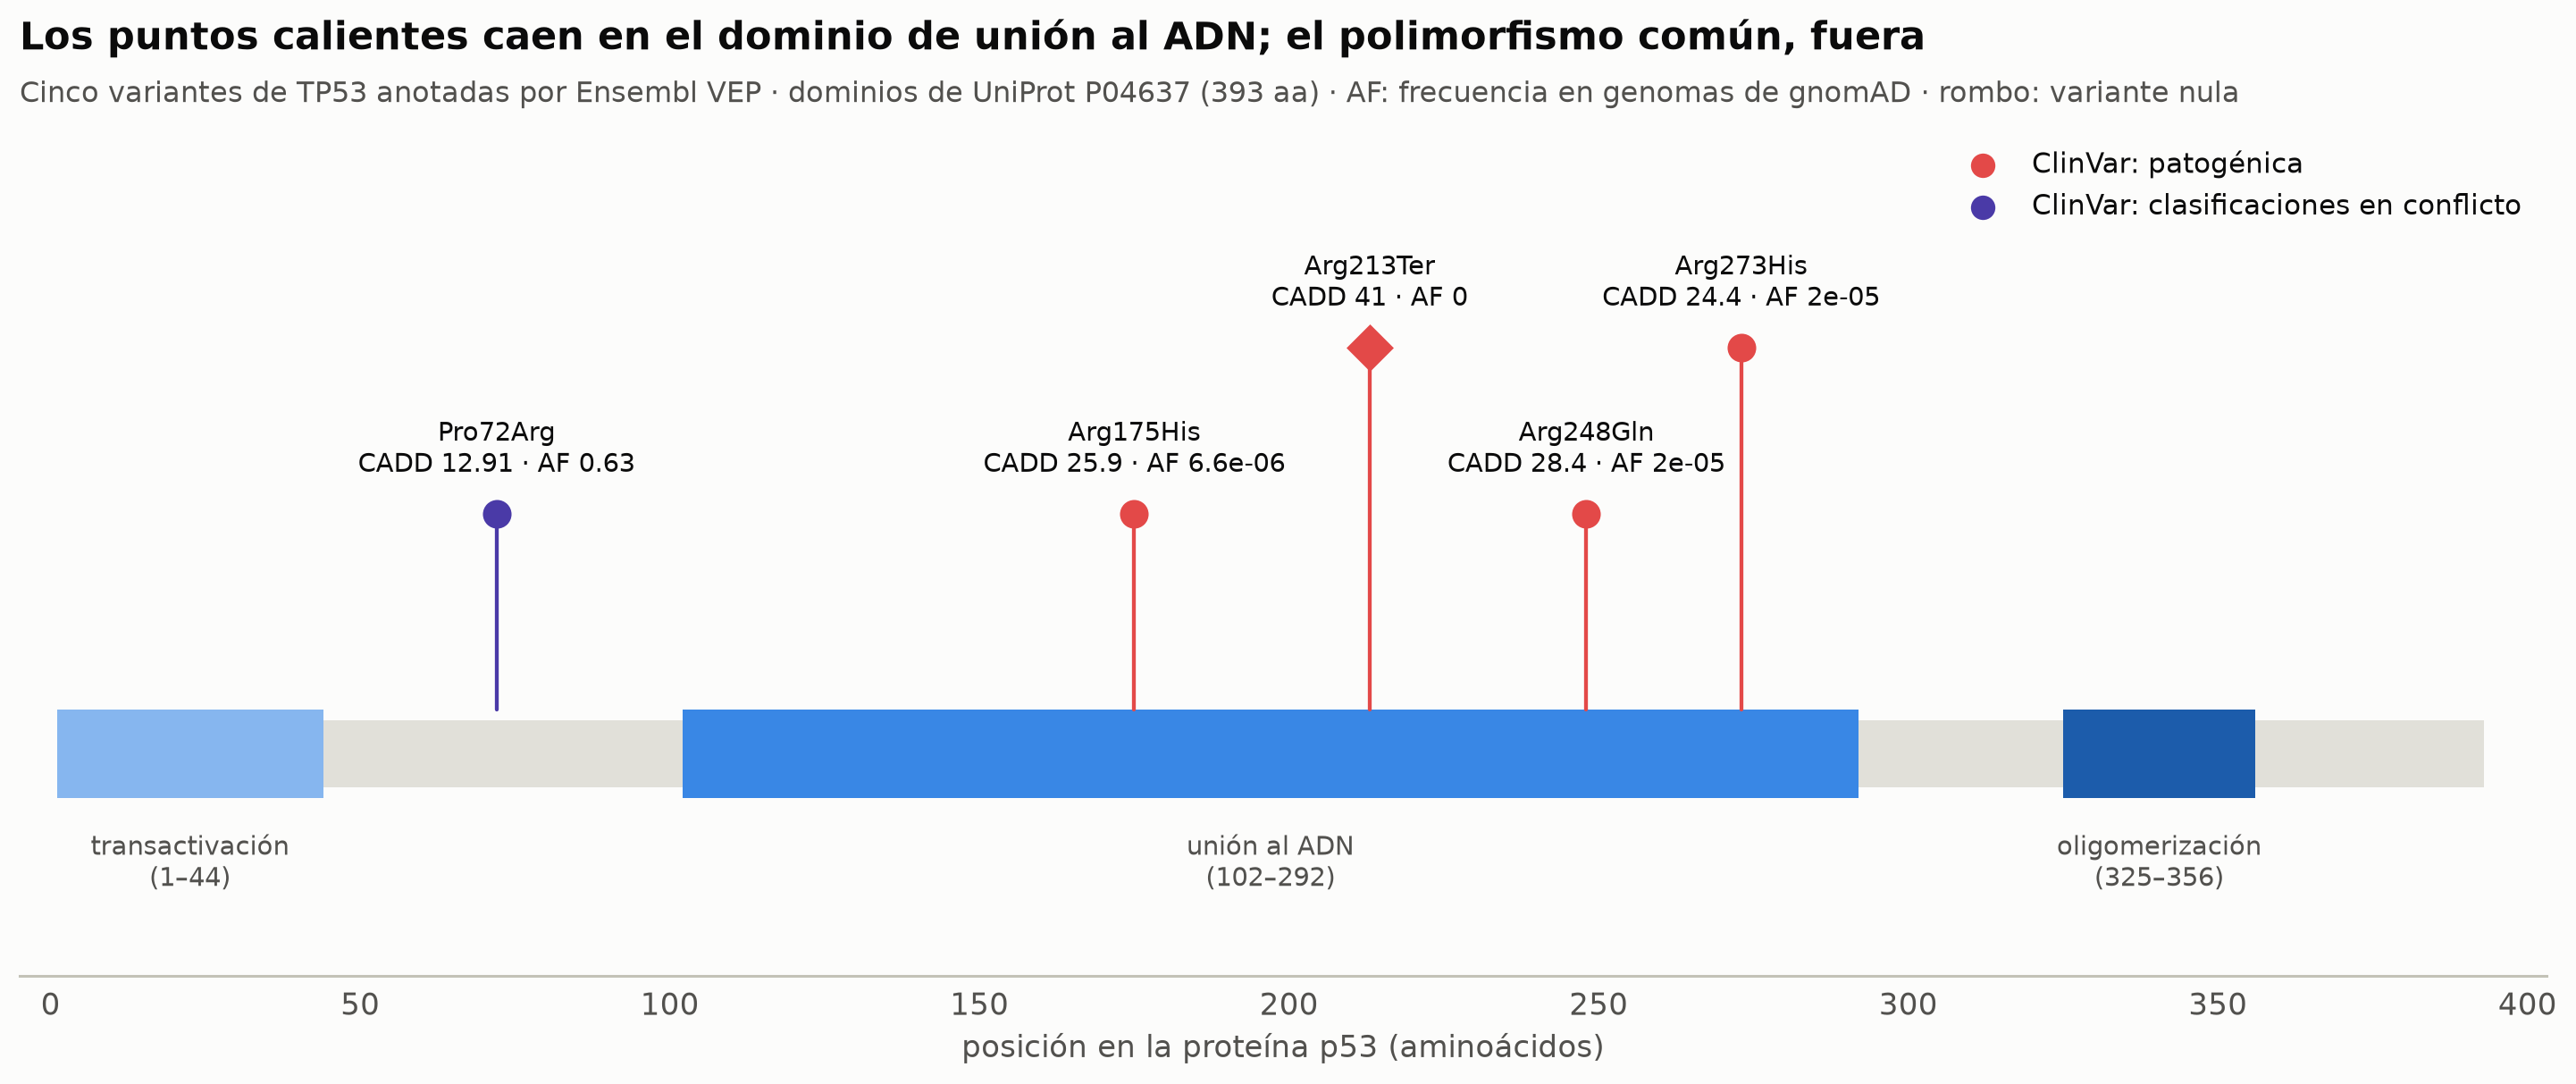

In [28]:
up = fetch_json("uniprot_P04637.json", "https://rest.uniprot.org/uniprotkb/P04637.json")
L_P53 = up["sequence"]["length"]
def feature(ftype, desc=None):
    for f in up["features"]:
        if f["type"] == ftype and (desc is None or f.get("description") == desc):
            return f["location"]["start"]["value"], f["location"]["end"]["value"]
domains = [("transactivación", *feature("Region", "Transcription activation (acidic)"), ec.SEQ_BLUE[3]),
           ("unión al ADN", *feature("DNA binding"), ec.SEQ_BLUE[6]),
           ("oligomerización", *feature("Region", "Oligomerization"), ec.SEQ_BLUE[9])]

def clin_color(c):
    if "pathogenic" in c and "benign" not in c:
        return ec.RED
    if "benign" in c and "pathogenic" in c:
        return ec.VIOLET
    return ec.GREEN if "benign" in c else ec.MUTED

fig, ax = plt.subplots(figsize=(13, 5.4))
ax.add_patch(Rectangle((1, -0.18), L_P53 - 1, 0.36, color=ec.GRID))
for name, a, b, col in domains:
    ax.add_patch(Rectangle((a, -0.24), b - a, 0.48, color=col))
    ax.text((a + b) / 2, -0.42, f"{name}\n({a}–{b})", ha="center", va="top", fontsize=9.5, color=ec.INK_2)
heights = {"c.524G>A": 1.3, "c.743G>A": 1.3, "c.818G>A": 2.2, "c.637C>T": 2.2, "c.215C>G": 1.3}
for r in tp53.itertuples():
    h = heights[r.hgvsc]
    col = clin_color(r.clinvar)
    ax.plot([r.aa_pos, r.aa_pos], [0.24, h], color=col, lw=1.4)
    ax.scatter([r.aa_pos], [h], s=150 if r.impact == "HIGH" else 110, color=col, zorder=3,
               marker="D" if r.impact == "HIGH" else "o", edgecolor="white")
    af = r.af_genomes if r.af_genomes is not None else r.af_exomes
    ax.text(r.aa_pos, h + 0.18, f"{r.protein.replace('p.', '')}\nCADD {r.cadd:g} · AF {af:.2g}", ha="center",
            va="bottom", fontsize=9.5)
for lab, col in [("ClinVar: patogénica", ec.RED), ("ClinVar: clasificaciones en conflicto", ec.VIOLET)]:
    ax.scatter([], [], color=col, s=80, label=lab)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.set_xlim(-5, L_P53 + 10); ax.set_ylim(-1.2, 3.4); ax.set_yticks([]); ax.grid(False)
ax.spines["left"].set_visible(False)
ax.set_xlabel("posición en la proteína p53 (aminoácidos)")
ec.title(ax, "Los puntos calientes caen en el dominio de unión al ADN; el polimorfismo común, fuera",
         f"Cinco variantes de TP53 anotadas por Ensembl VEP · dominios de UniProt P04637 ({L_P53} aa) · "
         "AF: frecuencia en genomas de gnomAD · rombo: variante nula")
plt.show()

---

## 9. Frecuencia poblacional: gnomAD, regla del tres y $f_{\max}$

La pregunta más informativa sobre una variante suele ser la más simple: **¿se ha visto antes, y con qué frecuencia, en
personas sin la enfermedad?** Una variante que porta el 5 % de la población no puede causar una enfermedad rara y grave
de herencia dominante: habría demasiados enfermos.

La base de datos de referencia es **gnomAD** (*Genome Aggregation Database*); su versión 2 reunió 125 748 exomas y
15 708 genomas, 141 456 individuos en total (Karczewski et al., 2020). Para cada variante informa:

$$\mathrm{AF} = \frac{\mathrm{AC}}{\mathrm{AN}},$$

| Símbolo | Significado |
|---|---|
| AC | Número de alelos alternativos observados |
| AN | Número total de alelos genotipados en ese sitio (2 por persona diploide con buena cobertura) |
| AF | Frecuencia alélica, desglosada además por población |

### 9.1 Ausente no significa inexistente: la regla del tres

Si una variante **no aparece** ($\mathrm{AC}=0$) entre AN alelos, ¿qué frecuencia podría tener? Si su frecuencia real
fuera $f$, la probabilidad de no verla ni una vez en AN alelos independientes es $(1-f)^{\mathrm{AN}}$. El límite
superior al 95 % es la $f$ para la que esa probabilidad baja a 0,05:

$$
(1-f)^{\mathrm{AN}} = 0{,}05 \quad\Longrightarrow\quad f_{95} = 1-0{,}05^{1/\mathrm{AN}} \approx \frac{3}{\mathrm{AN}},
$$

porque $\ln 0{,}05 \approx -3$ y $\ln(1-f) \approx -f$ para $f$ pequeña. Es la **«regla del tres»**.

| Símbolo | Significado |
|---|---|
| AC, AN | Número de alelos alternativos observados y número total de alelos genotipados |
| $f_{95}$ | Frecuencia máxima compatible, al 95 %, con no haber observado la variante |

**Ejemplo del libro.** Con $\mathrm{AN} = 250\,000$: $f_{95} \approx 3/250\,000 = 1{,}2\times10^{-5}$. La ausencia en
gnomAD es informativa, pero no demuestra que la variante sea inexistente en la población.

In [29]:
AN = 250_000
f95_exact = 1 - 0.05 ** (1 / AN)
print(f"AN = {AN:,}:  f95 exacto = {f95_exact:.4e}   ·   regla del tres 3/AN = {3/AN:.4e}")
for an in (100, 1_000, 30_000, 250_000):
    print(f"  AN = {an:>7,}: f95 = {1 - 0.05**(1/an):.3e}  (3/AN = {3/an:.3e})")

AN = 250,000:  f95 exacto = 1.1983e-05   ·   regla del tres 3/AN = 1.2000e-05
  AN =     100: f95 = 2.951e-02  (3/AN = 3.000e-02)
  AN =   1,000: f95 = 2.991e-03  (3/AN = 3.000e-03)
  AN =  30,000: f95 = 9.985e-05  (3/AN = 1.000e-04)
  AN = 250,000: f95 = 1.198e-05  (3/AN = 1.200e-05)


### 9.2 ¿Demasiado común para ser causal? La frecuencia máxima creíble

El segundo razonamiento pregunta cuál es la frecuencia **máxima** que podría tener una variante causal de una
enfermedad dada. Para una enfermedad **dominante** de prevalencia $\pi$ y penetrancia $\rho$, en la que ninguna variante
individual explica más de una fracción $h$ de los casos: los portadores tienen frecuencia $\approx 2f$ (dos cromosomas
por persona), de ellos enferma una fracción $\rho$, y esos enfermos no pueden superar la fracción $h$ de todos los
casos:

$$
2f\rho \le h\,\pi \quad\Longrightarrow\quad f_{\max} = \frac{h\,\pi}{2\rho}.
$$

| Símbolo | Significado |
|---|---|
| $\pi$ | Prevalencia de la enfermedad en la población |
| $\rho$ | Penetrancia: probabilidad de enfermar siendo portador |
| $h$ | Máxima fracción de casos atribuible a una sola variante (heterogeneidad alélica) |
| $f_{\max}$ | Frecuencia alélica máxima compatible con que la variante sea causal |

**Ejemplo del libro («¿Demasiado común para ser causal?»).** Una miocardiopatía hipotética de herencia dominante tiene
$\pi = 1/500$, $\rho = 0{,}5$ y ninguna variante explica más del 2 % de los casos ($h = 0{,}02$):

$$f_{\max} = \frac{0{,}02 \times 0{,}002}{2 \times 0{,}5} = 4\times10^{-5}.$$

Una variante candidata con $\mathrm{AF} = 10^{-3}$ en gnomAD es **25 veces** más frecuente de lo permitido: salvo que
algún supuesto sea muy erróneo, se descarta. Este tipo de argumento es la base del criterio **BS1** de las guías ACMG.

🤔 **Antes de ejecutar, prediga:** si la penetrancia fuera completa ($\rho = 1$), ¿$f_{\max}$ subiría o bajaría?

f_max = 4.0e-05  ·  candidata AF = 1e-3 es 25 veces más frecuente
con penetrancia completa (ρ = 1): f_max = 2.0e-05


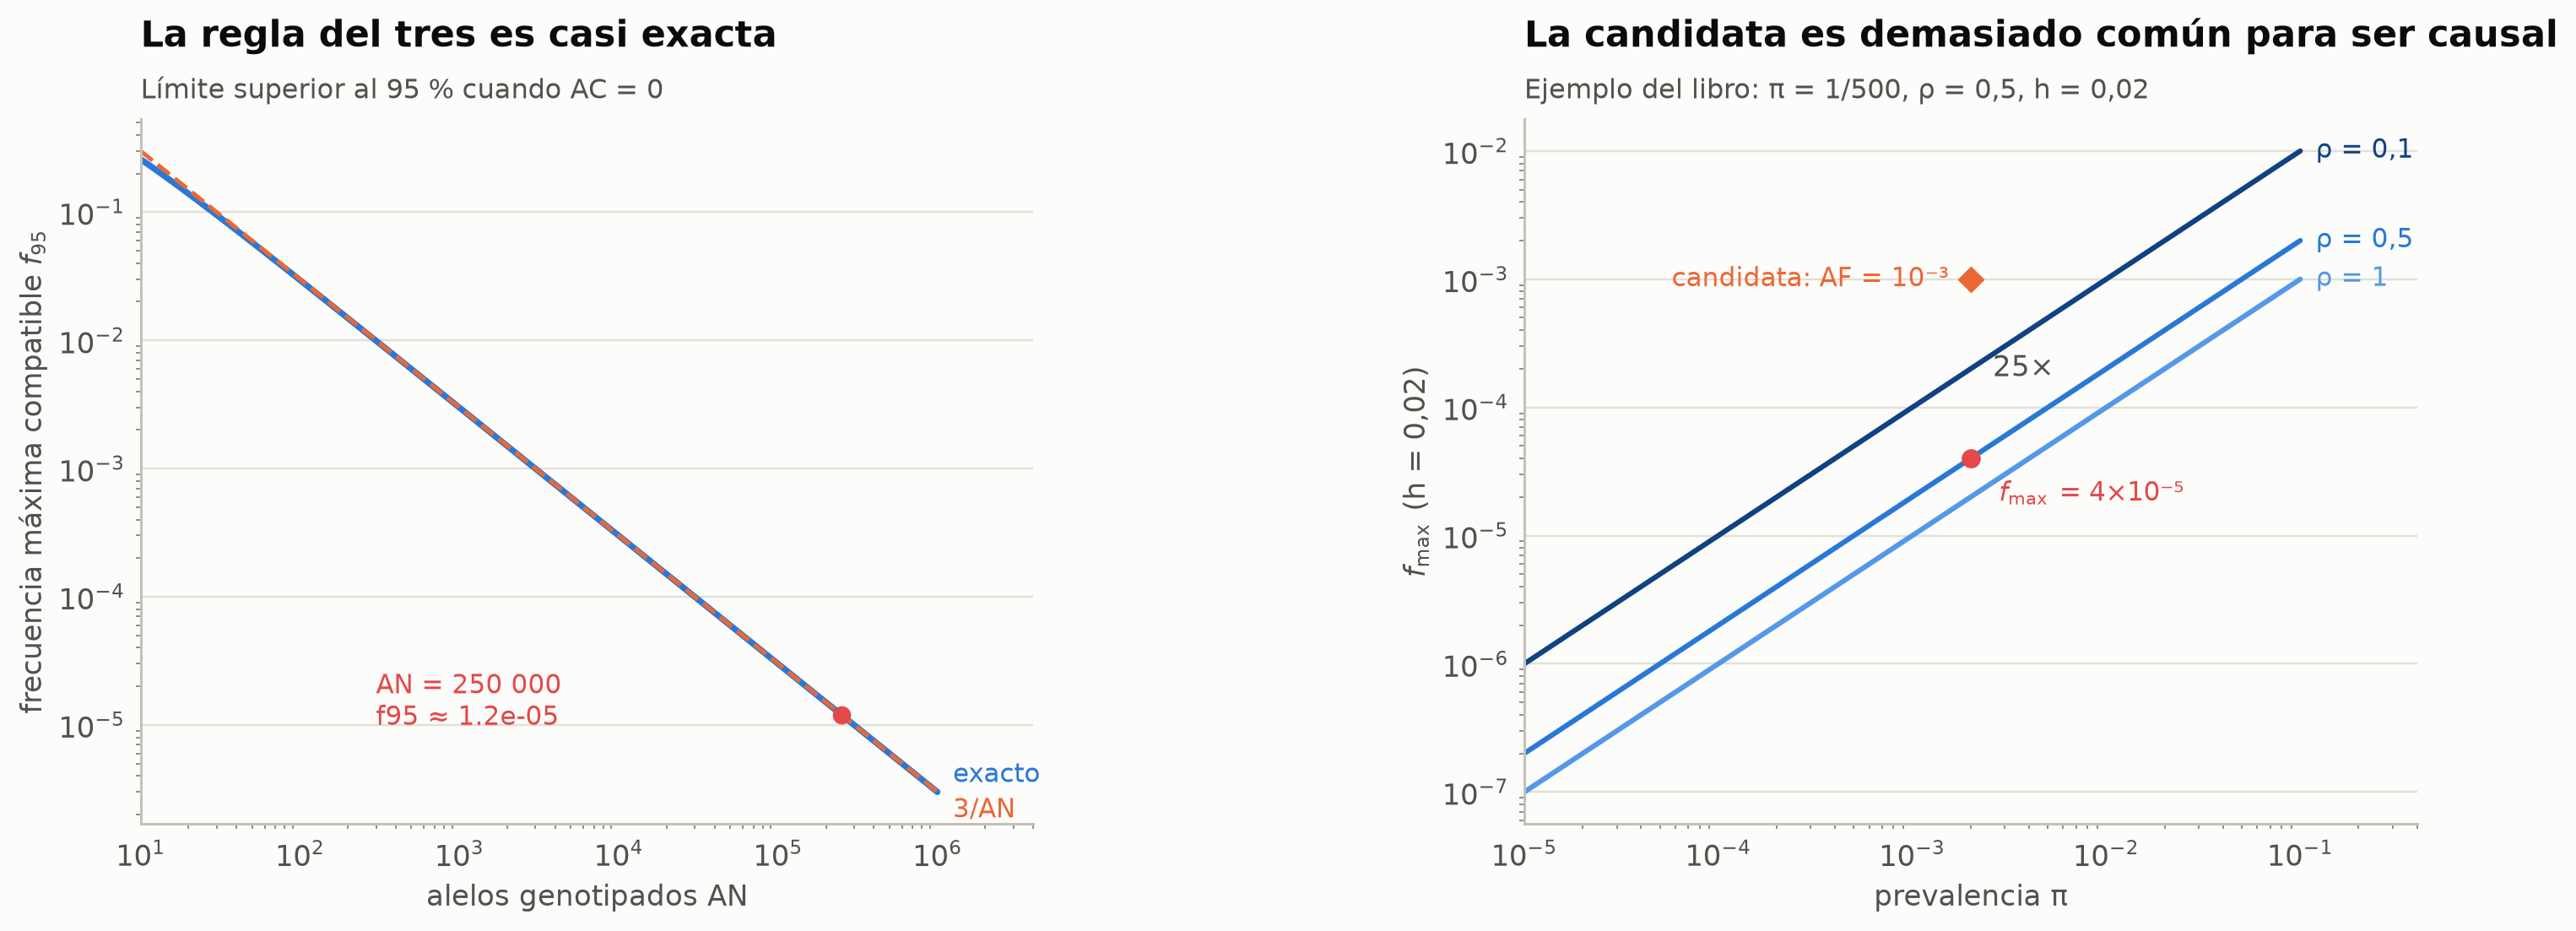

In [30]:
def f_max(prev, pen, h):
    return h * prev / (2 * pen)

fm = f_max(1 / 500, 0.5, 0.02)
print(f"f_max = {fm:.1e}  ·  candidata AF = 1e-3 es {1e-3 / fm:.0f} veces más frecuente")
print(f"con penetrancia completa (ρ = 1): f_max = {f_max(1/500, 1.0, 0.02):.1e}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.9), gridspec_kw=dict(wspace=0.3))
an = np.logspace(1, 6, 200)
a1.loglog(an, 1 - 0.05 ** (1 / an), color=ec.BLUE, lw=2.4)
a1.loglog(an, 3 / an, color=ec.ORANGE, lw=1.6, ls="--")
ec.label_end(a1, an[-1], (1 - 0.05 ** (1 / an[-1])) * 1.35, "exacto", color=ec.BLUE)
ec.label_end(a1, an[-1], 3 / an[-1] / 1.4, "3/AN", color=ec.ORANGE)
a1.scatter([AN], [f95_exact], color=ec.RED, zorder=3, s=50)
a1.annotate(f"AN = 250 000\nf95 ≈ {f95_exact:.1e}", xy=(AN, f95_exact), xytext=(3e2, 1e-5), fontsize=10,
            color=ec.RED, arrowprops=dict(arrowstyle="->", color=ec.RED))
a1.set_xlim(10, 4e6); a1.set_xlabel("alelos genotipados AN"); a1.set_ylabel("frecuencia máxima compatible $f_{95}$")
ec.title(a1, "La regla del tres es casi exacta", "Límite superior al 95 % cuando AC = 0")
prev = np.logspace(-5, -1, 200)
for pen, col in ((1.0, ec.SEQ_BLUE[5]), (0.5, ec.BLUE), (0.1, ec.SEQ_BLUE[11])):
    a2.loglog(prev, f_max(prev, pen, 0.02), color=col, lw=2)
    ec.label_end(a2, prev[-1], f_max(prev[-1], pen, 0.02), f"ρ = {pen:g}".replace(".", ","), color=col)
a2.scatter([1 / 500], [fm], color=ec.RED, s=55, zorder=3)
a2.scatter([1 / 500], [1e-3], color=ec.ORANGE, s=55, zorder=3, marker="D")
a2.annotate("", xy=(1 / 500, 1e-3), xytext=(1 / 500, fm), arrowprops=dict(arrowstyle="<->", color=ec.INK_2))
a2.text(1 / 500 * 1.3, np.sqrt(fm * 1e-3), "25×", fontsize=11, color=ec.INK_2, va="center")
a2.text(1 / 500 * 1.4, fm / 1.5, f"$f_{{\\max}}$ = 4×10⁻⁵", ha="left", va="top", fontsize=10, color=ec.RED)
a2.text(1 / 500 / 1.3, 1e-3, "candidata: AF = 10⁻³", ha="right", va="center", fontsize=10, color=ec.ORANGE)
a2.set_xlim(1e-5, 0.4); a2.set_xlabel("prevalencia π"); a2.set_ylabel("$f_{\\max}$ (h = 0,02)")
ec.title(a2, "La candidata es demasiado común para ser causal", "Ejemplo del libro: π = 1/500, ρ = 0,5, h = 0,02")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la curva exacta y $3/\mathrm{AN}$ son indistinguibles en cuanto AN supera unas
> decenas. A la derecha, $f_{\max}$ crece con la prevalencia y **decrece con la penetrancia**: si todos los portadores
> enferman, los portadores tienen que ser todavía más raros. La candidata queda muy por encima de la recta de
> $\rho = 0{,}5$. En la parte clínica, R175H o R273H (AF ~$10^{-5}$) pasarían este filtro, mientras que P72R
> (AF ≈ 0,6) queda fuera de cualquier cálculo razonable para una enfermedad rara: cumple de sobra el criterio **BA1**
> (AF > 5 %).

**Restricción por gen (LOEUF).** gnomAD aporta además una medida por gen. Con un modelo mutacional que depende del
contexto trinucleotídico y de la metilación, predice cuántas variantes de pérdida de función (pLoF) **esperaríamos**
en cada gen sin selección, y las compara con las **observadas**. El límite superior del intervalo de confianza del
cociente observado/esperado (**LOEUF**) resume cuán intolerante es el gen a perder una copia: LOEUF bajo = gen
fuertemente restringido, y una variante pLoF en él merece más atención. Es la misma lógica que usamos en la sección 6
con las sinónimas del clon del LTEE: lo observado frente a lo esperado bajo un modelo de mutación.

---

## 10. Predictores de efecto: SIFT, PolyPhen-2 y CADD

Para las variantes de sentido erróneo, la mayoría de las codificantes y las más difíciles de interpretar, existen
predictores computacionales.

### 10.1 SIFT: lo que la evolución ha tolerado

Ng y Henikoff (2003) partieron de una idea evolutiva: si una posición de la proteína ha tolerado muchos aminoácidos
distintos a lo largo de la evolución, un cambio en ella probablemente será tolerado. SIFT busca homólogos, construye un
alineamiento múltiple y estima en cada posición $i$ la probabilidad $p_{ia}$ de cada aminoácido $a$ (con
**pseudoconteos** que añaden aminoácidos plausibles no observados). La puntuación normaliza por el aminoácido más
frecuente:

$$
S_{ia} = \frac{p_{ia}}{\max_{a'} p_{ia'}},
$$

y se predice **«deletérea»** la sustitución si $S_{ia} < 0{,}05$.

| Símbolo | Significado |
|---|---|
| $p_{ia}$ | Probabilidad estimada del aminoácido $a$ en la posición $i$ del alineamiento de homólogos |
| $S_{ia}$ | Puntuación SIFT: 1 para el aminoácido más frecuente; cerca de 0 para los nunca vistos |

**Ejemplo ilustrativo (a mano).** Una columna de 20 homólogos tiene 12 R, 6 K y 2 H. Con un pseudoconteo total
$\beta = 1$ repartido por igual entre los 20 aminoácidos (0,05 para cada uno):
$p_{iR} = 12{,}05/21$, $p_{iK} = 6{,}05/21$, $p_{iW} = 0{,}05/21$. Entonces $S_{iK} = 6{,}05/12{,}05 = 0{,}50$
(tolerada) y $S_{iW} = 0{,}05/12{,}05 = 0{,}004$ (deletérea). *(SIFT real usa pseudoconteos más elaborados, basados en
matrices de sustitución; aquí simplificamos para ver la idea.)*

R    1.000
K    0.502
H    0.170
A    0.004
Y    0.004
…
N    0.0041
V    0.0041


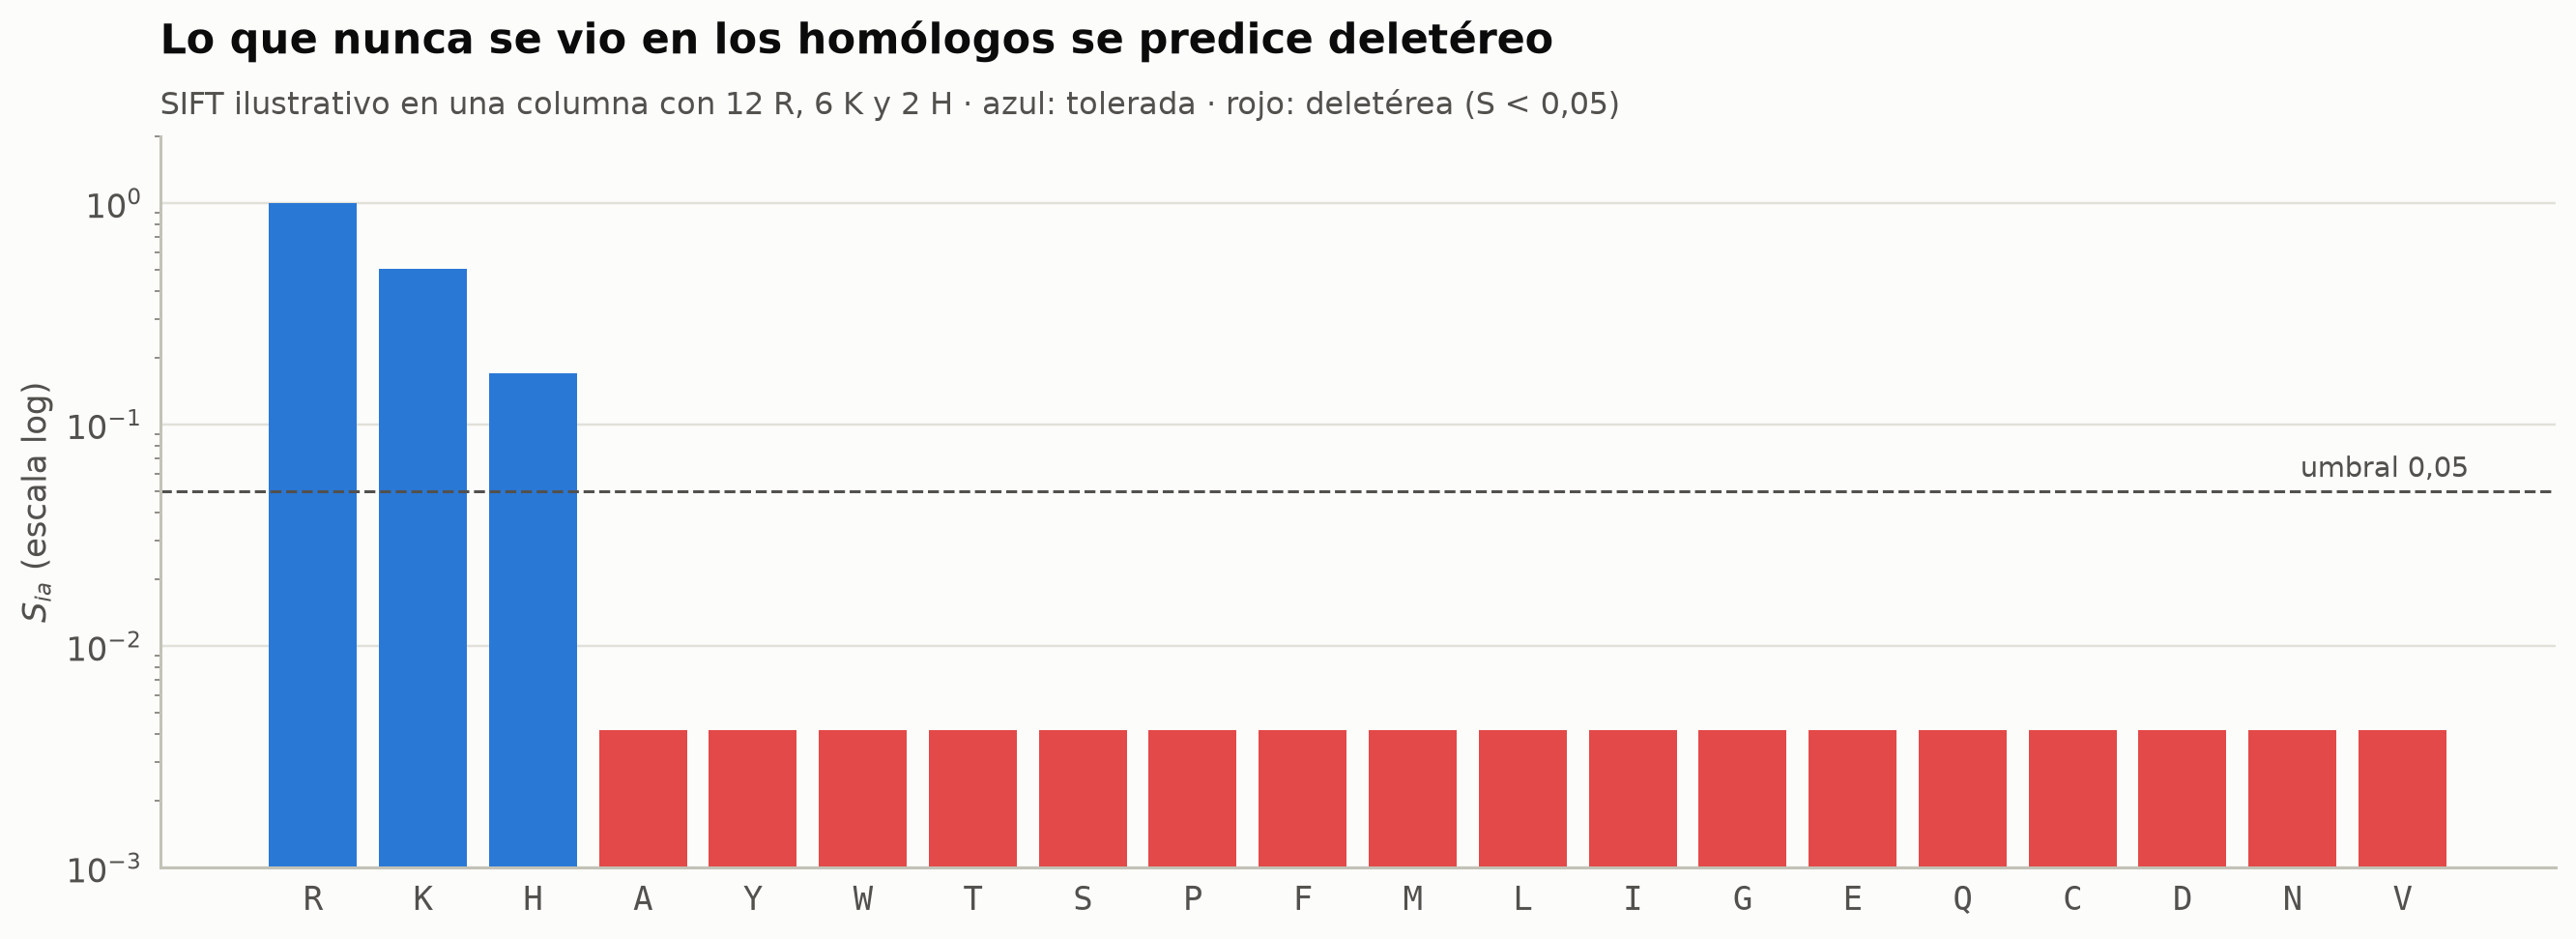

In [31]:
AA20 = "ARNDCQEGHILKMFPSTWYV"
column = "R" * 12 + "K" * 6 + "H" * 2
beta = 1.0
counts = Counter(column)
p = {a: (counts[a] + beta / 20) / (len(column) + beta) for a in AA20}
pmax = max(p.values())
S = pd.Series({a: p[a] / pmax for a in AA20}).sort_values(ascending=False)
print(S.head(5).round(3).to_string()); print("…"); print(S.tail(2).round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 4.3))
ax.bar(range(20), S.values, color=[ec.BLUE if v >= 0.05 else ec.RED for v in S.values])
ax.set_yscale("log"); ax.set_ylim(1e-3, 2)
ax.axhline(0.05, color=ec.INK_2, ls="--", lw=1); ax.text(19.6, 0.058, "umbral 0,05", ha="right", fontsize=9.5,
                                                         color=ec.INK_2)
ax.set_xticks(range(20), S.index, family="monospace"); ax.set_ylabel("$S_{ia}$ (escala log)")
ax.grid(axis="x", visible=False)
ec.title(ax, "Lo que nunca se vio en los homólogos se predice deletéreo",
         "SIFT ilustrativo en una columna con 12 R, 6 K y 2 H · azul: tolerada · rojo: deletérea (S < 0,05)")
plt.show()

> 🔎 **Qué observamos.** Sólo R, K y H (los tres aminoácidos básicos que la evolución ha aceptado en esa posición) superan
> el umbral. Cualquier otro cambio sería «deletéreo». Ahora vuelva a la tabla de *TP53*: VEP dio SIFT = 0,08 a R175H.
> SIFT sólo mira la columna del alineamiento de homólogos: basta con que en ella aparezca algo de variación para que
> la sustitución quede del lado «tolerado». No sabe nada de la estructura 3D, y R175H se conoce como una mutación
> «estructural» que desestabiliza el dominio de unión al ADN. Por eso SIFT, solo, no basta.

### 10.2 PolyPhen-2: conservación más estructura

Adzhubei et al. (2010) combinan conservación con rasgos **estructurales** (accesibilidad al solvente, cambios de volumen
e hidrofobicidad, proximidad a sitios funcionales anotados) en un **clasificador bayesiano ingenuo** entrenado con
variantes causales de enfermedad y variantes neutrales. Devuelve una probabilidad de que la variante sea dañina,
resumida en tres clases: benigna, posiblemente dañina y probablemente dañina.

### 10.3 CADD: aprender de lo que la selección eliminó

SIFT y PolyPhen sólo evalúan cambios de aminoácido. Kircher et al. (2014) propusieron un marco general para **cualquier
SNV o *indel* del genoma**, con una idea ingeniosa para obtener datos de entrenamiento sin etiquetas clínicas:

* Variantes **observadas**: fijadas en el linaje humano desde el ancestro común con el chimpancé; han pasado por el
  filtro de la selección natural.
* Variantes **simuladas**: con el mismo modelo mutacional, pero sin selección.

Un clasificador (una máquina de vectores de soporte en la versión original; regresión logística en las posteriores)
aprende a distinguirlas a partir de decenas de anotaciones. Las variantes que «parecen simuladas» son las que la
selección habría eliminado: probablemente deletéreas. La puntuación bruta se convierte en una escala Phred del
**rango**:

$$
C = -10\log_{10}\frac{r}{N},
$$

| Símbolo | Significado |
|---|---|
| $r$ | Posición de la variante en el ordenamiento de todas las SNV posibles del genoma, de más a menos deletérea |
| $N$ | Número total de SNV posibles en el genoma de referencia (unos $8{,}6\times10^{9}$) |
| $C$ | Puntuación CADD escalada (*PHRED-like*) |

de modo que $C \ge 10$ corresponde al 10 % más deletéreo de todas las sustituciones posibles, $C \ge 20$ al 1 % y
$C \ge 30$ al 0,1 %. Es la **misma escala Phred** de las calidades de base del Módulo 6: cada 10 puntos, un factor 10.
Rentzsch et al. (2019) describen las versiones posteriores (más anotaciones, GRCh38 y un servicio web).

C = 10: top 10 %  →  rango r ≈ 8.60e+08 de 8.6e+09
C = 20: top 1 %  →  rango r ≈ 8.60e+07 de 8.6e+09
C = 30: top 0.1 %  →  rango r ≈ 8.60e+06 de 8.6e+09

p.Arg175His      CADD  25.9  →  entre el 0.257 % más deletéreo (r ≈ 2.21e+07)
p.Arg248Gln      CADD  28.4  →  entre el 0.145 % más deletéreo (r ≈ 1.24e+07)
p.Arg273His      CADD  24.4  →  entre el 0.363 % más deletéreo (r ≈ 3.12e+07)
p.Arg213Ter      CADD  41.0  →  entre el 0.00794 % más deletéreo (r ≈ 6.83e+05)
p.Pro72Arg       CADD 12.91  →  entre el 5.12 % más deletéreo (r ≈ 4.40e+08)


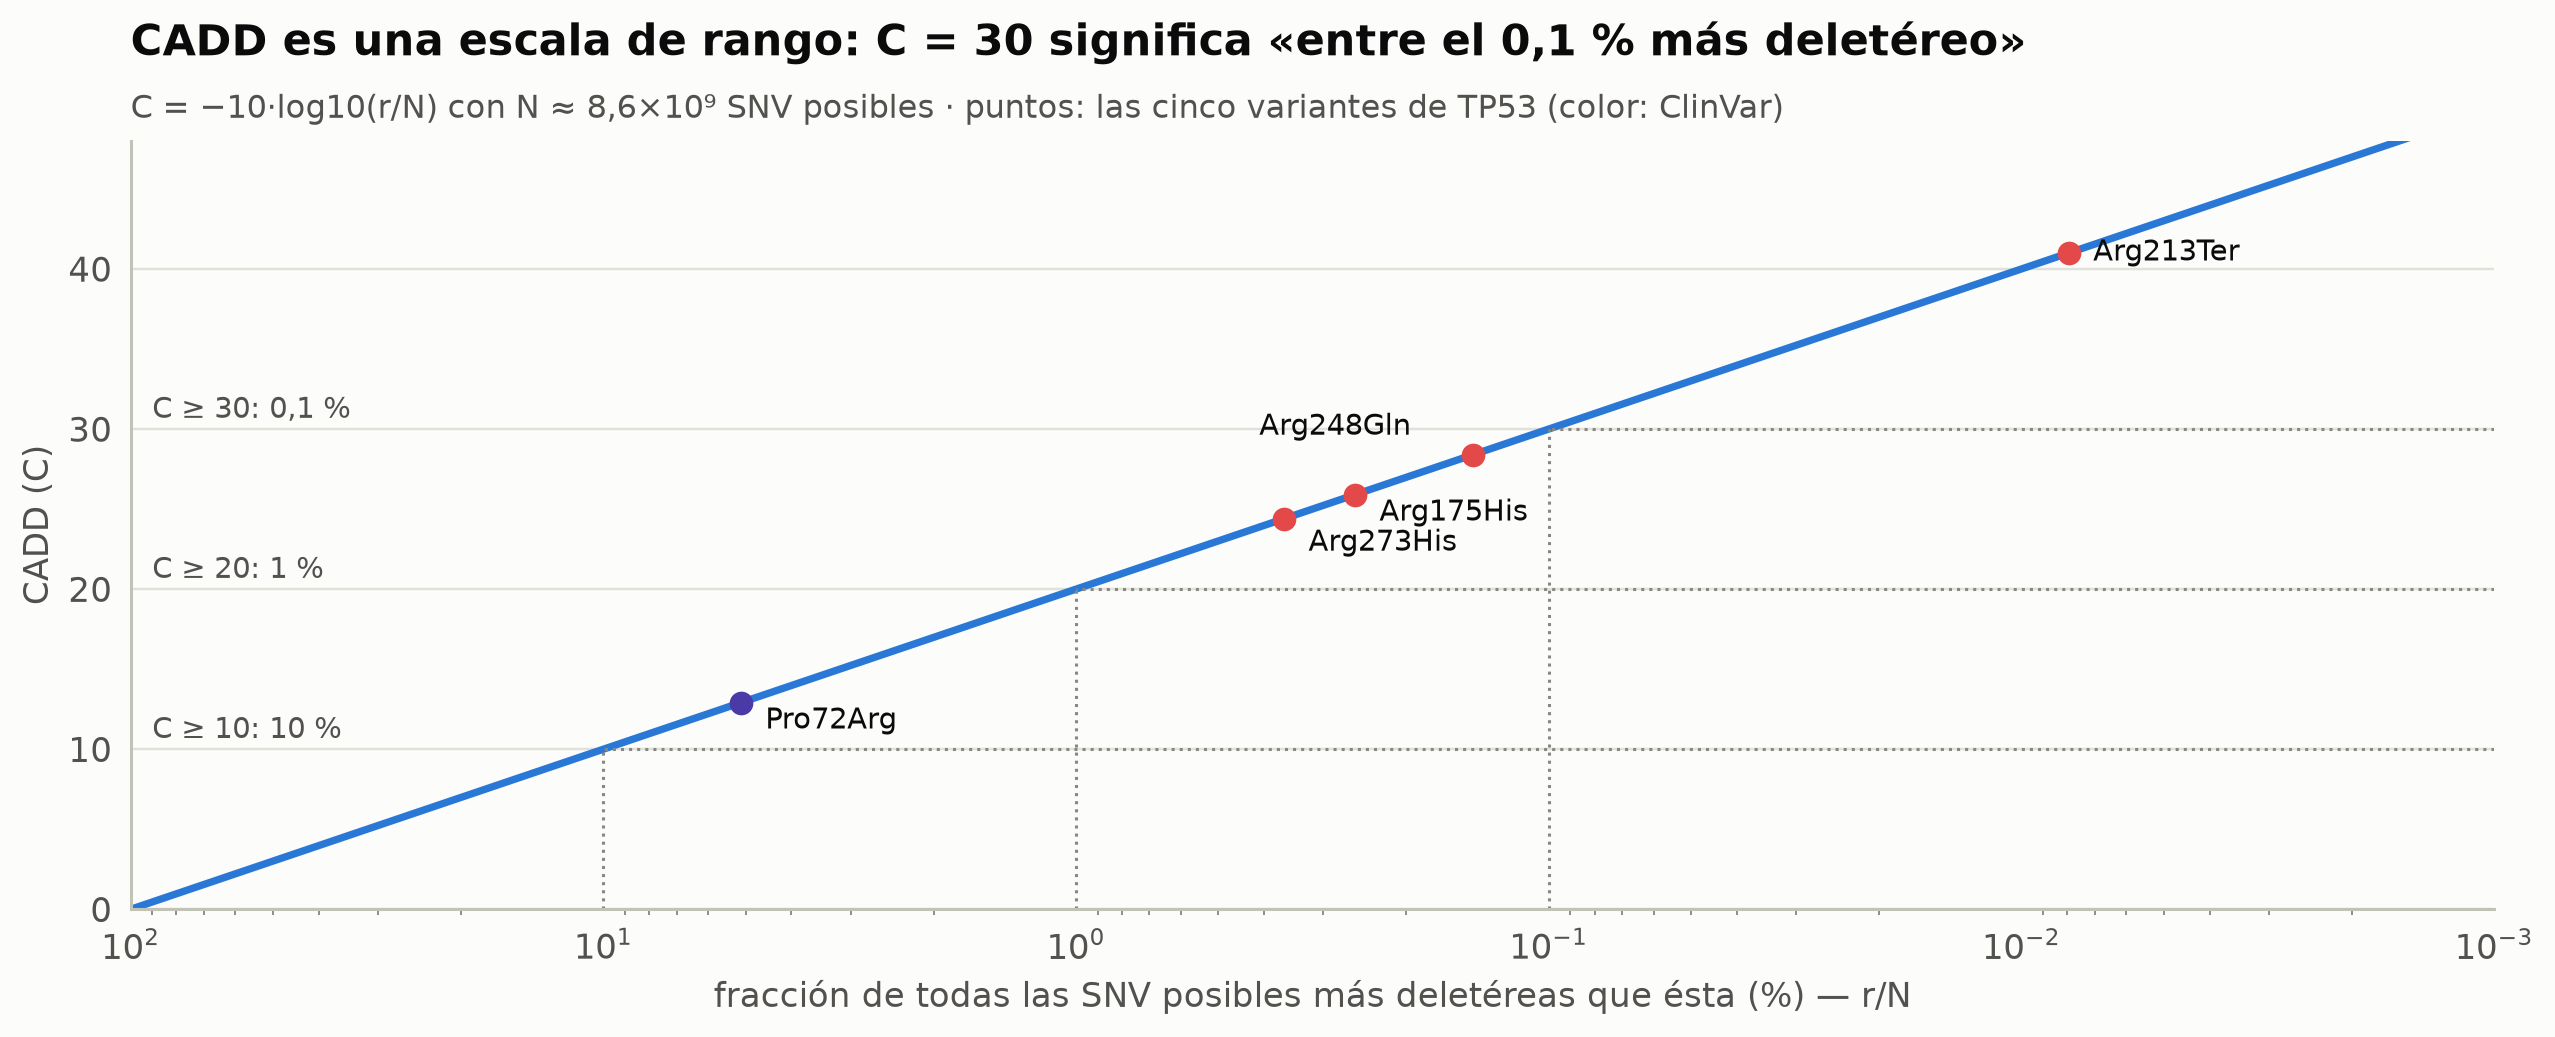

In [32]:
N_SNV = 8.6e9
for C in (10, 20, 30):
    print(f"C = {C}: top {100 * 10 ** (-C / 10):g} %  →  rango r ≈ {N_SNV * 10 ** (-C / 10):.2e} de {N_SNV:.1e}")
print()
for r in tp53.itertuples():
    frac = 10 ** (-r.cadd / 10)
    print(f"{r.protein:<16} CADD {r.cadd:>5}  →  entre el {100*frac:.3g} % más deletéreo (r ≈ {frac*N_SNV:.2e})")

fig, ax = plt.subplots(figsize=(11.5, 4.6))
frac = np.logspace(-5, 0, 300)
ax.semilogx(frac * 100, -10 * np.log10(frac), color=ec.BLUE, lw=2.4)
for C in (10, 20, 30):
    ax.plot([100 * 10 ** (-C / 10)] * 2, [0, C], color=ec.MUTED, ls=":", lw=1)
    ax.plot([1e-3, 100 * 10 ** (-C / 10)], [C, C], color=ec.MUTED, ls=":", lw=1)
    ax.text(90, C + 0.7, f"C ≥ {C}: {100 * 10 ** (-C / 10):g} %".replace(".", ","), fontsize=9.5,
            color=ec.INK_2)
offs = {"p.Arg175His": (8, -6), "p.Arg248Gln": (-70, 9), "p.Arg273His": (8, -8), "p.Arg213Ter": (8, 0),
        "p.Pro72Arg": (8, -6)}
for r in tp53.itertuples():
    x = 100 * 10 ** (-r.cadd / 10)
    ax.scatter([x], [r.cadd], color=clin_color(r.clinvar), s=60, zorder=3, edgecolor="white")
    ax.annotate(r.protein.replace("p.", ""), (x, r.cadd), xytext=offs[r.protein], textcoords="offset points",
                fontsize=9.5, va="center")
ax.invert_xaxis(); ax.set_xlim(100, 1e-3); ax.set_ylim(0, 48)
ax.set_xlabel("fracción de todas las SNV posibles más deletéreas que ésta (%) — r/N"); ax.set_ylabel("CADD (C)")
ec.title(ax, "CADD es una escala de rango: C = 30 significa «entre el 0,1 % más deletéreo»",
         "C = −10·log10(r/N) con N ≈ 8,6×10⁹ SNV posibles · puntos: las cinco variantes de TP53 (color: ClinVar)")
plt.show()

> 🔎 **Qué observamos.** Los tres puntos calientes de *TP53* tienen CADD de 24–28 (entre el 0,14 % y el 0,4 % más
> deletéreo de todo el genoma), la variante nula 41, y el polimorfismo común P72R 12,9. CADD ordena bien estos cinco
> casos, pero recuerde el aviso del libro:

> ⚠️ **Los predictores no son diagnósticos.** SIFT, PolyPhen-2 y CADD están correlacionados entre sí (usan
> información parecida, sobre todo conservación) y su exactitud en variantes individuales es limitada. Una puntuación
> «dañina» es evidencia de apoyo, nunca prueba de patogenicidad; y dos predictores que coinciden no son dos evidencias
> independientes. Las guías ACMG, precisamente por eso, les conceden el peso más bajo (PP3/BP4).

✅ **Compruebe su comprensión.** Una variante tiene CADD 15. ¿Qué fracción de todas las SNV posibles es más
deletérea que ella según CADD? (Respuesta: $10^{-1{,}5} \approx 3{,}2\,\%$.)

---

## 11. ClinVar y las guías ACMG/AMP

**ClinVar** es el archivo público de las interpretaciones clínicas de variantes: laboratorios de diagnóstico, grupos de
expertos e investigadores depositan sus clasificaciones con la evidencia que las respalda. La base de datos muestra las
**discrepancias** entre remitentes y un **nivel de revisión** (las «estrellas»), que va desde una sola clasificación sin
criterios hasta la revisión por un panel de expertos (Landrum et al., 2018). Encontrar una variante en ClinVar como
«patogénica» con varias estrellas es una evidencia fuerte; encontrarla con una sola estrella y clasificaciones
contradictorias (como el alelo Arg de P72R en la sección 8), no tanto.

Para clasificar de manera **reproducible**, el American College of Medical Genetics and Genomics (ACMG) y la
Association for Molecular Pathology (AMP) publicaron unas guías que hoy son el estándar internacional
(Richards et al., 2015). Cinco categorías: **patogénica, probablemente patogénica, de significado incierto (VUS),
probablemente benigna y benigna**. Cada tipo de evidencia recibe un **código** y una **fuerza**:

| Lado | Fuerza | Códigos | Ejemplo |
|---|---|---|---|
| Patogénico | Muy fuerte (MF) | PVS1 | Variante nula (*frameshift*, *stop gained*) en un gen donde la pérdida de función causa la enfermedad |
| Patogénico | Fuerte (F) | PS1–PS4 | PS2: aparición *de novo* confirmada |
| Patogénico | Moderada (M) | PM1–PM6 | PM2: ausente o extremadamente rara en controles poblacionales |
| Patogénico | De apoyo (A) | PP1–PP5 | PP3: múltiples predictores computacionales coinciden en un efecto dañino |
| Benigno | Independiente | BA1 | Frecuencia alélica > 5 % |
| Benigno | Fuerte | BS1–BS4 | BS1: frecuencia mayor de lo esperado para la enfermedad (el cálculo de $f_{\max}$) |
| Benigno | De apoyo | BP1–BP7 | BP4: los predictores coinciden en que no hay efecto |

Las **reglas de combinación** (tabla del libro):

| Clasificación | Combinaciones suficientes |
|---|---|
| Patogénica | 1 MF + (≥1 F, o ≥2 M, o 1 M + 1 A, o ≥2 A); ≥2 F; 1 F + (≥3 M, o 2 M + ≥2 A, o 1 M + ≥4 A) |
| Probablemente patogénica | 1 MF + 1 M; 1 F + 1–2 M; 1 F + ≥2 A; ≥3 M; 2 M + ≥2 A; 1 M + ≥4 A |
| Benigna | BA1 (independiente); ≥2 criterios benignos fuertes |
| Probablemente benigna | 1 benigno fuerte + 1 de apoyo; ≥2 benignos de apoyo |

Si se cumplen a la vez criterios patogénicos y benignos contradictorios, o no se alcanza ninguna regla, la variante es
**VUS**. Estas reglas son un pequeño sistema lógico: podemos programarlas.

In [33]:
def acmg_classify(codes):
    """Reglas de combinación ACMG/AMP (Richards et al., 2015) a partir de una lista de códigos."""
    n = lambda pref: sum(c.startswith(pref) for c in codes)
    pvs, ps, pm, pp = n("PVS"), n("PS"), n("PM"), n("PP")
    ba, bs, bp = n("BA"), n("BS"), n("BP")
    path = ((pvs >= 1 and (ps >= 1 or pm >= 2 or (pm == 1 and pp == 1) or pp >= 2)) or ps >= 2 or
            (ps == 1 and (pm >= 3 or (pm == 2 and pp >= 2) or (pm == 1 and pp >= 4))))
    lpath = ((pvs == 1 and pm == 1) or (ps == 1 and 1 <= pm <= 2) or (ps == 1 and pp >= 2) or pm >= 3 or
             (pm == 2 and pp >= 2) or (pm == 1 and pp >= 4))
    benign = ba >= 1 or bs >= 2
    lbenign = (bs == 1 and bp >= 1) or bp >= 2
    # Criterios contradictorios → VUS: una regla patogénica con cualquier criterio BA/BS (o una regla benigna de
    # apoyo), o una regla benigna junto a cualquier criterio patogénico
    if ((path or lpath) and (ba + bs >= 1 or lbenign)) or ((benign or lbenign) and pvs + ps + pm + pp >= 1):
        return "VUS (evidencia en conflicto)"
    if path: return "Patogénica"
    if lpath: return "Probablemente patogénica"
    if benign: return "Benigna"
    if lbenign: return "Probablemente benigna"
    return "VUS"

cases = [("Libro A: stop_gained de novo, ausente en gnomAD", ["PVS1", "PS2", "PM2"]),
         ("Libro B: missense heredada, CADD 24, ausente en gnomAD", ["PM2", "PP3"]),
         ("TP53 P72R: AF ≈ 0,6 en gnomAD", ["BA1"]),
         ("de novo + dominio crítico + ausente", ["PS2", "PM1", "PM2"]),
         ("nula de novo, pero con AF > 5 % en controles", ["PVS1", "PS2", "BA1"])]
for name, codes in cases:
    print(f"{name:<55} {'+'.join(codes):<16} → {acmg_classify(codes)}")

Libro A: stop_gained de novo, ausente en gnomAD         PVS1+PS2+PM2     → Patogénica
Libro B: missense heredada, CADD 24, ausente en gnomAD  PM2+PP3          → VUS
TP53 P72R: AF ≈ 0,6 en gnomAD                           BA1              → Benigna
de novo + dominio crítico + ausente                     PS2+PM1+PM2      → Probablemente patogénica
nula de novo, pero con AF > 5 % en controles            PVS1+PS2+BA1     → VUS (evidencia en conflicto)


**Ejemplo del libro («Clasificar una variante»).** En un niño con un trastorno del neurodesarrollo, la secuenciación del
trío revela una variante `stop_gained` en heterocigosis, ausente en ambos padres (paternidad confirmada) y ausente en
gnomAD. El gen tiene LOEUF muy bajo y la haploinsuficiencia es un mecanismo establecido de la enfermedad. Criterios:
**PVS1** (variante nula en un gen donde la pérdida de función es el mecanismo, muy fuerte), **PS2** (*de novo*
confirmada, fuerte) y **PM2** (ausente en controles, moderada). La regla «1 MF + ≥1 F» basta: **patogénica**.

Si, en cambio, fuese una variante de sentido erróneo heredada de un progenitor sano, con CADD 24 y ausente de gnomAD,
sólo tendríamos **PM2** y **PP3**: ninguna regla se cumple y la variante quedaría como **VUS**, a la espera de más
evidencia (segregación familiar, estudios funcionales, nuevos casos).

Observe el último caso de la tabla: una variante nula *de novo* (PVS1 + PS2, que por sí solas la harían patogénica)
que sin embargo supera el 5 % en controles (BA1) cumple a la vez una regla patogénica y una benigna. No se promedia:
el conflicto la deja en VUS y obliga a revisar los supuestos (¿es realmente la pérdida de función el mecanismo?, ¿la
penetrancia es menor de lo que creíamos?, ¿hay un error de genotipado?).

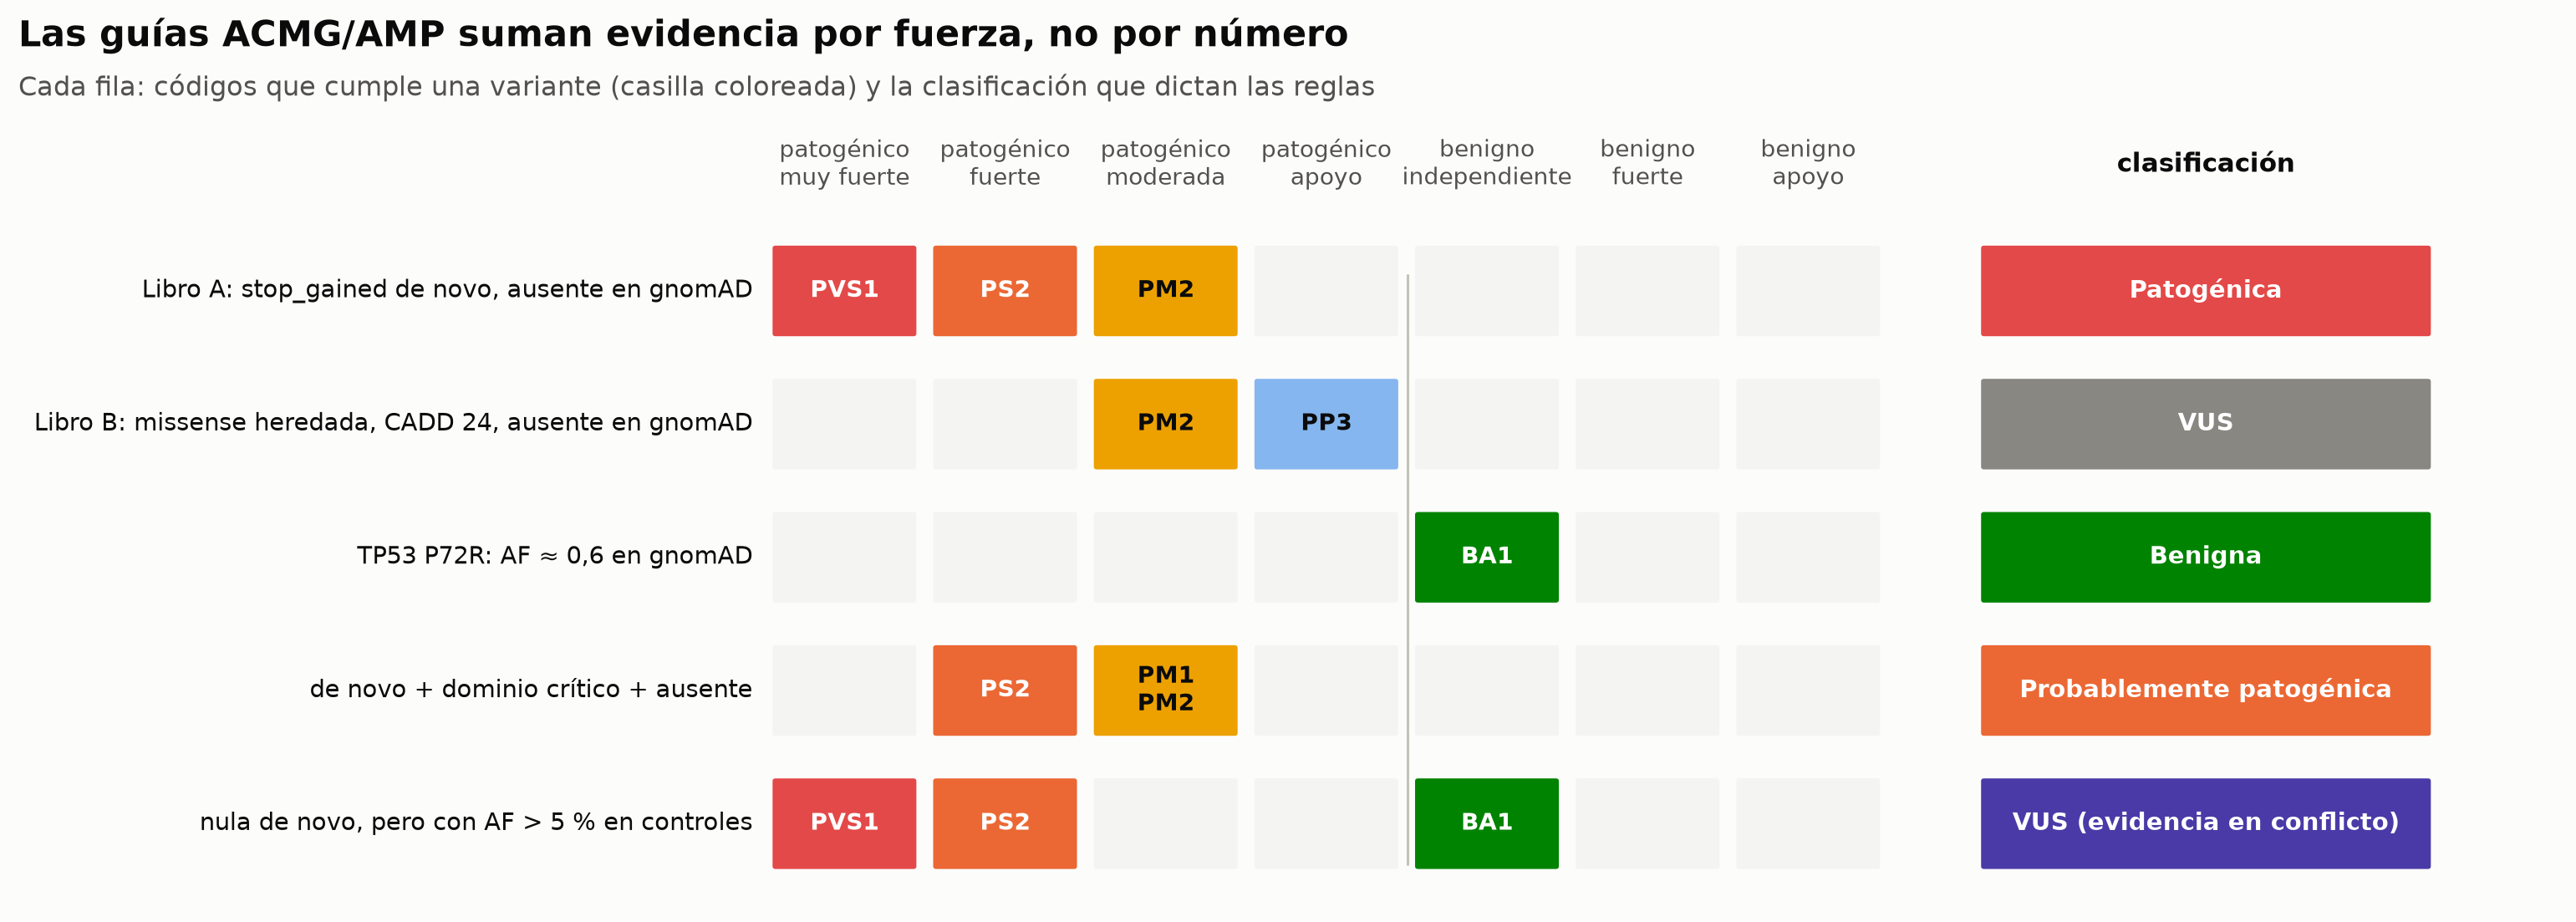

In [34]:
STRENGTH = [("PVS", "muy fuerte", ec.RED), ("PS", "fuerte", ec.ORANGE), ("PM", "moderada", ec.YELLOW),
            ("PP", "apoyo", ec.SEQ_BLUE[3]), ("BA", "independiente", ec.GREEN), ("BS", "fuerte", ec.AQUA),
            ("BP", "apoyo", ec.SEQ_BLUE[5])]
CLASS_COLOR = {"Patogénica": ec.RED, "Probablemente patogénica": ec.ORANGE, "VUS": ec.MUTED,
               "VUS (evidencia en conflicto)": ec.VIOLET, "Probablemente benigna": ec.AQUA, "Benigna": ec.GREEN}
fig, ax = plt.subplots(figsize=(14, 4.9))
ax.set_xlim(-5.4, 11.2); ax.set_ylim(len(cases) - 0.4, -1.3); ax.axis("off"); ax.grid(False)
for j, (pref, lab, col) in enumerate(STRENGTH):
    side = "patogénico" if pref.startswith("P") else "benigno"
    ax.text(j * 1.05, -0.95, f"{side}\n{lab}", ha="center", va="center", fontsize=9, color=ec.INK_2)
ax.text(8.9, -0.95, "clasificación", ha="center", va="center", fontsize=10, fontweight="bold", color=ec.INK)
for i, (name, codes) in enumerate(cases):
    ax.text(-0.6, i, name, ha="right", va="center", fontsize=9.5)
    for j, (pref, lab, col) in enumerate(STRENGTH):
        mine = [c for c in codes if c.startswith(pref) and not (pref == "PS" and c.startswith("PVS"))]
        ax.add_patch(FancyBboxPatch((j * 1.05 - 0.45, i - 0.32), 0.9, 0.64, boxstyle="round,pad=0.02",
                                    fc=col if mine else "#f0efec", ec="none", alpha=1 if mine else 0.6))
        if mine:
            ax.text(j * 1.05, i, "\n".join(mine), ha="center", va="center", fontsize=9, fontweight="bold",
                    color="white" if col in (ec.RED, ec.ORANGE, ec.GREEN) else ec.INK)
    cl = acmg_classify(codes)
    ax.add_patch(FancyBboxPatch((7.45, i - 0.32), 2.9, 0.64, boxstyle="round,pad=0.02", fc=CLASS_COLOR[cl], ec="none"))
    ax.text(8.9, i, cl, ha="center", va="center", fontsize=9.5, color="white", fontweight="bold")
ax.axvline(3.68, ymin=0.05, ymax=0.8, color=ec.BASELINE, lw=1)
ec.title(ax, "Las guías ACMG/AMP suman evidencia por fuerza, no por número",
         "Cada fila: códigos que cumple una variante (casilla coloreada) y la clasificación que dictan las reglas")
plt.show()

> 🔎 **Qué observamos.** Tres códigos bien elegidos (fila A) bastan para una clasificación patogénica; dos códigos
> débiles (fila B) no bastan para nada. La evidencia **no se suma como votos**: un solo criterio independiente (BA1)
> decide la fila de P72R, y la mezcla de criterios opuestos no se promedia, sino que produce VUS.

⚠️ **Importante.** Clasificar una variante real exige información del caso (fenotipo, segregación familiar, estudios
funcionales) y, para muchos genes (incluido *TP53*), especificaciones de las reglas elaboradas por paneles de expertos.
Este código es una herramienta didáctica, no un sistema de diagnóstico.

✅ **Compruebe su comprensión.** Una variante cumple PS3 (estudio funcional bien establecido), PM2 y PP1 (cosegrega
con la enfermedad en la familia). ¿Qué regla se cumple? Compruébelo con `acmg_classify`.

---

## 12. El embudo de priorización

En la práctica, todo lo anterior se encadena en un **embudo** que reduce millones de variantes a unas pocas
candidatas. Los números de las primeras etapas proceden del Proyecto 1000 Genomas: un genoma humano típico difiere de
la referencia en 4,1–5,0 millones de sitios, contiene entre 149 y 182 sitios con variantes que truncan proteínas y entre
10 000 y 12 000 sitios con variantes que alteran la secuencia peptídica (Auton et al., 2015). Las etapas siguientes son
órdenes de magnitud ilustrativos, que dependen del diseño (individuo o trío, exoma o genoma) y de la población.

**Cada estrechamiento es una hipótesis explícita** («la variante causal es rara», «es codificante», «sigue un modelo
dominante») y debe revisarse si el análisis no encuentra candidatas. Una variante causal en un gen aún no asociado a
enfermedad, una variante no codificante o una variante estructural atravesarán intactas este embudo sin ser vistas.

Primero aplicamos el embudo a nuestros datos reales: las 40 llamadas del clon del LTEE.

In [35]:
coding_terms = {"missense_variant", "synonymous_variant", "frameshift_variant", "inframe_insertion",
                "inframe_deletion", "stop_gained", "stop_lost", "start_lost", "coding_sequence_variant"}
ann["lane"] = 0
ann.loc[ann.FILTER == "PASS", "lane"] = 1
ann.loc[(ann.lane == 1) & ann.consequence.isin(coding_terms), "lane"] = 2
ann.loc[(ann.lane == 2) & ann.impact.isin(["HIGH", "MODERATE"]), "lane"] = 3
ann.loc[(ann.lane == 3) & ann.gene.isin(TENAILLON_T1), "lane"] = 4
STAGES = ["registros crudos (bcftools)", "PASS (filtros de calidad)", "en una región codificante",
          "proteína alterada (CDS canónica)", "gen recurrente en el LTEE"]
clone_counts = [(ann.lane >= k).sum() for k in range(5)]
for s, c in zip(STAGES, clone_counts):
    print(f"{s:<36} {c:>3}")

registros crudos (bcftools)           40
PASS (filtros de calidad)             25
en una región codificante             20
proteína alterada (CDS canónica)      16
gen recurrente en el LTEE              6


![El embudo de priorización aplicado a las 40 llamadas reales del clon del LTEE: en cada etapa, las variantes que no cumplen la hipótesis se quedan atrás (gris) y las demás bajan.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-09-variantes/9.3_embudo.gif)

*El embudo de priorización aplicado a las 40 llamadas reales del clon del LTEE: en cada etapa, las variantes que no cumplen la hipótesis se quedan atrás (gris) y las demás bajan.*

In [36]:
fig = plt.figure(figsize=(13, 5.6), layout="none")
ax = fig.add_axes([0.25, 0.1, 0.72, 0.72])
ax.set_xlim(-0.05, L / 1e6 + 0.05); ax.set_ylim(-4.6, 0.6); ax.set_yticks([]); ax.grid(False)
ax.set_xlabel("posición en REL606 (Mb)")
for sp in ("left", "top", "right"):
    ax.spines[sp].set_visible(False)
fig.text(0.01, 0.97, "Cada filtro es una hipótesis: de 40 llamadas a 6 candidatas", fontsize=15, fontweight="bold",
         va="top")
fig.text(0.01, 0.915, "Embudo de priorización sobre las variantes reales del clon SRR2584863 · color: impacto · "
         "gris: descartada en esa etapa", fontsize=10.5, color=ec.INK_2, va="top")
for k, s in enumerate(STAGES):
    ax.axhspan(-k - 0.4, -k + 0.4, color=ec.SEQ_BLUE[k * 2], alpha=0.18, lw=0)
lane_txt = [fig.text(0.235, 0.82 - 0.72 * (k + 0.6) / 5.2, "", ha="right", va="center", fontsize=10.5)
            for k in range(5)]
xs = ann.pos.values / 1e6
ys = np.zeros(len(ann))
jitter = np.random.default_rng(1).uniform(-0.18, 0.18, len(ann))
cols = np.array([IMPACT_COLOR[i] for i in ann.impact])
sc = ax.scatter(xs, ys + jitter, s=46, c=cols, edgecolor="white", lw=0.6, zorder=3)
lanes = ann.lane.values
NSTEP, NPRE, NPOST = 9, 4, 6
NF = NPRE + 4 * NSTEP + NPOST

def update(fr):
    if fr < NPRE:
        s, t = 0, 1.0
    elif fr < NPRE + 4 * NSTEP:
        s, t = (fr - NPRE) // NSTEP + 1, ((fr - NPRE) % NSTEP + 1) / NSTEP
    else:
        s, t = 4, 1.0
    ease = t * t * (3 - 2 * t)                                   # movimiento suave
    y = np.where(lanes >= s, -(s - 1 + ease) if s > 0 else 0.0, -lanes.astype(float))
    y = np.where(lanes >= s, y, -np.minimum(lanes, s).astype(float))
    c = cols.copy()
    gone = (lanes < s - 1) | ((lanes == s - 1) & (t > 0.3))
    c[gone] = ec.BASELINE
    sc.set_offsets(np.c_[xs, y + jitter]); sc.set_color(c); sc.set_edgecolor("white")
    for k in range(5):
        shown = k < s or (k == s and t >= 1.0) or k == 0
        lane_txt[k].set_text(f"{STAGES[k]}  ·  {clone_counts[k]}" if shown else STAGES[k])
        lane_txt[k].set_color(ec.INK if shown else ec.MUTED)
        lane_txt[k].set_fontweight("bold" if k == s else "normal")
    return []

update(0)
with plt.rc_context({"savefig.bbox": None}):
    anim_html = ec.animate(fig, update, frames=NF, interval=170, name="9.3_embudo")
anim_html

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** El primer filtro (calidad) elimina el racimo Ldr y los demás registros dudosos; el
> segundo deja atrás las variantes intergénicas y cercanas a genes; el tercero, las de IS1 que no sabemos anotar con seguridad; el último, los genes que no
> están entre los objetivos recurrentes del LTEE. Fíjese en que **el último filtro es una hipótesis fuerte**: «las
> mutaciones importantes están en genes ya conocidos». Una mutación beneficiosa nueva en un gen nunca visto (o la
> duplicación en marco de la proteína hipotética) se quedaría atrás aunque fuera la más interesante del clon.

La figura interactiva compara el embudo clínico del libro (izquierda, en escala logarítmica porque abarca seis órdenes
de magnitud) con el del clon (derecha). Pase el ratón por cada etapa para ver la hipótesis que introduce y lo que
puede perder.

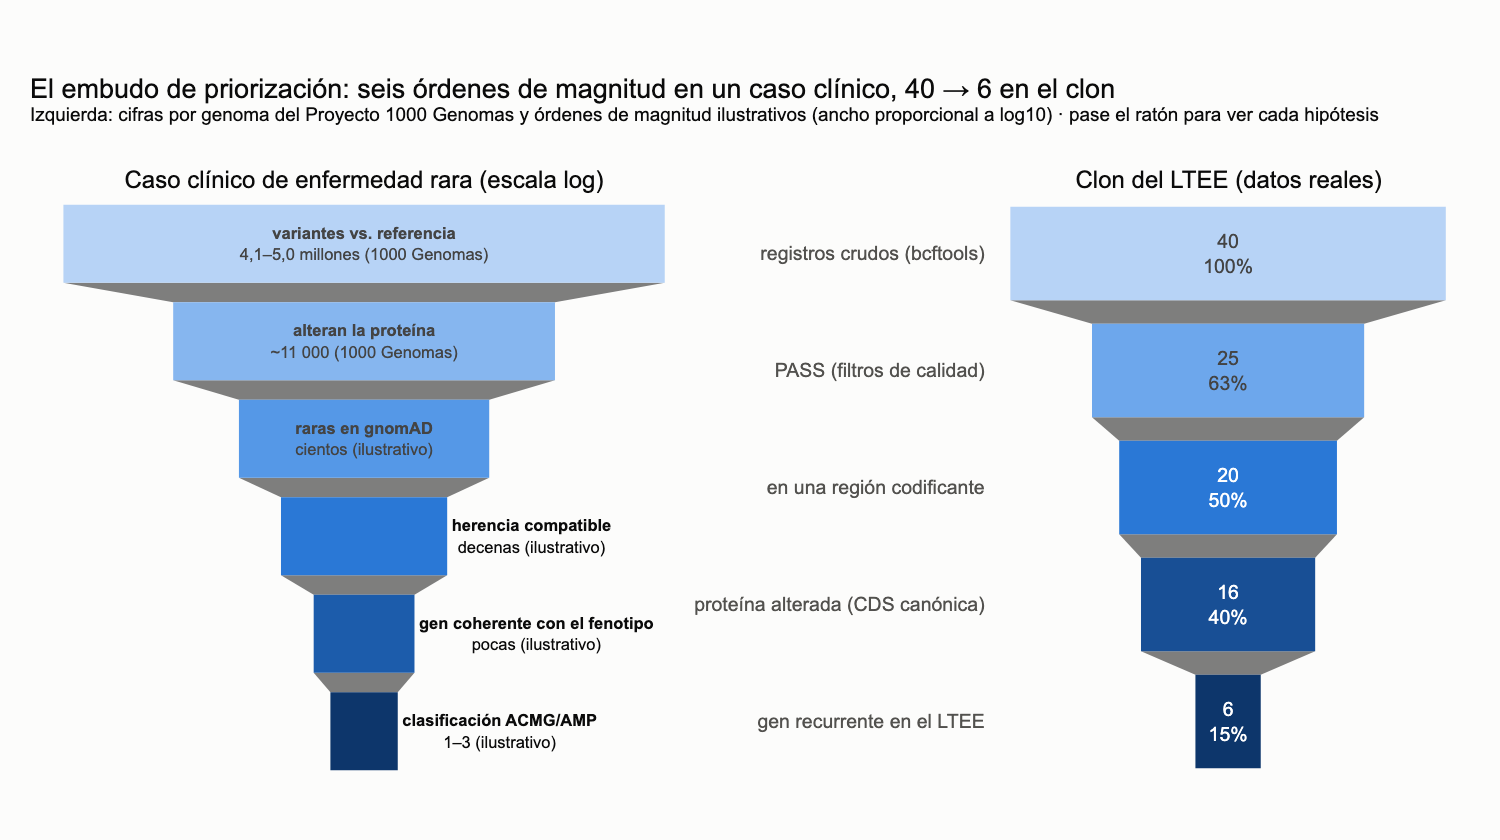

In [37]:
human = [("variantes vs. referencia", 4.5e6, "4,1–5,0 millones (1000 Genomas)",
          "punto de partida: todas las diferencias con GRCh38"),
         ("alteran la proteína", 11_000, "~11 000 (1000 Genomas)",
          "hipótesis: la causa es codificante · pierde: variantes reguladoras y de splicing profundo"),
         ("raras en gnomAD", 300, "cientos (ilustrativo)",
          "p. ej. AF < 0,1 % · hipótesis: enfermedad rara → alelo raro (f_max) · pierde: alelos fundadores, baja penetrancia"),
         ("herencia compatible", 30, "decenas (ilustrativo)",
          "hipótesis: de novo / recesiva según el trío · pierde: mosaicismo, penetrancia incompleta"),
         ("gen coherente con el fenotipo", 5, "pocas (ilustrativo)",
          "hipótesis: el gen ya está asociado · pierde: genes aún no descritos"),
         ("clasificación ACMG/AMP", 2, "1–3 (ilustrativo)", "reglas de combinación de evidencia")]
clone_hyp = ["todas las llamadas de bcftools call -mv",
             "hipótesis: los errores tienen QUAL/DP bajos, sesgo de hebra o caen en repeticiones · pierde: variantes "
             "reales en regiones repetidas",
             "hipótesis: la adaptación cambia proteínas · pierde: mutaciones reguladoras (p. ej. upstream de hupB)",
             "hipótesis: sabemos traducir la CDS · pierde: las 4 variantes en IS1 (CDS no canónicas)",
             "hipótesis: los genes recurrentes del LTEE son los importantes · pierde: dianas nuevas"]
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.2, column_widths=[0.58, 0.42],
                    subplot_titles=("Caso clínico de enfermedad rara (escala log)", "Clon del LTEE (datos reales)"))
fig.add_trace(go.Funnel(
    y=[h[0] for h in human], x=[np.log10(h[1]) + 0.5 for h in human],
    text=[f"<b>{h[0]}</b><br>{h[2]}" for h in human], textfont=dict(size=11),
    textinfo="text", customdata=[h[3] for h in human],
    marker=dict(color=[ec.SEQ_BLUE[i] for i in (1, 3, 5, 7, 9, 12)]),
    hovertemplate="%{text}<br>%{customdata}<extra></extra>", connector=dict(line=dict(width=0))),
    row=1, col=1)
fig.add_trace(go.Funnel(
    y=STAGES, x=clone_counts, textinfo="value+percent initial", customdata=clone_hyp,
    marker=dict(color=[ec.SEQ_BLUE[i] for i in (1, 4, 7, 10, 12)]),
    hovertemplate="<b>%{y}</b><br>%{x} variantes (%{percentInitial:.0%} de las crudas)<br>%{customdata}"
                  "<extra></extra>", connector=dict(line=dict(width=0))), row=1, col=2)
fig.update_yaxes(showticklabels=False, row=1, col=1)
fig.update_layout(height=560, margin=dict(t=130, l=20, r=20, b=40), showlegend=False,
                  title="El embudo de priorización: seis órdenes de magnitud en un caso clínico, 40 → 6 en el clon"
                        "<br><sup>Izquierda: cifras por genoma del Proyecto 1000 Genomas y órdenes de magnitud "
                        "ilustrativos (ancho proporcional a log10) · pase el ratón para ver cada hipótesis</sup>")
fig.show()

---

## ✍️ Ejercicios

**Ejercicio 1 (anotar a mano).** La variante del clon `4201958 A>C` cae en *iclR*. Busque en `feat` las coordenadas y la
hebra de *iclR*, calcule $o$, el número de codón y la posición en el codón con las fórmulas de la sección 4, escriba el
codón de referencia y el mutado (¡recuerde el complemento si la hebra es −!) y compruebe su resultado con `annotate`.

**Ejercicio 2 (libro, ejercicio 8).** Repita el recuento de las 576 sustituciones ponderando cada una por una tasa de
mutación en la que las **transiciones** (A↔G, C↔T) son el doble de probables que cada **transversión**. ¿Cómo cambia la
fracción esperada de sinónimas en codones con sentido? Hágalo también ponderando por el uso de codones de REL606 y
recalcule $P(X=0)$ para el clon. Relacione el resultado con el cálculo de $d_N/d_S$.

**Ejercicio 3 (gnomAD).** Una enfermedad dominante tiene prevalencia 1/10 000, penetrancia 0,8 y $h = 0{,}1$.
(a) Calcule $f_{\max}$. (b) Una candidata está ausente en un subconjunto de gnomAD con AN = 30 000. Calcule $f_{95}$.
¿Basta esa ausencia para decir que la variante es compatible con $f_{\max}$? (c) ¿Qué AN haría falta para que la
ausencia fuese concluyente?

**Ejercicio 4 (ACMG/AMP).** Clasifique a mano y luego con `acmg_classify`: (a) PS2 + PM1 + PM2; (b) PVS1 + PM2;
(c) BS1 + BP4; (d) PVS1 + PS3 + BS1; (e) PM1 + PM2 + PP3 + PP4. ¿En cuál cambiaría la conclusión si PP3 se basara
en dos predictores que coinciden (SIFT y CADD) y usted los contara como dos códigos distintos? ¿Por qué no debe
hacerse?

**Ejercicio 5 (la ventana upstream).** Vuelva a anotar las 25 variantes PASS con la ventana por defecto de VEP y
SnpEff, $w = 5000$ pb. ¿Cuántas variantes cambian de consecuencia? ¿Qué le pasaría a un análisis que contase
«variantes reguladoras» con esa ventana en un genoma bacteriano?

In [38]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
icl = feat[feat.name == "iclR"].iloc[0]
pos = 4201958
o = pos - icl.start if icl.strand == "+" else icl.end - pos
k = o // 3
s = gene_seq(icl)
c0 = s[3 * k:3 * k + 3]
b_alt = "C" if icl.strand == "+" else revcomp("C")
c1 = c0[:o % 3] + b_alt + c0[o % 3 + 1:]
print(f"iclR {icl.start:,}–{icl.end:,} hebra {icl.strand}")
print(f"o = {'fin − POS' if icl.strand == '-' else 'POS − inicio'} = {o} → codón {k + 1}, posición {o % 3 + 1}")
print(f"codón {c0} ({aa3(CODE[c0])}) → {c1} ({aa3(CODE[c1])})  [en la hebra −, A>C genómico es T>G en el gen]"
      if icl.strand == "-" else f"codón {c0} → {c1}")
print("annotate:", {k_: v for k_, v in annotate(pos, "A", "C")[0].items() if k_ in ("term", "codon_change", "hgvs_c", "hgvs_p")})

iclR 4,201,735–4,202,559 hebra -
o = fin − POS = 601 → codón 201, posición 2
codón CTC (Leu) → CGC (Arg)  [en la hebra −, A>C genómico es T>G en el gen]
annotate: {'codon_change': 'CTC>CGC', 'hgvs_c': 'c.602T>G', 'hgvs_p': 'p.(Leu201Arg)', 'term': 'missense_variant'}


In [39]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
TRANSITION = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
def weighted_fractions(weights_codon):
    acc = Counter()
    for c in cls_codon:
        for p_ in range(3):
            for b in "ACGT":
                if b == c[p_]:
                    continue
                wgt = weights_codon[c] * (2.0 if (c[p_], b) in TRANSITION else 1.0)
                acc[classify(c, p_, b)] += wgt
    total = sum(acc.values())
    return {k_: acc[k_] / total for k_ in ("sin", "mis", "non")}
uni_w = weighted_fractions({c: 1 for c in cls_codon})
rel_w = weighted_fractions(usage)
print(f"sinónimas, código uniforme:   sin ponderar {uniform['sin']:.3f} · ti = 2×tv {uni_w['sin']:.3f}")
print(f"sinónimas, uso de REL606:     sin ponderar {expected['sin']:.3f} · ti = 2×tv {rel_w['sin']:.3f}")
print(f"P(X = 0 | n = {n}) con ti = 2×tv y REL606: {(1 - rel_w['sin']) ** n:.4f}")
print("Las transiciones en 3.ª posición son sinónimas con más frecuencia que las transversiones (p. ej. CTT↔CTC),")
print("así que ponderarlas sube p_S: el 'sitio sinónimo' efectivo depende del modelo mutacional, como en d_N/d_S.")

sinónimas, código uniforme:   sin ponderar 0.244 · ti = 2×tv 0.268
sinónimas, uso de REL606:     sin ponderar 0.236 · ti = 2×tv 0.263
P(X = 0 | n = 13) con ti = 2×tv y REL606: 0.0189
Las transiciones en 3.ª posición son sinónimas con más frecuencia que las transversiones (p. ej. CTT↔CTC),
así que ponderarlas sube p_S: el 'sitio sinónimo' efectivo depende del modelo mutacional, como en d_N/d_S.


In [40]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
fm3 = f_max(1 / 10_000, 0.8, 0.1)
f95_3 = 1 - 0.05 ** (1 / 30_000)
print(f"(a) f_max = 0,1 × 1e-4 / (2 × 0,8) = {fm3:.2e}")
print(f"(b) f95 con AN = 30 000 = {f95_3:.2e}: la ausencia sólo garantiza f < {f95_3:.1e}, que es "
      f"{f95_3 / fm3:.0f} veces mayor que f_max → no es concluyente")
print(f"(c) hace falta 3/AN ≤ f_max → AN ≥ {3 / fm3:,.0f} alelos (~{3 / fm3 / 2:,.0f} personas)")

(a) f_max = 0,1 × 1e-4 / (2 × 0,8) = 6.25e-06
(b) f95 con AN = 30 000 = 9.99e-05: la ausencia sólo garantiza f < 1.0e-04, que es 16 veces mayor que f_max → no es concluyente
(c) hace falta 3/AN ≤ f_max → AN ≥ 480,000 alelos (~240,000 personas)


In [41]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
for codes in (["PS2", "PM1", "PM2"], ["PVS1", "PM2"], ["BS1", "BP4"], ["PVS1", "PS3", "BS1"],
              ["PM1", "PM2", "PP3", "PP4"], ["PM1", "PM2", "PP3", "PP3b", "PP4"]):
    print(f"{' + '.join(codes):<28} → {acmg_classify(codes)}")
print("\n(d) PVS1 + PS3 cumplen una regla patogénica («1 MF + ≥1 F»), pero BS1 es un criterio benigno fuerte que la")
print("    contradice. No se promedia ni gana el lado más numeroso: con criterios contradictorios la variante es VUS")
print("    (Richards et al., 2015) hasta resolver el conflicto (¿la frecuencia en controles es compatible con la")
print("    penetrancia? ¿el estudio funcional es válido?).")
print("(e) con PP3 contado dos veces pasa de 2 M + 2 A (probablemente patogénica) a 2 M + 3 A: la regla no cambia aquí,")
print("pero en otros casos (p. ej. 1 M + 3 A → 1 M + 4 A) inflaría la clasificación. SIFT y CADD usan información")
print("correlacionada (conservación): no son evidencias independientes, y PP3 se cuenta una sola vez.")

PS2 + PM1 + PM2              → Probablemente patogénica
PVS1 + PM2                   → Probablemente patogénica
BS1 + BP4                    → Probablemente benigna
PVS1 + PS3 + BS1             → VUS (evidencia en conflicto)
PM1 + PM2 + PP3 + PP4        → Probablemente patogénica
PM1 + PM2 + PP3 + PP3b + PP4 → Probablemente patogénica

(d) PVS1 + PS3 cumplen una regla patogénica («1 MF + ≥1 F»), pero BS1 es un criterio benigno fuerte que la
    contradice. No se promedia ni gana el lado más numeroso: con criterios contradictorios la variante es VUS
    (Richards et al., 2015) hasta resolver el conflicto (¿la frecuencia en controles es compatible con la
    penetrancia? ¿el estudio funcional es válido?).
(e) con PP3 contado dos veces pasa de 2 M + 2 A (probablemente patogénica) a 2 M + 3 A: la regla no cambia aquí,
pero en otros casos (p. ej. 1 M + 3 A → 1 M + 4 A) inflaría la clasificación. SIFT y CADD usan información
correlacionada (conservación): no son evidencias independientes, y 

In [42]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
wide = [annotate(r.pos, r.ref, r.alt, w=5000)[0]["term"] for r in passed.itertuples()]
cmp_w = pd.DataFrame({"pos": passed.pos, "w=200": passed.consequence, "w=5000": wide})
diff = cmp_w[cmp_w["w=200"] != cmp_w["w=5000"]]
print(diff.to_string(index=False) if len(diff) else "ninguna cambia")
print(f"\n{len(diff)} variantes cambian. Con 5 kb, en un genoma con un gen cada ~1 kb, prácticamente toda variante")
print("intergénica queda 'upstream' de algún gen: el término pierde su valor como indicio de región promotora.")

    pos                   w=200                w=5000
 281923      intergenic_variant upstream_gene_variant
2999330 downstream_gene_variant upstream_gene_variant

2 variantes cambian. Con 5 kb, en un genoma con un gen cada ~1 kb, prácticamente toda variante
intergénica queda 'upstream' de algún gen: el término pierde su valor como indicio de región promotora.


## 📌 Resumen

* **Anotar** es responder dónde cae una variante, qué le hace al gen y a la proteína, cuán frecuente es y qué se sabe
  de su efecto. Los términos de la **Sequence Ontology** (`missense_variant`, `frameshift_variant`…) y las categorías
  HIGH / MODERATE / LOW / MODIFIER dan un idioma común a VEP, SnpEff y ANNOVAR. La nomenclatura **HGVS** describe la
  variante (`NM_000546.6:c.743G>A`, `p.(Arg248Gln)`).
* Dentro de la CDS, la consecuencia la decide el **código genético**: de las 549 SNV posibles sobre codones con
  sentido, 134 (24,4 %) son sinónimas, 392 (71,4 %) de sentido erróneo y 23 (4,2 %) crean un codón de parada; en la
  2.ª posición ninguna es sinónima. Un *indel* de $\Delta \not\equiv 0 \pmod 3$ desplaza el marco.
* Un anotador propio sobre REL606 aplicado al clon del LTEE: de 40 llamadas crudas, 25 pasan filtros explícitos (el
  racimo Ldr y una inserción con sesgo de hebra quedan marcados); 13 son de sentido erróneo, 2 *frameshift*, 1
  inserción en marco, 4 caen en transposasas IS1 no canónicas y 5 fuera de genes. Seis de los 16 genes con la
  proteína alterada (*topA*, *pykF*, *malT*, *hslU*, *iclR*, *nadR*) están entre los genes con más evolución paralela
  del LTEE (Tenaillon et al., 2016).
* Bajo mutación aleatoria esperaríamos ~3 sinónimas entre 13 SNV codificantes; observar 0 ($P \approx 0{,}03$) es
  compatible con selección positiva de cambios de proteína. Es la lógica de $d_N/d_S$ y de las métricas de restricción.
* **gnomAD**: la regla del tres, $f_{95} \approx 3/\mathrm{AN}$, acota lo no observado; $f_{\max} = h\pi/(2\rho)$ acota
  lo que puede ser causal (ejemplo del libro: $4\times10^{-5}$, 25 veces menos que la candidata).
* **SIFT** ($S_{ia} = p_{ia}/\max_{a'} p_{ia'}$, deletérea si < 0,05), **PolyPhen-2** y **CADD**
  ($C = -10\log_{10}(r/N)$) son evidencia de apoyo, correlacionada y falible: R175H de *TP53* es «tolerada» para SIFT.
* **ClinVar** reúne interpretaciones con su nivel de revisión; las guías **ACMG/AMP** combinan códigos por fuerza
  (PVS1 + PS2 + PM2 → patogénica; PM2 + PP3 → VUS; BA1 → benigna).
* El **embudo de priorización** reduce millones de variantes a unas pocas candidatas; cada filtro es una hipótesis que
  hay que declarar y revisar.

## 📚 Para profundizar

* Eilbeck, K., Lewis, S. E., Mungall, C. J., Yandell, M., Stein, L., Durbin, R. et al. (2005). The Sequence
  Ontology: a tool for the unification of genome annotations. *Genome Biology* 6(5): R44.
* den Dunnen, J. T. et al. (2016). HGVS Recommendations for the Description of Sequence Variants: 2016 Update.
  *Human Mutation* 37(6): 564–569.
* McLaren, W. et al. (2016). The Ensembl Variant Effect Predictor. *Genome Biology* 17(1): 122.
* Cingolani, P. et al. (2012). A program for annotating and predicting the effects of single nucleotide polymorphisms,
  SnpEff. *Fly* 6(2): 80–92.
* Wang, K., Li, M. & Hakonarson, H. (2010). ANNOVAR: functional annotation of genetic variants from high-throughput
  sequencing data. *Nucleic Acids Research* 38(16): e164.
* Danecek, P. et al. (2021). Twelve years of SAMtools and BCFtools. *GigaScience* 10(2): giab008.
* Tan, A., Abecasis, G. R. & Kang, H. M. (2015). Unified representation of genetic variants. *Bioinformatics* 31(13):
  2202–2204.
* Karczewski, K. J. et al. (2020). The mutational constraint spectrum quantified from variation in 141,456 humans.
  *Nature* 581(7809): 434–443.
* Ng, P. C. & Henikoff, S. (2003). SIFT: predicting amino acid changes that affect protein function. *Nucleic Acids
  Research* 31(13): 3812–3814.
* Adzhubei, I. A. et al. (2010). A method and server for predicting damaging missense mutations. *Nature Methods*
  7(4): 248–249.
* Kircher, M. et al. (2014). A general framework for estimating the relative pathogenicity of human genetic variants.
  *Nature Genetics* 46(3): 310–315.
* Rentzsch, P., Witten, D., Cooper, G. M., Shendure, J. & Kircher, M. (2019). CADD: predicting the deleteriousness of
  variants throughout the human genome. *Nucleic Acids Research* 47(D1): D886–D894.
* Landrum, M. J. et al. (2018). ClinVar: improving access to variant interpretations and supporting evidence.
  *Nucleic Acids Research* 46(D1): D1062–D1067.
* Richards, S. et al. (2015). Standards and guidelines for the interpretation of sequence variants: a joint consensus
  recommendation of the American College of Medical Genetics and Genomics and the Association for Molecular
  Pathology. *Genetics in Medicine* 17(5): 405–424.
* Auton, A. et al. (2015). A global reference for human genetic variation. *Nature* 526(7571): 68–74.
* Tenaillon, O., Barrick, J. E., Ribeck, N., et al. (2016). Tempo and mode of genome evolution in a 50,000-generation
  experiment. *Nature* 536(7615): 165–170.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)